## **AI for Epigraphy: Ανάλυση Εικόνων και Κειμένων Αρχαίων Ελληνικών Επιγραφών**

**Εφαρμοσμένη Επιστήμη Δεδομένων — Ομαδική Εργασία 2026**

Σε αυτή την εργασία θα σχεδιάσετε ένα πλήρες υπολογιστικό pipeline για την ανάλυση αρχαίων ελληνικών επιγραφών. Το σύνολο δεδομένων αποτελεί μέρος του ICDAR 2026 Competition in Text Recognition on Greek Squeezes και είναι διαθέσιμο [εδώ](https://www.science.smith.edu/~nhowe/contest/trogs26.html#dataset).

Τα δεδομένα περιλαμβάνουν μεταγραφές κειμένων (λατινικοί χαρακτήρες σε μορφή scriptio continua) και εικόνες επιγραφών (squeezes).

Πρόκειται για εργασία 2 ατόμων. Καλείστε να απαντήσετε και στα δύο μέρη (Α και Β). Η συμμετοχή στο ICDAR Competition είναι προαιρετική (+10% στον βαθμό της εργασίας). Αν βρεθείτε στους top-20 του διαγωνισμού: +10% στον τελικό βαθμό του μαθήματος.

Παραδοτέα:
1. Αρχεία κώδικα (ipynb/py) με ονομασία <ΑΜ1>_<ΑΜ2>
2. Αναφορά 5-6 σελίδων σε PDF
3. prompts_<ΑΜ1>_<ΑΜ2>.md (υποχρεωτικό)
4. Προαιρετικό: μονοσέλιδο ICDAR competition document

---

| | |
|---|---|
| **Μέλος 1** | Ernest Beta, ΑΜ: 3220239 |
| **Μέλος 2** | Χρήστος Γουναρίδης, ΑΜ: 3220033 |

**Συνεισφορά μελών:**
- Μέλος 1: Researched the datasets for the vocabulary built, researched the models that were going to be used for A part and B3 part. Implemented A2 dynamic programming algorithm.
Co-designed the plots for dataset analysis (A3).
Tried various methods for A4 solution including ready made datasets (ended up picking common ancient greek names and manually using those in code).
Implemented and tested (A6) including munual ChatGPT calls for model comparison.
Reviewed code top to bottom to determine all cells are inline with the requirements and one another.

- Μέλος 2: Implemented the A1 data loading and character mapping pipeline.
Executed the vocabulary statistical analysis for A3.
Developed the text clustering and topic modeling pipeline for A5.
Handled the image ingestion and preprocessing for B1, utilizing cv2 to clean, resize, and denoise the squeeze images.
Implemented the visual feature extraction for B2, extracting embeddings from VIT and applying PCA, UMAP, and KMeans to cluster the images based on visual similarity.
Analyzed and interpreted the results of the clustering experiments across both text and images for the identified topics and visual groupings (A5, B2).
Collaborated on overall debugging, evaluating model outputs, and compiling the final notebook.



In [ ]:
# Colab dependency setup
# These packages are not always preinstalled in a fresh Colab runtime.
%pip -q install datasets textdistance transformers

In [ ]:
# Standard library imports
import gc
import importlib.util
import json
import math
import os
import pickle
import re
import shutil
import subprocess
import sys
import unicodedata
import urllib.request
import warnings
import zipfile
from collections import Counter, defaultdict
from functools import lru_cache
from itertools import product
from os import listdir
from os.path import isfile, join
from pathlib import Path
from datasets import load_dataset

# Third-party ecosystem imports
import cv2
import jax
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
from scipy.sparse import hstack, issparse
from textdistance import levenshtein
from tqdm.auto import tqdm

from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation, NMF, PCA, TruncatedSVD
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

import torch
from torch.utils.data import DataLoader, Dataset
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from transformers.optimization import Adafactor

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q -o "/content/drive/MyDrive/GREEK_SQUEEZES/Annotations.zip" -d "/content/Annotations"
!unzip -q -o "/content/drive/MyDrive/GREEK_SQUEEZES/Images1.zip" -d "/content/Images1"
!unzip -q -o "/content/drive/MyDrive/GREEK_SQUEEZES/Images2.zip" -d "/content/Images2"
!unzip -q -o "/content/drive/MyDrive/GREEK_SQUEEZES/Images3.zip" -d "/content/Images3"
!unzip -q -o "/content/drive/MyDrive/GREEK_SQUEEZES/Images4.zip" -d "/content/Images4"

print("Folders Unzipped")

Folders Unzipped


In [ ]:
import os

annotations_dir = '/content/Annotations/Annotations/'
images_dirs = ['/content/Images1/', '/content/Images2/', '/content/Images3/', '/content/Images4/']

ann_files = {f.replace('_letters.txt', '') for f in os.listdir(annotations_dir) if f.endswith('.txt')}

img_ids = set()
for d in images_dirs:
    if os.path.exists(d):
        for f in os.listdir(d):
            if f.endswith('.png'):
                img_ids.add(f.replace('.png', ''))

valid_pairs = ann_files.intersection(img_ids)

print(f"Συνολικά αρχεία κειμένου (Annotations): {len(ann_files)}")
print(f"Συνολικές εικόνες: {len(img_ids)}")
print("-" * 30)
print(f"Σύνολο ζευγαριών: {len(valid_pairs)}")

if valid_pairs:
    print("\nΔείγμα αντιστοιχίσεων:")
    for item in list(valid_pairs)[:5]:
        print(f"ID: {item}")

Συνολικά αρχεία κειμένου (Annotations): 448
Συνολικές εικόνες: 448
------------------------------
Σύνολο ζευγαριών: 448

Δείγμα αντιστοιχίσεων:
ID: IG_II2_335_Copy1_Rotation1_300dpi
ID: IG_II2_1967_Rotation1_300dpi
ID: IG_II2_1711_Merged_Rotation2_300dpi
ID: IG_II2_414b_Copy2_Rotation1_300dpi
ID: IG_II2_2089a_Rotation1_300dpi


## Μέρος Α — Ανάλυση Κειμένων (50 μονάδες)

**Α1.** Μετατρέψτε τους λατινικούς χαρακτήρες των μεταγραφών σε κεφαλαία ελληνικά γράμματα (δεν απαιτούνται τόνοι/πνεύματα), ώστε οι μεταγραφές να γίνουν αναγνώσιμο αρχαίο ελληνικό κείμενο. Μπορείτε να χρησιμοποιήσετε το βοηθητικό αρχείο PDF "Proxies" στον φάκελο Annotations. Περιγράψτε το σύστημα μεταγραφής σας και παρέχετε παραδείγματα πριν/μετά τη μετατροπή. *(6 μονάδες)*


### A1 Solution:
In A1, the Latin proxy transcriptions were converted into uppercase Greek using a fixed character mapping, such as A → Α, G → Γ, Q → Θ, C → Χ, U → Ψ, and W → Ω. Special symbols such as *, :, ), and & were preserved because they may mark damage or annotation information. For each annotation file, only the # Transcript section was extracted and converted, while the original files remained unchanged. In total, 448 matched annotation files were converted

In [ ]:
proxy_to_greek = {
    "A": "Α",
    "B": "Β",
    "G": "Γ",
    "D": "Δ",
    "E": "Ε",
    "Z": "Ζ",
    "H": "Η",
    "Q": "Θ",
    "I": "Ι",
    "K": "Κ",
    "L": "Λ",
    "M": "Μ",
    "N": "Ν",
    "X": "Ξ",
    "O": "Ο",
    "P": "Π",
    "R": "Ρ",
    "S": "Σ",
    "T": "Τ",
    "Y": "Υ",
    "F": "Φ",
    "C": "Χ",
    "U": "Ψ",
    "W": "Ω",
    ":": ":",
    ")": ")",
    "&": "&",
    "*": "*",
}


def read_annotation_text(path):
    for encoding in ("utf-8", "utf-8-sig", "latin-1"):
        try:
            return path.read_text(encoding=encoding), encoding
        except UnicodeDecodeError:
            print('Error ocurred during reading please check encoding')
            continue

def extract_proxy_transcript(file_text):
    """
    Starts after '# Transcript' and stops at the next section beginning with '#',
    or at EOF if no later section exists.
    Preserves the original transcript line structure.
    """
    lines = file_text.splitlines()

    start_idx = None

    for i, line in enumerate(lines):
        if line.strip() == "# Transcript":
            start_idx = i + 1
            break

    if start_idx is None:
        warnings.warn(
            "Could not find '# Transcript' section. Returning full file text.",
            UserWarning,
            stacklevel=2,
        )
        return file_text

    end_idx = len(lines)

    for i in range(start_idx, len(lines)):
        if lines[i].lstrip().startswith("#"):
            end_idx = i
            break

    transcript_lines = lines[start_idx:end_idx]

    while transcript_lines and transcript_lines[-1].strip() == "":
        transcript_lines.pop()

    return "\n".join(transcript_lines)


def convert_proxy_to_greek(text):
    """
    Convert Latin proxy characters to uppercase Greek.

    Assumes every non-whitespace character exists in proxy_to_greek.
    """
    return "".join(
        char if char.isspace() else proxy_to_greek[char]
        for char in text
    )


annotations_raw = []

for inscription_id in sorted(valid_pairs):
    path = Path(annotations_dir) / f"{inscription_id}_letters.txt"

    if not path.exists():
        print(f"Warning: annotation file not found for ID {inscription_id}: {path}")
        continue

    file_text, encoding = read_annotation_text(path)
    proxy_text = extract_proxy_transcript(file_text)

    annotations_raw.append(
        {
            "filename": path.name,
            "inscription_id": inscription_id,
            "proxy_text": proxy_text,
            "encoding": encoding,
        }
    )


annotations_df = pd.DataFrame(annotations_raw)

annotations_df["greek_text"] = annotations_df["proxy_text"].map(convert_proxy_to_greek)

annotations_df = annotations_df[
    ["filename", "inscription_id", "proxy_text", "greek_text", "encoding"]
]

latin_transcripts = dict(
    zip(annotations_df["inscription_id"], annotations_df["proxy_text"])
)

greek_transcripts = dict(
    zip(annotations_df["inscription_id"], annotations_df["greek_text"])
)

print(f"Loaded and converted {len(annotations_df)} matched annotation files.")
print("Original annotation files were not modified.")


def short_excerpt(text: str, length: int = 80):
    """Make a compact display excerpt without changing the stored text."""
    return text[:length].replace("\n", "\\n")



print("\n" + "=" * 70)
print("ΠΑΡΑΔΕΙΓΜΑΤΑ ΜΕΤΑΓΡΑΦΗΣ")
print("=" * 70)

example_ids = []
for prefix in ("IG_", "IAS_", "Agora"):
    hit = next((i for i in sorted(greek_transcripts) if i.startswith(prefix)), None)
    if hit:
        example_ids.append(hit)

if not example_ids:
    example_ids = list(sorted(greek_transcripts))[:3]

for inscription_id in example_ids[:3]:
    print(f"\n--- {inscription_id} ---")
    print(f"ΠΡΙΝ  (proxy): {short_excerpt(latin_transcripts[inscription_id])}")
    print(f"ΜΕΤΑ  (Greek): {short_excerpt(greek_transcripts[inscription_id])}")

Loaded and converted 448 matched annotation files.
Original annotation files were not modified.

ΠΑΡΑΔΕΙΓΜΑΤΑ ΜΕΤΑΓΡΑΦΗΣ

--- IG_II2_105_Merged_Rotation1_300dpi ---
ΠΡΙΝ  (proxy): ARC\nTA*\nMA*EYE\nTANEIA\nS DAIPPO\nEIPEN\nAI TWI D**\nO* *ON SIKE\nQOS PERI T*N\nOS *YMM
ΜΕΤΑ  (Greek): ΑΡΧ\nΤΑ*\nΜΑ*ΕΥΕ\nΤΑΝΕΙΑ\nΣ ΔΑΙΠΠΟ\nΕΙΠΕΝ\nΑΙ ΤΩΙ Δ**\nΟ* *ΟΝ ΣΙΚΕ\nΘΟΣ ΠΕΡΙ Τ*Ν\nΟΣ *ΥΜΜ

--- IAS_27243_Rotation1_300dpi ---
ΠΡΙΝ  (proxy): GWNIZOMENWNKAQEDOYNTAIE\nDEMHPEIQOMENOSEKTEISEI&E\nTRANTHKZTOYSDENEIKHSANTAS\nGRAMM
ΜΕΤΑ  (Greek): ΓΩΝΙΖΟΜΕΝΩΝΚΑΘΕΔΟΥΝΤΑΙΕ\nΔΕΜΗΠΕΙΘΟΜΕΝΟΣΕΚΤΕΙΣΕΙ&Ε\nΤΡΑΝΤΗΚΖΤΟΥΣΔΕΝΕΙΚΗΣΑΝΤΑΣ\nΓΡΑΜΜ

--- Agora_I_4985_Rotation1_300dpi ---
ΠΡΙΝ  (proxy): STOKAI\n*DIKOSE*\nIHIDIKHT\nOSENNEA*\nAYTOID*\nNEANTISA\nSIASEANT*\nODONAIEA*\nNPOLEWSAP
ΜΕΤΑ  (Greek): ΣΤΟΚΑΙ\n*ΔΙΚΟΣΕ*\nΙΗΙΔΙΚΗΤ\nΟΣΕΝΝΕΑ*\nΑΥΤΟΙΔ*\nΝΕΑΝΤΙΣΑ\nΣΙΑΣΕΑΝΤ*\nΟΔΟΝΑΙΕΑ*\nΝΠΟΛΕΩΣΑΠ


**Α2.** Οι μεταγραφές δεν περιέχουν κενά μεταξύ λέξεων (scriptio continua). Προτείνετε και υλοποιήστε μια στρατηγική τμηματοποίησης σε επίπεδο **λέξεων** (word segmentation) — δηλαδή εισαγωγή κενών ανάμεσα σε λέξεις, όχι τμηματοποίηση σε προτάσεις ή παραγράφους. Εξηγήστε τη μέθοδό σας, παρουσιάστε παραδείγματα, και συζητήστε τις προκλήσεις. *(10 μονάδες)*

**Hint:** Για την κατασκευή λεξιλογίου μπορείτε να χρησιμοποιήσετε ένα corpus αρχαίων ελληνικών παπύρων:
```python
ds = load_dataset("Ericu950/Papyri_1", split="train", streaming=True)
```

### A2 Solution:

For A2, we segmented the scriptio continua Greek text into words using a dynamic programming approach. First, we built a vocabulary from an external ancient Greek inscription corpus and cleaned it by keeping only complete Greek words. We also added a small set of manually chosen common inscriptional words, such as decree, civic, religious, and formulaic terms, because these are frequent in our data but may not always appear reliably in the external vocabulary.

Dynamic programming was used because word segmentation requires choosing the best sequence of word boundaries across the whole string, not just the best local split. Each possible word candidate was scored using its vocabulary frequency: known and frequent words received better scores, longer known words were favored, and unknown words received penalties. Extra penalties were added for inserting too many word breaks, while damaged words containing `*` were handled carefully using wildcard matching when possible.

The method works reasonably well for common formulaic expressions and frequent words, but it is not perfect. Some segmentations are incorrect because the inscriptions are damaged, noisy, or fragmentary, and because ancient Greek has many inflected forms, names, abbreviations, and OCR/transcription errors. Therefore, the output should be treated as an approximate word-level segmentation.

In [ ]:
# ------------------------------------------------------------
# Phase 1: Build clean vocabulary from Inscriptions_1
# ------------------------------------------------------------

ALPHABET = "ΑΒΓΔΕΖΗΘΙΚΛΜΝΞΟΠΡΣΤΥΦΧΨΩ"

HF_VOCAB_DATASET = "Ericu950/Inscriptions_1"
VOCAB_TEXT_FIELD = "Edition_with_brackets"

CLEAN_GREEK_WORD_RE = re.compile(r"^[Α-Ω]+$")

EDGE_PUNCTUATION = ".,;:··!?\"'“”‘’"
EDITORIAL_BRACKETS = "[](){}⟦⟧⟨⟩<>"
DAMAGE_MARKERS = {"-", "–", "—", "*", "…", "̣", "?"}


TRUSTED_ONE_LETTER_WORDS = {"Ο", "Η"}

TRUSTED_SHORT_WORDS = {
    "ΤΟ", "ΔΕ", "ΕΝ", "ΕΙ", "ΕΚ", "ΕΞ",
    "ΟΙ", "ΑΙ", "ΤΗ", "ΤΩ", "ΩΣ",
    "ΜΗ", "ΟΥ", "ΑΝ", "ΓΕ",
    "ΤΑ", "ΟΝ", "ΩΝ"
}

SEED_WORDS = [
    "Ο", "Η",
    "ΤΟ", "ΤΟΥ", "ΤΗΝ", "ΤΗΣ", "ΤΩΝ",
    "ΚΑΙ", "ΔΕ", "ΕΝ", "ΕΙΣ", "ΕΠΙ", "ΠΡΟΣ", "ΑΠΟ", "ΥΠΕΡ",
    "ΘΕΟΣ", "ΔΗΜΟΣ", "ΔΗΜΟΥ", "ΒΟΥΛΗ", "ΑΝΔΡΑ", "ΠΟΛΕΩΣ",
    "ΑΓΑΘΗΙ", "ΑΘΗΝΑΙ", "ΠΡΟΣΟΔΟΣ", "ΩΣ"
]

EXTRA_WORDS = [
    "ΕΔΟΞΕΝ", "ΤΗΙ", "ΒΟΥΛΗΙ", "ΒΟΥΛΗ", "ΔΗΜΩΙ", "ΔΗΜΟΣ", "ΔΗΜΟΥ",
    "ΓΡΑΜΜΑΤΕΥΣ", "ΓΡΑΜΜΑΤΕΙ", "ΓΡΑΜΜΑΤΕΑ", "ΓΡΑΜΜΑΤΕΩΣ",
    "ΕΙΠΕ", "ΕΠΑΙΝΕΣΑΙ", "ΣΤΕΦΑΝΩΣΑΙ",
    "ΠΟΛΙΝ", "ΠΟΛΕΩΣ", "ΠΟΛΕΙ", "ΠΟΛΗΙ",
    "ΠΟΛΙΤΗΣ", "ΠΟΛΙΤΗΝ", "ΠΟΛΙΤΑΙ", "ΠΟΛΙΤΑΣ", "ΠΟΛΙΤΩΝ", "ΠΟΛΙΤΑΙΣ",
    "ΑΡΧΟΝΤΟΣ", "ΑΓΑΘΗΙ", "ΤΥΧΗΙ", "ΨΗΦΙΣΜΑ",
    "ΚΑΙ", "ΔΕ", "ΤΟΥ", "ΤΗΣ", "ΤΩΝ", "ΤΟΝ", "ΤΗΝ", "ΤΟΙΣ", "ΤΑΙΣ",
    "ΕΝ", "ΕΠΙ", "ΠΕΡΙ", "ΠΡΟΣ", "ΚΑΤΑ", "ΑΘΗΝΑΙ", "ΘΥΣΙΑ",
    "ΠΡΟΣΟΔΟΣ", "ΩΣ",

    # Common inscription/decree vocabulary
    "ΔΕΔΟΧΘΑΙ", "ΕΚΚΛΗΣΙΑ", "ΕΚΚΛΗΣΙΑΙ",
    "ΠΡΥΤΑΝΕΙΣ", "ΠΡΥΤΑΝΕΩΝ", "ΠΡΥΤΑΝΕΙΑΣ",
    "ΑΡΧΩΝ", "ΑΡΧΟΝΤΙ", "ΑΡΧΟΝΤΕΣ",
    "ΝΟΜΟΘΕΤΑΙ", "ΝΟΜΟΘΕΤΩΝ", "ΝΟΜΟΘΕΤΑΙΣ",
    "ΣΤΡΑΤΗΓΟΣ", "ΣΤΡΑΤΗΓΟΙ",
    "ΙΕΡΕΥΣ", "ΙΕΡΕΙΑ", "ΙΕΡΟΝ", "ΙΕΡΟΥ",
    "ΘΕΟΙΣ", "ΘΕΩΙ", "ΘΕΟΥ",
    "ΑΝΕΘΗΚΕΝ", "ΑΝΕΘΗΚΑΝ",
    "ΤΙΜΗΣΑΙ", "ΤΙΜΗΣΕΝ", "ΤΙΜΗΝ",
    "ΣΤΕΦΑΝΩΙ", "ΧΡΥΣΩΙ",
    "ΑΡΕΤΗΣ", "ΕΥΝΟΙΑΣ", "ΔΙΚΑΙΟΣΥΝΗΣ",

    # Common particles and prepositions
    "ΜΕΝ", "ΓΑΡ", "ΟΥΝ",
    "ΠΑΡΑ", "ΜΕΤΑ", "ΥΠΟ", "ΥΠΕΡ",
    "ΔΙΑ", "ΑΝΤΙ", "ΜΕΧΡΙ", "ΑΧΡΙ",

    # Common article/pronoun-like forms
    "ΤΟΙ", "ΤΑΙ", "ΤΑΣ", "ΤΟΥΣ",
    "ΤΑ", "ΟΝ", "ΩΝ", "ΟΙΣ", "ΑΙΣ"
]

EXTRA_WORD_WEIGHT = 5_000


# ------------------------------------------------------------
# Segmentation scoring settings
# ------------------------------------------------------------

OOV_BASE = 8.0
INSERTION_PENALTY = 4.0
MAX_UNKNOWN_WORD_LEN = 16
ONE_LETTER_UNKNOWN_PENALTY = 1_000_000

# Prefer complete known vocabulary words, especially longer ones.
KNOWN_WORD_BONUS = 2.0
KNOWN_LENGTH_BONUS = 0.20

# Extra boost for manual seed/extra words, but only if length >= 3.
MANUAL_WORD_BONUS = 1.5
SHORT_WORD_MAX_LEN_FOR_NO_BONUS = 2

# Wildcard scoring only. Output is never restored.
WILDCARD_PENALTY = 1.2
STAR_MATCH_LETTERS = set(ALPHABET)
MAX_WILDCARD_STARS_TO_EXPAND = 2


def normalize_greek(text):
    #Remove accents/breathings and convert to uppercase Greek
    decomposed = unicodedata.normalize("NFD", str(text))
    stripped = "".join(ch for ch in decomposed if not unicodedata.combining(ch))
    return stripped.upper()


MANUAL_WORDS = {
    normalize_greek(word)
    for word in SEED_WORDS + EXTRA_WORDS
}


def keep_vocab_word(word):
    """Keep useful vocabulary words while avoiding noisy short tokens."""
    if len(word) == 1:
        return word in TRUSTED_ONE_LETTER_WORDS

    if len(word) == 2:
        return word in TRUSTED_SHORT_WORDS

    return 3 <= len(word) <= 25


def clean_vocab_words(text: str):
    """
    Yield only complete, clean Greek words from Edition_with_brackets.

    Keeps:
        αττικων
        γινεται
        [γραμματει] -> ΓΡΑΜΜΑΤΕΙ
        γρ[α]μματει -> ΓΡΑΜΜΑΤΕΙ

    Rejects:
        --πογραφεσθαι
        ανατ-
        -λ-
        ΕΠΑ*ΝΕΣΑΙ
    """
    for raw_token in str(text).split():
        token = raw_token.strip(EDGE_PUNCTUATION)

        for bracket in EDITORIAL_BRACKETS:
            token = token.replace(bracket, "")

        if any(marker in token for marker in DAMAGE_MARKERS):
            continue

        normalized = normalize_greek(token)

        if CLEAN_GREEK_WORD_RE.fullmatch(normalized):
            if keep_vocab_word(normalized):
                yield normalized


def add_weighted_words(counter, words, weight):
    for word in words:
        word = normalize_greek(word)
        if keep_vocab_word(word):
            counter[word] += weight


def build_vocabulary(max_rows=None):
    """
    Build a clean frequency vocabulary from Inscriptions_1.

    Only complete Greek words are kept. Damaged/incomplete tokens are skipped.
    """
    counter = Counter()
    rows_read = 0

    try:
        ds = load_dataset(HF_VOCAB_DATASET, split="train", streaming=True)
        iterator = iter(ds)

        first_row = next(iterator)

        if VOCAB_TEXT_FIELD not in first_row:
            raise KeyError(
                f"Expected field '{VOCAB_TEXT_FIELD}' not found. "
                f"Available fields: {list(first_row.keys())}"
            )

        print(f"Dataset columns: {list(first_row.keys())}")
        print(f"Using dataset: {HF_VOCAB_DATASET}")
        print(f"Using text field: '{VOCAB_TEXT_FIELD}'")
        print("Vocabulary rule: keep only complete clean Greek words.")

        for word in clean_vocab_words(first_row.get(VOCAB_TEXT_FIELD) or ""):
            counter[word] += 1

        rows_read += 1

        for row in iterator:
            if max_rows is not None and rows_read >= max_rows:
                break

            for word in clean_vocab_words(row.get(VOCAB_TEXT_FIELD) or ""):
                counter[word] += 1

            rows_read += 1

            if rows_read % 25_000 == 0:
                print(f"  ... {rows_read:,} rows, {len(counter):,} vocabulary types")

    except Exception as error:
        print(f"Warning: Could not load {HF_VOCAB_DATASET}.")
        print(f"Reason: {error}")

    print(f"Built vocabulary from {rows_read:,} {HF_VOCAB_DATASET} examples plus seed/extra words.")
    print(f"Vocabulary size: {len(counter):,}")

    return counter


# Rebuild only when this version changes.
A2_VOCAB_VERSION = "V2"

if globals().get("CURRENT_A2_VOCAB_VERSION") != A2_VOCAB_VERSION:
    word_freq = build_vocabulary(max_rows=None)
    CURRENT_A2_VOCAB_VERSION = A2_VOCAB_VERSION
else:
    print(f"Reusing existing vocabulary: {len(word_freq):,} word types")


N = max(sum(word_freq.values()), 1)

# Allow longer known vocabulary words.
MAX_WORD_LEN = min(max((len(word) for word in word_freq), default=1), 25)

print(f"Vocabulary total frequency: {N:,}")
print(f"Maximum DP word length: {MAX_WORD_LEN}")
print(f"Most frequent words: {[word for word, _ in word_freq.most_common(10)]}")


# ------------------------------------------------------------
# Phase 2: Dynamic-programming segmentation
# ------------------------------------------------------------

@lru_cache(maxsize=250_000)
def word_logprob(word):
    """
    Score a candidate token.

    Known words are preferred, especially longer known words.
    Manual seed/extra words get an extra boost, but short function words
    are not over-boosted.
    """
    if not word:
        return -math.inf

    if "*" in word:
        return damaged_word_logprob(word)

    count = word_freq.get(word, 0)

    if count:
        score = math.log(count / N)

        if len(word) > SHORT_WORD_MAX_LEN_FOR_NO_BONUS:
            score += KNOWN_WORD_BONUS
            score += KNOWN_LENGTH_BONUS * len(word)

            if word in MANUAL_WORDS:
                score += MANUAL_WORD_BONUS

        return score

    if len(word) == 1 and word not in TRUSTED_ONE_LETTER_WORDS:
        return math.log(1.0 / (N * ONE_LETTER_UNKNOWN_PENALTY))

    return math.log(
        10.0 / (N * (OOV_BASE ** min(len(word), MAX_UNKNOWN_WORD_LEN)))
    )


@lru_cache(maxsize=250_000)
def best_wildcard_match(pattern):
    """
    Find the highest-frequency vocabulary word matching a damaged pattern.

    - if pattern has 1 or 2 stars, generate possible replacements
    - check candidates directly in word_freq
    - never scan the whole vocabulary
    - never restore output text
    """
    if "*" not in pattern:
        return None, 0

    if all(char == "*" for char in pattern):
        return None, 0

    star_positions = [
        index for index, char in enumerate(pattern)
        if char == "*"
    ]

    if len(star_positions) > MAX_WILDCARD_STARS_TO_EXPAND:
        return None, 0

    best_word = None
    best_count = 0
    chars = list(pattern)

    for replacements in product(STAR_MATCH_LETTERS, repeat=len(star_positions)):
        for position, replacement in zip(star_positions, replacements):
            chars[position] = replacement

        candidate_word = "".join(chars)
        count = word_freq.get(candidate_word, 0)

        if count > best_count:
            best_word = candidate_word
            best_count = count

    return best_word, best_count


@lru_cache(maxsize=250_000)
def damaged_word_logprob(candidate: str):
    """
    Score a damaged candidate containing '*'.

    Important:
    - Do not restore the token.
    - Do not encourage tiny garbage tokens like Δ*.
    - Use wildcard matches only to decide whether this is a plausible word span.
    """
    if all(char == "*" for char in candidate):
        return math.log(1.0 / (N * (20 ** len(candidate))))

    greek_letters = sum(char in ALPHABET for char in candidate)

    if len(candidate) < 3 or greek_letters < 2:
        return -math.inf

    matched_word, count = best_wildcard_match(candidate)

    if matched_word:
        score = math.log(count / N)

        if len(candidate) > SHORT_WORD_MAX_LEN_FOR_NO_BONUS:
            score += KNOWN_WORD_BONUS
            score += KNOWN_LENGTH_BONUS * len(candidate)

            if matched_word in MANUAL_WORDS:
                score += MANUAL_WORD_BONUS

        score -= WILDCARD_PENALTY * candidate.count("*")
        return score

    return math.log(
        5.0 / (N * (OOV_BASE ** min(len(candidate), MAX_UNKNOWN_WORD_LEN)))
    )


def score_candidate(candidate):

    return word_logprob(candidate), candidate


def segment_run(sequence):
    """Segment one continuous Greek-letter/damage-marker sequence."""
    sequence = normalize_greek(sequence).replace(" ", "")

    if not sequence:
        return []

    if all(char == "*" for char in sequence):
        return [sequence]

    n = len(sequence)
    scores = [-math.inf] * (n + 1)
    back_lengths = [0] * (n + 1)
    back_tokens = [""] * (n + 1)

    scores[0] = 0.0

    for end in range(1, n + 1):
        for length in range(1, min(MAX_WORD_LEN, end) + 1):
            start = end - length
            candidate = sequence[start:end]
            candidate_score, output_token = score_candidate(candidate)

            if candidate_score == -math.inf:
                continue

            score = scores[start] + candidate_score - INSERTION_PENALTY

            if score > scores[end]:
                scores[end] = score
                back_lengths[end] = length
                back_tokens[end] = output_token

    words = []
    index = n

    while index > 0:
        length = back_lengths[index] or min(index, MAX_WORD_LEN)
        words.append(back_tokens[index] or sequence[index - length:index])
        index -= length

    return list(reversed(words))


def segment_text(text):
    tokens = []
    current_run = []

    def flush_run():
        if current_run:
            tokens.extend(segment_run("".join(current_run)))
            current_run.clear()

    for char in str(text):
        normalized_char = normalize_greek(char)

        if normalized_char in ALPHABET or char == "*":
            current_run.append(normalized_char)
        else:
            flush_run()

            if char in {"&", ":", ")"}:
                tokens.append(char)

    flush_run()

    return tokens


# ------------------------------------------------------------
# Phase 3: Apply segmentation to all inscriptions
# ------------------------------------------------------------

segmented_transcripts = {
    inscription_id: segment_text(text)
    for inscription_id, text in greek_transcripts.items()
}

print(f"\nSegmented {len(segmented_transcripts)} inscriptions.")


# ------------------------------------------------------------
# Phase 4: Examples
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("WORD SEGMENTATION EXAMPLES")
print("=" * 70)

example_ids = []

if "valid_pairs" in globals():
    for prefix in ("IG_", "IAS_", "Agora"):
        hit = next((i for i in sorted(valid_pairs) if i.startswith(prefix)), None)
        if hit and hit in greek_transcripts:
            example_ids.append(hit)

if not example_ids:
    example_ids = list(sorted(greek_transcripts))[:3]

for inscription_id in example_ids[:3]:
    original_text = greek_transcripts[inscription_id]
    tokens = segmented_transcripts[inscription_id]

    print(f"\n--- {inscription_id} ---")
    print(f"scriptio continua: {original_text[:120].replace(chr(10), ' ')}")
    print(f"segmented: {' '.join(tokens[:35])}")

Repo card metadata block was not found. Setting CardData to empty.


Dataset columns: ['date', 'PHI_ID', 'Edition_with_brackets', 'Edition_without_brackets', 'place']
Using dataset: Ericu950/Inscriptions_1
Using text field: 'Edition_with_brackets'
Vocabulary rule: keep only complete clean Greek words.
  ... 25,000 rows, 99,222 vocabulary types
  ... 50,000 rows, 150,070 vocabulary types
  ... 75,000 rows, 189,652 vocabulary types
  ... 100,000 rows, 221,408 vocabulary types
Built vocabulary from 114,008 Ericu950/Inscriptions_1 examples plus seed/extra words.
Vocabulary size: 237,875
Vocabulary total frequency: 3,345,159
Maximum DP word length: 25
Most frequent words: ['ΚΑΙ', 'ΤΟΥ', 'ΔΕ', 'ΤΩΝ', 'ΤΟΝ', 'ΤΟ', 'ΕΝ', 'ΤΗΣ', 'Ο', 'ΕΠΙ']

Segmented 448 inscriptions.

WORD SEGMENTATION EXAMPLES

--- IG_II2_105_Merged_Rotation1_300dpi ---
scriptio continua: ΑΡΧ ΤΑ* ΜΑ*ΕΥΕ ΤΑΝΕΙΑ Σ ΔΑΙΠΠΟ ΕΙΠΕΝ ΑΙ ΤΩΙ Δ** Ο* *ΟΝ ΣΙΚΕ ΘΟΣ ΠΕΡΙ Τ*Ν ΟΣ *ΥΜΜΑΧΟΥΣΕΙ ΥΣ ΕΚΓΟΝΟΥΣ ΟΝ ΑΕΙ ΧΡΟΝΟΝ ΗΝ ΧΩΡ
segmented: ΑΡΧ ΤΑ* ΜΑ* ΕΥΕ ΤΑΝ ΕΙΑ Σ ΔΑΙΠΠΟ ΕΙΠΕΝ ΑΙ ΤΩΙ Δ ** Ο * *ΟΝ ΣΙΚΕ ΘΟΣ ΠΕΡΙ Τ*

**Α3.** Υπολογίστε το μέγεθος του λεξιλογίου, εντοπίστε τις πιο συχνές λέξεις και ανιχνεύστε σπάνιες λέξεις. Απεικονίστε τα αποτελέσματά σας. *(6 μονάδες)*


### A3 Solution:

For the vocabulary analysis, only the unique inscription texts were used in order to remove duplicate transcriptions caused by `Rotation1` / `Rotation2` pairs. Therefore, from the original 448 segmented files, 226 unique inscription texts were kept. After token cleaning, only clean Greek word tokens were retained, while the only accepted one-letter words were `Ο` and `Η`.

In total, the corpus contained **8,036 clean Greek tokens**, and the vocabulary size was **4,031 unique words**. The type-token ratio was **0.5016**, which indicates a relatively rich vocabulary, but also a strong presence of rare words.

The most frequent words were mostly function words, such as **ΚΑΙ** with 311 occurrences, **ΤΟΥ** with 103, **Ο** with 100, **ΤΟΝ** with 93, **ΤΩΝ** with 85, and **ΤΗΣ** with 81. This is expected, since such words appear frequently across many different inscription contexts.

Rare words were defined as words with frequency 1 or 2. The corpus contained **3,042 hapax legomena**, meaning words that appear only once, corresponding to **75.5%** of the vocabulary. In addition, there were **3,573 rare words** with frequency at most 2, which corresponds to approximately **88.6%** of the total vocabulary.

The visualizations confirm this distribution. The top-20 bar plot shows that only a small number of words occur very frequently.

The Zipf plot helps visualize the relationship between word rank and word frequency. It shows that the corpus follows the expected pattern of natural language: a small number of words occur very frequently, while the majority of words occur very rarely.

The frequency spectrum clearly shows that most of the vocabulary consists of very low-frequency words, especially words that occur only once.

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"

# Remove duplicate transcriptions caused by Rotation1 / Rotation2 pairs
signature_to_ids = defaultdict(list)

for inscription_id, tokens in segmented_transcripts.items():
    signature = tuple(tokens)
    signature_to_ids[signature].append(inscription_id)

unique_segmented_transcripts = {
    ids[0]: list(signature)
    for signature, ids in signature_to_ids.items()
}

print(f"Original segmented files: {len(segmented_transcripts):,}")
print(f"Unique inscription texts used in A3: {len(unique_segmented_transcripts):,}")

Original segmented files: 448
Unique inscription texts used in A3: 226


In [ ]:
VALID_ONE_LETTER_WORDS = {"Ο", "Η"}

def is_clean_greek_word(token):
    return re.fullmatch(r"[Α-Ω]+", token) is not None

def keep_clean_greek_token(token):
    return (
        is_clean_greek_word(token)
        and (len(token) >= 2 or token in VALID_ONE_LETTER_WORDS)
    )

clean_words = {
    inscription_id: [
        token for token in tokens
        if keep_clean_greek_token(token)
    ]
    for inscription_id, tokens in unique_segmented_transcripts.items()
}

all_words = [
    word
    for words in clean_words.values()
    for word in words
]

word_counts = Counter(all_words)

total_tokens = sum(word_counts.values())
vocab_size = len(word_counts)

hapax_words = [word for word, count in word_counts.items() if count == 1]
rare_words = [word for word, count in word_counts.items() if count <= 2]

print(f"Total clean Greek tokens: {total_tokens:,}")
print(f"Vocabulary size: {vocab_size:,}")

if total_tokens > 0:
    print(f"Type-token ratio: {vocab_size / total_tokens:.4f}")

print(f"Hapax legomena, frequency = 1: {len(hapax_words):,}")
print(f"Rare words, frequency less 2: {len(rare_words):,}")

Total clean Greek tokens: 8,036
Vocabulary size: 4,031
Type-token ratio: 0.5016
Hapax legomena, frequency = 1: 3,042
Rare words, frequency less 2: 3,573


In [ ]:
#Most frequent words

top_words_df = pd.DataFrame(
    word_counts.most_common(15),
    columns=["word", "frequency"]
)

display(top_words_df)

,word,frequency
0,ΚΑΙ,311
1,ΤΟΥ,103
2,Ο,100
3,ΤΟΝ,93
4,ΤΩΝ,85
5,ΤΗΣ,81
6,ΤΟ,70
7,ΤΩΙ,67
8,ΔΕ,67
9,ΕΙΣ,59


In [ ]:
# Rare words
rare_words_df = pd.DataFrame(
    [(word, count) for word, count in word_counts.items() if count <= 2],
    columns=["word", "frequency"]
).sort_values(["frequency", "word"])

display(rare_words_df.head(20))

,word,frequency
3008,ΑΑΑ,1
1453,ΑΒΑΣΚΑΝΤΟΝ,1
3428,ΑΒΥΔΗΝ,1
609,ΑΓΑΓΕΙΝ,1
1217,ΑΓΑΓΕΝ,1
1464,ΑΓΑΘΑΝ,1
1838,ΑΓΑΘΑΣΝΥΝΦΔΟΤΟΥΟΝΗΣΑΣ,1
2471,ΑΓΑΘΗΜΕΡΟΥ,1
2083,ΑΓΑΘΟΒΟΥΛΟΣ,1
2289,ΑΓΑΘΟΔΩΡΟΥ,1


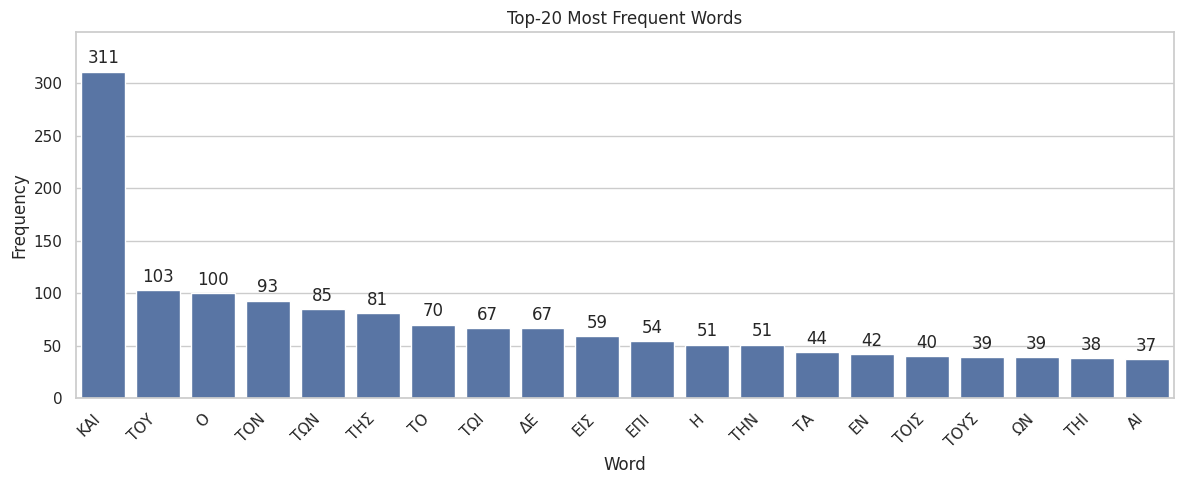

In [ ]:
# Plot 1: Top-20 most frequent words
top20_df = pd.DataFrame(
    word_counts.most_common(20),
    columns=["word", "frequency"]
)

plt.figure(figsize=(12, 5))

ax = sns.barplot(data=top20_df, x="word", y="frequency")

# Add exact counts near the top of each bar
ax.bar_label(
    ax.containers[0],
    labels=top20_df["frequency"],
    padding=3
)

plt.title("Top-20 Most Frequent Words")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, top20_df["frequency"].max() * 1.12)

plt.tight_layout()
plt.show()

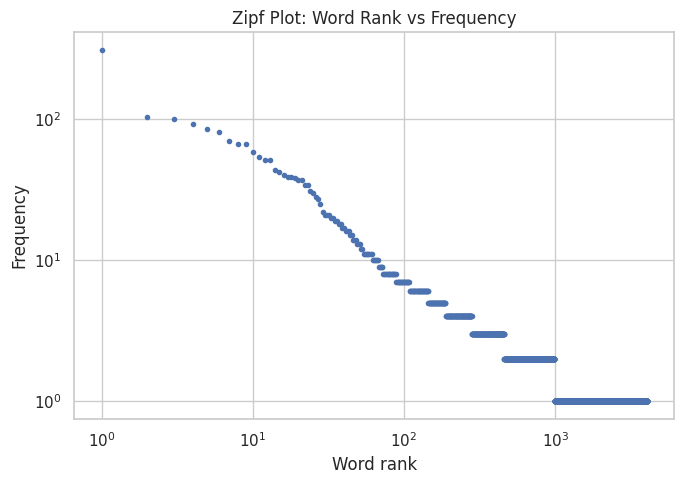

In [ ]:
# Plot 2: Zipf plot
frequencies = np.array(sorted(word_counts.values(), reverse=True))
ranks = np.arange(1, len(frequencies) + 1)

plt.figure(figsize=(7, 5))
plt.loglog(ranks, frequencies, marker=".", linestyle="none")
plt.title("Zipf Plot: Word Rank vs Frequency")
plt.xlabel("Word rank")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

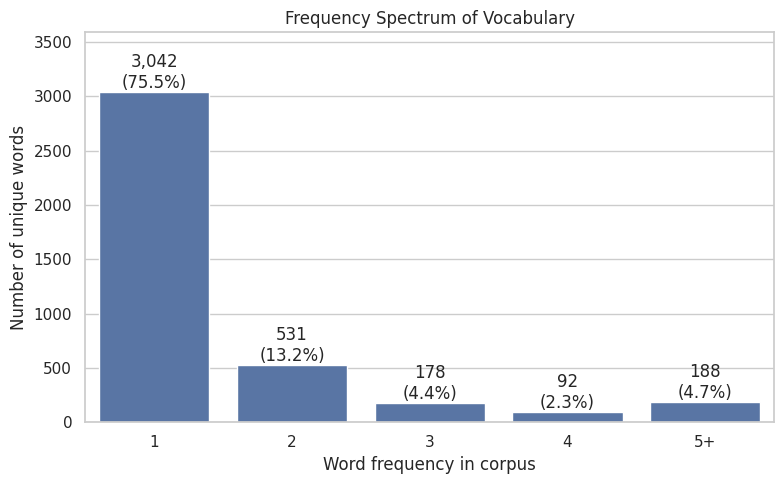

,frequency,number_of_words,percentage
0,1,3042,75.465145
1,2,531,13.172910
2,3,178,4.415778
3,4,92,2.282312
4,5+,188,4.663855


In [ ]:
# Plot 3: Frequency spectrum

frequency_spectrum = Counter(word_counts.values())

spectrum_df = pd.DataFrame({
    "frequency": ["1", "2", "3", "4", "5+"],
    "number_of_words": [
        frequency_spectrum.get(1, 0),
        frequency_spectrum.get(2, 0),
        frequency_spectrum.get(3, 0),
        frequency_spectrum.get(4, 0),
        sum(count for freq, count in frequency_spectrum.items() if freq >= 5)
    ]
})

spectrum_df["percentage"] = (
    spectrum_df["number_of_words"] / spectrum_df["number_of_words"].sum() * 100
)

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=spectrum_df,
    x="frequency",
    y="number_of_words"
)

for bar, count, pct in zip(
    ax.patches,
    spectrum_df["number_of_words"],
    spectrum_df["percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.title("Frequency Spectrum of Vocabulary")
plt.xlabel("Word frequency in corpus")
plt.ylabel("Number of unique words")
plt.ylim(0, spectrum_df["number_of_words"].max() * 1.18)

plt.tight_layout()
plt.show()

display(spectrum_df)

**Α4.** Εξερευνήστε τα κύρια ονόματα που εμφανίζονται στις επιγραφές σας και παρέχετε γραφήματα κατανομής συχνότητας ανά φύλο (gender). *(6 μονάδες)*

### A4 Solution:

To explore the proper names in the inscriptions, we used the cleaned Greek tokens from A3 as input. The corpus contained **8,036 clean Greek tokens** available for name detection. Proper names were detected using a **manual stem-based lexicon** of common Ancient Greek personal names. Each lexicon entry contained a lemma, a stem, and a gender label. For each token, we normalized the text, checked whether it matched a known name stem, and accepted it only if the remaining ending was a plausible Greek case ending. Common inscriptional or grammatical words were excluded using a stopword list, so that articles, prepositions, and formulaic terms would not be incorrectly counted as names.

After detecting name tokens, we grouped the results by **lemma** and **gender**. For each detected name, we calculated its total frequency, the number of different observed forms, and the number of inscriptions in which it appeared. This allowed us to examine both repeated name mentions and distinct personal-name types.

In total, **366 proper-name tokens** were detected. The gender distribution was strongly male-dominated: **317 tokens were male names**, corresponding to **86.6%**, while **49 tokens were female names**, corresponding to **13.4%**. The same pattern appears when counting distinct name lemmas: there were **51 distinct male names** (**85.0%**) and **9 distinct female names** (**15.0%**). Male names also appeared across more inscriptions, with male names found in **73 inscriptions** and female names in **35 inscriptions**.

The most frequent detected names were mainly male. The most common name was **ΔΙΟΝΥΣΙΟΣ** with **29 occurrences**, followed by **ΖΩΣΙΜΟΣ** with **26 occurrences**. Other frequent male names included **ΔΗΜΗΤΡΙΟΣ**, **ΑΠΟΛΛΩΝΙΟΣ**, **ΗΡΑΚΛΕΙΔΗΣ**, **ΕΥΤΥΧΟΣ**, **ΕΥΟΔΟΣ**, and **ΕΥΚΑΡΠΟΣ**. The most frequent female names included **ΑΘΗΝΑΙΣ** and **ΑΓΑΘΗ**, both appearing among the top detected names.

The visualizations confirm these findings. The gender distribution plots show that both the total number of name tokens and the number of distinct names are much higher for male names than for female names. The top-15 frequency plot also shows that the highest-frequency names are mostly male, with only a small number of female names appearing among the most common detected names. Overall, the inscriptions contain a clear imbalance in detected proper names, with male personal names being much more frequent and more diverse than female personal names.

In [ ]:
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"
all_words_for_a4 = [
    word
    for words in clean_words.values()
    for word in words
]

print(f"Clean Greek tokens available for A4: {len(all_words_for_a4):,}")

Clean Greek tokens available for A4: 8,036


In [ ]:
# Lexicon of common Ancient Greek personal names.
# Stems allow us to detect simple inflected forms, e.g. ΔΙΟΝΥΣΙΟΥ from ΔΙΟΝΥΣΙΟΣ.

NAME_LEXICON = [
    # ========== MALE NAMES ==========
    {"lemma": "ΑΛΕΞΑΝΔΡΟΣ", "stem": "ΑΛΕΞΑΝΔΡ", "gender": "male"},
    {"lemma": "ΔΙΟΝΥΣΙΟΣ", "stem": "ΔΙΟΝΥΣΙ", "gender": "male"},
    {"lemma": "ΔΗΜΗΤΡΙΟΣ", "stem": "ΔΗΜΗΤΡΙ", "gender": "male"},
    {"lemma": "ΘΕΟΔΩΡΟΣ", "stem": "ΘΕΟΔΩΡ", "gender": "male"},
    {"lemma": "ΑΠΟΛΛΩΝΙΟΣ", "stem": "ΑΠΟΛΛΩΝΙ", "gender": "male"},
    {"lemma": "ΗΡΑΚΛΕΙΔΗΣ", "stem": "ΗΡΑΚΛΕΙΔ", "gender": "male"},
    {"lemma": "ΦΙΛΙΠΠΟΣ", "stem": "ΦΙΛΙΠΠ", "gender": "male"},
    {"lemma": "ΝΙΚΟΛΑΟΣ", "stem": "ΝΙΚΟΛΑ", "gender": "male"},
    {"lemma": "ΠΤΟΛΕΜΑΙΟΣ", "stem": "ΠΤΟΛΕΜΑΙ", "gender": "male"},
    {"lemma": "ΣΩΚΡΑΤΗΣ", "stem": "ΣΩΚΡΑΤ", "gender": "male"},
    {"lemma": "ΜΕΝΑΝΔΡΟΣ", "stem": "ΜΕΝΑΝΔΡ", "gender": "male"},
    {"lemma": "ΑΠΟΛΛΟΔΩΡΟΣ", "stem": "ΑΠΟΛΛΟΔΩΡ", "gender": "male"},
    {"lemma": "ΑΡΙΣΤΩΝ", "stem": "ΑΡΙΣΤΩΝ", "gender": "male"},
    {"lemma": "ΘΕΩΝ", "stem": "ΘΕΩΝ", "gender": "male"},
    {"lemma": "ΑΜΜΩΝΙΟΣ", "stem": "ΑΜΜΩΝΙ", "gender": "male"},
    {"lemma": "ΣΑΡΑΠΙΩΝ", "stem": "ΣΑΡΑΠΙΩΝ", "gender": "male"},
    {"lemma": "ΗΡΩΔΗΣ", "stem": "ΗΡΩΔ", "gender": "male"},
    {"lemma": "ΣΩΤΗΡΙΧΟΣ", "stem": "ΣΩΤΗΡΙΧ", "gender": "male"},
    {"lemma": "ΖΩΣΙΜΟΣ", "stem": "ΖΩΣΙΜ", "gender": "male"},
    {"lemma": "ΑΓΑΘΟΚΛΗΣ", "stem": "ΑΓΑΘΟΚΛ", "gender": "male"},
    {"lemma": "ΑΓΑΘΩΝ", "stem": "ΑΓΑΘΩΝ", "gender": "male"},
    {"lemma": "ΑΙΣΧΙΝΗΣ", "stem": "ΑΙΣΧΙΝ", "gender": "male"},
    {"lemma": "ΑΝΔΡΟΝΙΚΟΣ", "stem": "ΑΝΔΡΟΝΙΚ", "gender": "male"},
    {"lemma": "ΑΝΤΙΓΟΝΟΣ", "stem": "ΑΝΤΙΓΟΝ", "gender": "male"},
    {"lemma": "ΑΝΤΙΠΑΤΡΟΣ", "stem": "ΑΝΤΙΠΑΤΡ", "gender": "male"},
    {"lemma": "ΑΤΤΙΚΟΣ", "stem": "ΑΤΤΙΚ", "gender": "male"},
    {"lemma": "ΔΗΜΟΣΘΕΝΗΣ", "stem": "ΔΗΜΟΣΘΕΝ", "gender": "male"},
    {"lemma": "ΔΙΟΔΩΡΟΣ", "stem": "ΔΙΟΔΩΡ", "gender": "male"},
    {"lemma": "ΔΙΟΓΕΝΗΣ", "stem": "ΔΙΟΓΕΝ", "gender": "male"},
    {"lemma": "ΕΥΚΛΕΙΔΗΣ", "stem": "ΕΥΚΛΕΙΔ", "gender": "male"},
    {"lemma": "ΗΡΑΚΛΗΣ", "stem": "ΗΡΑΚΛ", "gender": "male"},
    {"lemma": "ΘΕΟΦΙΛΟΣ", "stem": "ΘΕΟΦΙΛ", "gender": "male"},
    {"lemma": "ΙΣΟΚΡΑΤΗΣ", "stem": "ΙΣΟΚΡΑΤ", "gender": "male"},
    {"lemma": "ΚΑΛΛΙΚΡΑΤΗΣ", "stem": "ΚΑΛΛΙΚΡΑΤ", "gender": "male"},
    {"lemma": "ΛΥΣΑΝΔΡΟΣ", "stem": "ΛΥΣΑΝΔΡ", "gender": "male"},
    {"lemma": "ΝΙΚΙΑΣ", "stem": "ΝΙΚΙ", "gender": "male"},
    {"lemma": "ΞΕΝΟΦΩΝ", "stem": "ΞΕΝΟΦΩΝ", "gender": "male"},
    {"lemma": "ΠΕΡΙΚΛΗΣ", "stem": "ΠΕΡΙΚΛ", "gender": "male"},
    {"lemma": "ΠΛΑΤΩΝ", "stem": "ΠΛΑΤΩΝ", "gender": "male"},
    {"lemma": "ΣΤΡΑΤΩΝ", "stem": "ΣΤΡΑΤΩΝ", "gender": "male"},
    {"lemma": "ΤΙΜΟΘΕΟΣ", "stem": "ΤΙΜΟΘΕ", "gender": "male"},
    {"lemma": "ΧΑΙΡΕΦΩΝ", "stem": "ΧΑΙΡΕΦΩΝ", "gender": "male"},
    {"lemma": "ΥΓΕΙΝΟΣ", "stem": "ΥΓΕΙΝ", "gender": "male"},
    {"lemma": "ΕΥΤΥΧΟΣ", "stem": "ΕΥΤΥΧ", "gender": "male"},
    {"lemma": "ΕΡΜΙΑΣ", "stem": "ΕΡΜΙ", "gender": "male"},
    {"lemma": "ΚΛΑΥΔΙΟΣ", "stem": "ΚΛΑΥΔΙ", "gender": "male"},
    {"lemma": "ΑΡΤΕΜΩΝ", "stem": "ΑΡΤΕΜΩΝ", "gender": "male"},
    {"lemma": "ΕΥΤΥΧΙΔΗΣ", "stem": "ΕΥΤΥΧΙΔ", "gender": "male"},
    {"lemma": "ΑΣΚΛΗΠΙΑΔΗΣ", "stem": "ΑΣΚΛΗΠΙΑΔ", "gender": "male"},
    {"lemma": "ΦΙΛΗΤΟΣ", "stem": "ΦΙΛΗΤ", "gender": "male"},
    {"lemma": "ΑΒΑΣΚΑΝΤΟΣ", "stem": "ΑΒΑΣΚΑΝΤ", "gender": "male"},
    {"lemma": "ΝΕΙΚΙΑΣ", "stem": "ΝΕΙΚΙ", "gender": "male"},
    {"lemma": "ΕΙΡΗΝΑΙΟΣ", "stem": "ΕΙΡΗΝΑΙ", "gender": "male"},
    {"lemma": "ΜΗΝΟΔΩΡΟΣ", "stem": "ΜΗΝΟΔΩΡ", "gender": "male"},
    {"lemma": "ΖΩΠΥΡΟΣ", "stem": "ΖΩΠΥΡ", "gender": "male"},
    {"lemma": "ΕΥΟΔΟΣ", "stem": "ΕΥΟΔ", "gender": "male"},
    {"lemma": "ΕΥΚΑΡΠΟΣ", "stem": "ΕΥΚΑΡΠ", "gender": "male"},
    {"lemma": "ΑΓΑΘΟΠΟΥΣ", "stem": "ΑΓΑΘΟΠ", "gender": "male"},
    {"lemma": "ΕΠΙΓΟΝΟΣ", "stem": "ΕΠΙΓΟΝ", "gender": "male"},
    {"lemma": "ΑΝΤΙΟΧΟΣ", "stem": "ΑΝΤΙΟΧ", "gender": "male"},
    {"lemma": "ΘΑΛΛΟΣ", "stem": "ΘΑΛΛ", "gender": "male"},
    {"lemma": "ΕΠΑΓΑΘΟΣ", "stem": "ΕΠΑΓΑΘ", "gender": "male"},
    {"lemma": "ΕΙΣΙΔΟΤΟΣ", "stem": "ΕΙΣΙΔΟΤ", "gender": "male"},
    {"lemma": "ΕΥΠΟΡΟΣ", "stem": "ΕΥΠΟΡ", "gender": "male"},

    # ========== FEMALE NAMES ==========
    {"lemma": "ΚΛΕΟΠΑΤΡΑ", "stem": "ΚΛΕΟΠΑΤΡ", "gender": "female"},
    {"lemma": "ΑΡΣΙΝΟΗ", "stem": "ΑΡΣΙΝΟ", "gender": "female"},
    {"lemma": "ΒΕΡΕΝΙΚΗ", "stem": "ΒΕΡΕΝΙΚ", "gender": "female"},
    {"lemma": "ΕΙΡΗΝΗ", "stem": "ΕΙΡΗΝ", "gender": "female"},
    {"lemma": "ΣΩΤΗΡΙΑ", "stem": "ΣΩΤΗΡΙ", "gender": "female"},
    {"lemma": "ΔΙΔΥΜΗ", "stem": "ΔΙΔΥΜ", "gender": "female"},
    {"lemma": "ΗΡΑΙΣ", "stem": "ΗΡΑΙ", "gender": "female"},
    {"lemma": "ΘΑΙΣ", "stem": "ΘΑΙ", "gender": "female"},
    {"lemma": "ΤΑΥΣΙΡΙΣ", "stem": "ΤΑΥΣΙΡ", "gender": "female"},
    {"lemma": "ΤΑΠΟΝΤΩΣ", "stem": "ΤΑΠΟΝΤΩ", "gender": "female"},
    {"lemma": "ΑΓΑΘΗ", "stem": "ΑΓΑΘ", "gender": "female"},
    {"lemma": "ΑΛΕΞΑΝΔΡΑ", "stem": "ΑΛΕΞΑΝΔΡ", "gender": "female"},
    {"lemma": "ΑΝΤΙΓΟΝΗ", "stem": "ΑΝΤΙΓΟΝ", "gender": "female"},
    {"lemma": "ΑΡΙΣΤΟΜΑΧΗ", "stem": "ΑΡΙΣΤΟΜΑΧ", "gender": "female"},
    {"lemma": "ΑΡΤΕΜΙΣ", "stem": "ΑΡΤΕΜΙ", "gender": "female"},
    {"lemma": "ΑΡΤΕΜΙΔΩΡΑ", "stem": "ΑΡΤΕΜΙΔΩΡ", "gender": "female"},
    {"lemma": "ΑΣΠΑΣΙΑ", "stem": "ΑΣΠΑΣΙ", "gender": "female"},
    {"lemma": "ΑΘΗΝΑΙΣ", "stem": "ΑΘΗΝΑΙ", "gender": "female"},
    {"lemma": "ΔΗΜΗΤΡΑ", "stem": "ΔΗΜΗΤΡ", "gender": "female"},
    {"lemma": "ΔΙΟΝΥΣΙΑ", "stem": "ΔΙΟΝΥΣΙ", "gender": "female"},
    {"lemma": "ΕΥΔΟΞΙΑ", "stem": "ΕΥΔΟΞΙ", "gender": "female"},
    {"lemma": "ΕΥΤΥΧΙΑ", "stem": "ΕΥΤΥΧΙ", "gender": "female"},
    {"lemma": "ΘΕΟΔΩΡΑ", "stem": "ΘΕΟΔΩΡ", "gender": "female"},
    {"lemma": "ΚΑΛΛΙΣΤΗ", "stem": "ΚΑΛΛΙΣΤ", "gender": "female"},
    {"lemma": "ΛΑΟΔΙΚΗ", "stem": "ΛΑΟΔΙΚ", "gender": "female"},
    {"lemma": "ΜΑΡΙΑ", "stem": "ΜΑΡΙ", "gender": "female"},
    {"lemma": "ΝΙΚΗ", "stem": "ΝΙΚ", "gender": "female"},
    {"lemma": "ΟΛΥΜΠΙΑΣ", "stem": "ΟΛΥΜΠΙΑ", "gender": "female"},
    {"lemma": "ΠΛΟΥΤΑΡΧΗ", "stem": "ΠΛΟΥΤΑΡΧ", "gender": "female"},
    {"lemma": "ΣΟΦΙΑ", "stem": "ΣΟΦΙ", "gender": "female"},
    {"lemma": "ΣΤΡΑΤΟΝΙΚΗ", "stem": "ΣΤΡΑΤΟΝΙΚ", "gender": "female"},
    {"lemma": "ΤΙΜΗ", "stem": "ΤΙΜ", "gender": "female"},
    {"lemma": "ΦΙΛΗ", "stem": "ΦΙΛ", "gender": "female"},
    {"lemma": "ΧΑΡΙΚΛΕΙΑ", "stem": "ΧΑΡΙΚΛΕΙ", "gender": "female"},
    {"lemma": "ΑΜΜΙΑ", "stem": "ΑΜΜΙ", "gender": "female"},
    {"lemma": "ΑΠΦΙΑ", "stem": "ΑΠΦΙ", "gender": "female"},
    {"lemma": "ΑΡΤΕΜΙΣΙΑ", "stem": "ΑΡΤΕΜΙΣΙ", "gender": "female"},
    {"lemma": "ΔΗΜΗΤΡΙΑ", "stem": "ΔΗΜΗΤΡΙ", "gender": "female"},
    {"lemma": "ΗΡΑΚΛΕΙΑ", "stem": "ΗΡΑΚΛΕΙ", "gender": "female"},
    {"lemma": "ΘΕΟΔΟΤΗ", "stem": "ΘΕΟΔΟΤ", "gender": "female"},
    {"lemma": "ΙΟΥΛΙΑ", "stem": "ΙΟΥΛΙ", "gender": "female"},
    {"lemma": "ΚΛΑΥΔΙΑ", "stem": "ΚΛΑΥΔΙ", "gender": "female"},
    {"lemma": "ΖΩΣΙΜΗ", "stem": "ΖΩΣΙΜ", "gender": "female"},
    {"lemma": "ΕΥΤΥΧΗ", "stem": "ΕΥΤΥΧ", "gender": "female"},
    {"lemma": "ΕΥΠΡΑΞΙΑ", "stem": "ΕΥΠΡΑΞΙ", "gender": "female"},
    {"lemma": "ΝΙΚΑ", "stem": "ΝΙΚΑ", "gender": "female"},
    {"lemma": "ΠΑΥΛΑ", "stem": "ΠΑΥΛ", "gender": "female"},
    {"lemma": "ΡΟΥΦΙΝΑ", "stem": "ΡΟΥΦΙΝ", "gender": "female"},
    {"lemma": "ΣΩΣΙΠΑΤΡΑ", "stem": "ΣΩΣΙΠΑΤΡ", "gender": "female"},
    {"lemma": "ΦΙΛΟΥΜΕΝΗ", "stem": "ΦΙΛΟΥΜΕΝ", "gender": "female"},
]

# Common grammatical / inscriptional words that should never be counted as names.
NAME_STOPWORDS = {
    "ΑΓΑΘΗΙ", "ΤΥΧΗΙ", "ΒΟΥΛΗ", "ΒΟΥΛΗΙ", "ΔΗΜΟΣ", "ΔΗΜΩΙ",
    "ΠΟΛΙΣ", "ΠΟΛΕΩΣ", "ΕΔΟΞΕΝ", "ΚΑΙ", "ΔΕ", "ΤΟΥ", "ΤΗΣ",
    "ΤΩΝ", "ΤΟΝ", "ΤΗΝ", "ΤΟΙΣ", "ΤΑΙΣ", "ΕΝ", "ΕΠΙ", "ΠΕΡΙ",
    "ΠΡΟΣ", "ΚΑΤΑ", "ΑΠΟ", "ΥΠΕΡ", "ΠΑΡΑ", "ΜΕΤΑ", "ΔΙΑ"
}

# Allow only short, plausible case endings after a name stem.
# This prevents the model from counting arbitrary long words that merely start
# with a name-like sequence.
PLAUSIBLE_NAME_ENDINGS = {
    "",
    "Σ", "Ν",
    "ΟΣ", "ΟΝ", "ΟΥ", "ΩΙ", "Ω", "Ε",
    "ΗΣ", "ΗΝ", "Η", "ΑΙ", "ΑΙΣ",
    "ΑΣ", "ΑΝ", "Α", "ΑΙ", "ΗΣ",
    "ΙΟΣ", "ΙΟΝ", "ΙΟΥ", "ΙΩΙ", "ΙΩΝ",
    "ΕΙΟΣ", "ΕΙΟΥ",
}

NAME_LEXICON = sorted(NAME_LEXICON, key=lambda x: len(x["stem"]), reverse=True)


def normalize_name_text(x):
    """Normalize a token for name matching."""
    x = normalize_greek(str(x))
    x = re.sub(r"[^Α-Ω]", "", x)
    return x


def match_proper_name(word):
    """Return the first matching name entry, or None."""
    word = normalize_name_text(word)

    if word in NAME_STOPWORDS or len(word) < 4:
        return None

    for entry in NAME_LEXICON:
        stem = entry["stem"]

        if not word.startswith(stem):
            continue

        ending = word[len(stem):]

        if ending in PLAUSIBLE_NAME_ENDINGS:
            return entry

    return None

In [ ]:
# Detect proper-name tokens.

name_records = []

for inscription_id, words in clean_words.items():
    for word in words:
        match = match_proper_name(word)

        if match is not None:
            name_records.append({
                "inscription_id": inscription_id,
                "token": word,
                "lemma": match["lemma"],
                "gender": match["gender"],
                "source": "manual_stem_lexicon",
            })

names_df = pd.DataFrame(
    name_records,
    columns=["inscription_id", "token", "lemma", "gender", "source"],
)

print(f"Detected proper-name tokens: {len(names_df):,}")

if len(names_df) > 0:
    print("By gender:", names_df["gender"].value_counts().to_dict())
else:
    print("No names detected. The name lexicon may need to be extended.")
names_df.head(15)

Detected proper-name tokens: 375
By gender: {'male': 317, 'female': 58}


,inscription_id,token,lemma,gender,source
0,Agora_I_5477_Rotation1_300dpi,ΑΘΗΝΑΙ,ΑΘΗΝΑΙΣ,female,manual_stem_lexicon
1,Agora_I_5477_Rotation1_300dpi,ΚΑΛΛΙΣΤ,ΚΑΛΛΙΣΤΗ,female,manual_stem_lexicon
2,Agora_I_5477_Rotation1_300dpi,ΑΘΗΝΑΙ,ΑΘΗΝΑΙΣ,female,manual_stem_lexicon
3,IAS33117_Merged_Rotation1_300dpi,ΙΟΥΛΙ,ΙΟΥΛΙΑ,female,manual_stem_lexicon
4,IAS33118_Merged_Rotation1_300dpi,ΙΟΥΛΙΟΥ,ΙΟΥΛΙΑ,female,manual_stem_lexicon
5,IAS33147_Rotation1_300dpi,ΑΡΤΕΜΙΔΩΡΑΝ,ΑΡΤΕΜΙΔΩΡΑ,female,manual_stem_lexicon
6,IAS33161_Rotation1_300dpi,ΖΩΣΙΜΩ,ΖΩΣΙΜΟΣ,male,manual_stem_lexicon
7,IAS33163_Rotation1_300dpi,ΙΟΥΛΙΟΝ,ΙΟΥΛΙΑ,female,manual_stem_lexicon
8,IAS33166_Rotation1_300dpi,ΑΝΤΙΓΟΝΩ,ΑΝΤΙΓΟΝΟΣ,male,manual_stem_lexicon
9,IAS_27281_Rotation1_300dpi,ΚΛΑΥΔΙΟΝ,ΚΛΑΥΔΙΟΣ,male,manual_stem_lexicon


In [ ]:
# Frequency of detected proper names.

if len(names_df) > 0:
    name_freq_df = (
        names_df
        .groupby(["lemma", "gender"], as_index=False)
        .agg(
            frequency=("token", "count"),
            different_forms=("token", "nunique"),
            inscriptions=("inscription_id", "nunique"),
            observed_forms=("token", lambda values: ", ".join(sorted(set(values))))
        )
        .sort_values("frequency", ascending=False)
    )
else:
    name_freq_df = pd.DataFrame(
        columns=[
            "lemma", "gender", "frequency", "different_forms",
            "inscriptions", "observed_forms"
        ]
    )
name_freq_df.head(15)

,lemma,gender,frequency,different_forms,inscriptions,observed_forms
21,ΔΙΟΝΥΣΙΟΣ,male,29,4,23,"ΔΙΟΝΥΣΙΟΝ, ΔΙΟΝΥΣΙΟΣ, ΔΙΟΝΥΣΙΟΥ, ΔΙΟΝΥΣΙΣ"
34,ΖΩΣΙΜΟΣ,male,26,5,16,"ΖΩΣΙΜ, ΖΩΣΙΜΟΝ, ΖΩΣΙΜΟΣ, ΖΩΣΙΜΟΥ, ΖΩΣΙΜΩ"
4,ΑΘΗΝΑΙΣ,female,16,5,12,"ΑΘΗΝΑΙ, ΑΘΗΝΑΙΟΣ, ΑΘΗΝΑΙΟΥ, ΑΘΗΝΑΙΣ, ΑΘΗΝΑΙΩ"
17,ΔΗΜΗΤΡΙΟΣ,male,15,4,14,"ΔΗΜΗΤΡΙ, ΔΗΜΗΤΡΙΟΝ, ΔΗΜΗΤΡΙΟΣ, ΔΗΜΗΤΡΙΟΥ"
1,ΑΓΑΘΗ,female,14,5,11,"ΑΓΑΘΑ, ΑΓΑΘΑΝ, ΑΓΑΘΗ, ΑΓΑΘΟΝ, ΑΓΑΘΟΣ"
11,ΑΠΟΛΛΩΝΙΟΣ,male,13,4,11,"ΑΠΟΛΛΩΝΙ, ΑΠΟΛΛΩΝΙΟΣ, ΑΠΟΛΛΩΝΙΟΥ, ΑΠΟΛΛΩΝΙΣ"
37,ΗΡΑΚΛΕΙΔΗΣ,male,11,3,6,"ΗΡΑΚΛΕΙΔΗΝ, ΗΡΑΚΛΕΙΔΗΣ, ΗΡΑΚΛΕΙΔΟΥ"
32,ΕΥΤΥΧΟΣ,male,10,4,6,"ΕΥΤΥΧ, ΕΥΤΥΧΗΣ, ΕΥΤΥΧΟΣ, ΕΥΤΥΧΟΥ"
29,ΕΥΟΔΟΣ,male,10,3,6,"ΕΥΟΔ, ΕΥΟΔΟΣ, ΕΥΟΔΟΥ"
27,ΕΥΚΑΡΠΟΣ,male,9,2,7,"ΕΥΚΑΡΠΟΣ, ΕΥΚΑΡΠΟΥ"


In [ ]:
# Gender summary.
if len(names_df) > 0:
    gender_summary = (
        names_df
        .groupby("gender", as_index=False)
        .agg(
            token_count=("token", "count"),
            name_types=("lemma", "nunique"),
            inscriptions=("inscription_id", "nunique")
        )
        .sort_values("token_count", ascending=False)
    )
else:
    gender_summary = pd.DataFrame(
        columns=["gender", "token_count", "name_types", "inscriptions"]
    )
gender_summary.head()

,gender,token_count,name_types,inscriptions
1,male,317,51,73
0,female,58,14,43


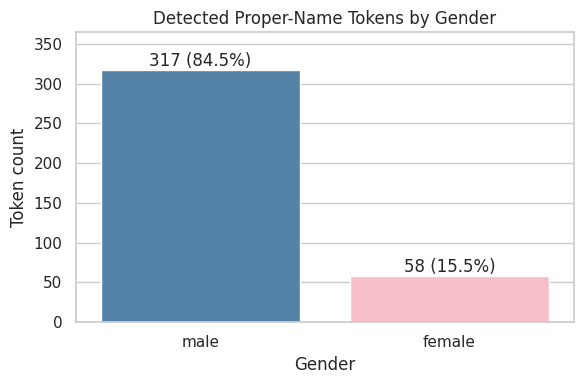

,gender,token_count,name_types,inscriptions,percentage
1,male,317,51,73,84.533333
0,female,58,14,43,15.466667


In [ ]:
gender_summary["percentage"] = (
    gender_summary["token_count"] / gender_summary["token_count"].sum() * 100
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=gender_summary,
    x="gender",
    y="token_count",
    hue="gender",
    palette=["steelblue", "lightpink"],
    legend=False
)

for bar, count, pct in zip(
    ax.patches,
    gender_summary["token_count"],
    gender_summary["percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count)} ({pct:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.title("Detected Proper-Name Tokens by Gender")
plt.xlabel("Gender")
plt.ylabel("Token count")
plt.ylim(0, gender_summary["token_count"].max() * 1.15)

plt.tight_layout()
plt.show()

display(gender_summary)

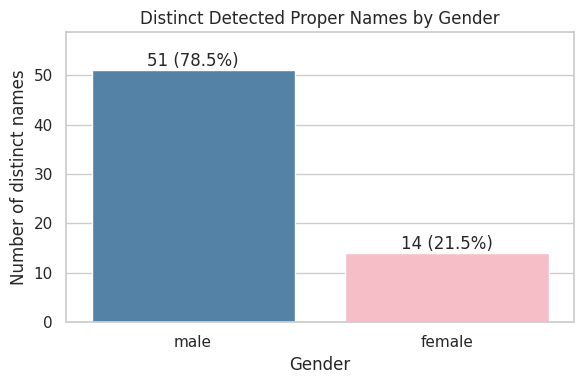

,gender,token_count,name_types,inscriptions,percentage,name_types_percentage
1,male,317,51,73,84.533333,78.461538
0,female,58,14,43,15.466667,21.538462


In [ ]:
# Plot 2: Number of distinct detected names by gender
gender_summary["name_types_percentage"] = (
    gender_summary["name_types"] / gender_summary["name_types"].sum() * 100
)

plt.figure(figsize=(6, 4))

ax = sns.barplot(
    data=gender_summary,
    x="gender",
    y="name_types",
    hue="gender",
    palette=["steelblue", "lightpink"],
    legend=False
)

for bar, count, pct in zip(
    ax.patches,
    gender_summary["name_types"],
    gender_summary["name_types_percentage"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(count)} ({pct:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.title("Distinct Detected Proper Names by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of distinct names")
plt.ylim(0, gender_summary["name_types"].max() * 1.15)

plt.tight_layout()
plt.show()

display(gender_summary)

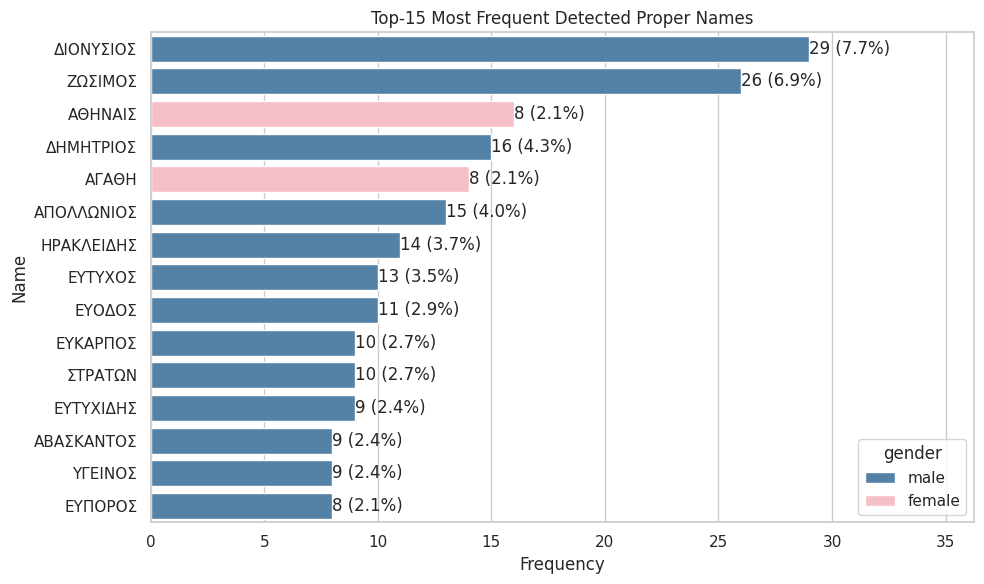

In [ ]:
top_names = name_freq_df.head(15).copy()

top_names["percentage"] = (
    top_names["frequency"] / name_freq_df["frequency"].sum() * 100
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_names,
    x="frequency",
    y="lemma",
    hue="gender",
    palette=["steelblue", "lightpink"],
    dodge=False
)

for bar, freq, pct in zip(
    ax.patches,
    top_names["frequency"],
    top_names["percentage"]
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f"{int(freq)} ({pct:.1f}%)",
        va="center",
        ha="left"
    )

plt.title("Top-15 Most Frequent Detected Proper Names")
plt.xlabel("Frequency")
plt.ylabel("Name")
plt.xlim(0, top_names["frequency"].max() * 1.25)

plt.tight_layout()
plt.show()

**Α5.** Ομαδοποιήστε (cluster) τις επιγραφές και απαντήστε: α) Αντιστοιχούν τα clusters σε ομοιότητες στη δομή κειμένου; β) Περιλαμβάνουν τα clusters επαναλαμβανόμενες φράσεις; γ) Εμφανίζονται συγκεκριμένα θέματα σε κάθε cluster; Χρησιμοποιήστε κατάλληλες μεθόδους topic modeling για να απαντήσετε στο τελευταίο ερώτημα. *(10 μονάδες)*


### A5 Solution:

### A5(a) Structural similarity
The structural summary shows that the two clusters differ mainly in text length and preservation. Cluster 0 is larger, with 142 inscriptions, but its inscriptions are shorter on average, with about 267 characters and 21 tokens. It also has a slightly higher damaged-marker ratio, about 10.2%, suggesting that this cluster contains shorter and more fragmentary texts. Cluster 1 is smaller, with 82 inscriptions, but its inscriptions are longer, averaging about 499 characters and 38 tokens, with a lower damaged-marker ratio of about 8.1%. The average token length is very similar in both clusters, so the main structural difference is not word shape, but inscription length and relative preservation.

### A5(b) Repeated phrases
Repeated phrases were extracted with phrase-level TF-IDF, so the results show phrases that are especially characteristic of each cluster. Cluster 1 has the clearest formulaic pattern, with phrases such as ΤΩΙ ΔΗΜΩΙ, ΕΔΟΞΕΝ ΤΗΙ, ΤΗΙ ΒΟΥΛΗΙ, and ΣΤΗΛΗΣ ΔΟΥΝΑΙ, which point to formal civic decree language. Cluster 0 is more mixed, with phrases such as ΙΕΡΕΥΣ ΑΝΤΙΝΟΟΥ, ΑΓΑΘΗ ΤΥΧΗ, ΔΗΜΟΣ ΑΘΗΝΑΙΩΝ, and ΠΡΥΤΑΝΕΙΑΣ ΕΚΚΛΗΣΙΑ, suggesting religious, honorific, and civic formulae. Overall, Cluster 1 appears more coherent, while Cluster 0 contains a broader range of formulaic and sometimes fragmentary material.

### A5(c) Topic analysis
The clustering and LDA results suggest that the corpus divides into two broad groups. Cluster 0 is larger, with 142 inscriptions, and is mainly associated with Topic 0. Its distinctive terms include names and formulaic words such as ΑΡΧΟΝΤΟΣ, ΖΩΣΙΜΟΣ, ΔΙΟΝΥΣΙΟΣ, ΔΙΟΝΥΣΙΟΥ, and ΔΗΜΗΤΡΙΟΣ, suggesting a group of name-heavy, honorific, religious, or more fragmentary inscriptions. However, it is not fully homogeneous, since 29.6% of its documents are assigned to Topic 1. Cluster 1 is smaller, with 82 inscriptions, but more coherent: 80.5% of its documents are assigned to Topic 1. Its vocabulary includes ΤΩΙ, ΤΗΙ, ΔΗΜΩΙ, ΑΘΗΝΑΙΩΝ, ΔΗΜΟΥ, ΕΠΑΙΝΕΣΑΙ, ΔΕΔΟΧΘΑΙ, ΕΔΟΞΕΝ, and ΒΟΥΛΗΣ, which are typical of Athenian civic decree language. Therefore, Cluster 1 can be interpreted as a group of public/civic decrees, while Cluster 0 represents a broader group of name-heavy, formulaic, and sometimes fragmentary inscriptions.

In [ ]:
#Prepare inscription documents for clustering and topic analysis

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"


GREEK_STOPWORDS = {
    "ΚΑΙ", "ΔΕ", "ΤΕ", "ΓΑΡ", "ΜΕΝ", "ΟΥΝ",
    "Ο", "Η", "ΤΟ", "ΤΟΥ", "ΤΗΣ", "ΤΩΝ",
    "ΤΟΝ", "ΤΗΝ", "ΤΟΙΣ", "ΤΑΙΣ", "ΤΟΥΣ", "ΤΑΣ",
    "ΕΝ", "ΕΙΣ", "ΕΚ", "ΕΞ", "ΕΠΙ", "ΠΡΟΣ",
    "ΑΠΟ", "ΥΠΕΡ", "ΚΑΤΑ", "ΔΙΑ", "ΜΕΤΑ", "ΠΑΡΑ"
}

def clean_tokens_for_a5(tokens):
    return [
        token
        for token in tokens
        if (
            keep_clean_greek_token(token)
            and len(token) >= 3
            and token not in GREEK_STOPWORDS
        )
    ]


def average_token_length(tokens):
    if len(tokens) == 0:
        return 0.0
    return float(np.mean([len(token) for token in tokens]))


a5_rows = []

for inscription_id, tokens in unique_segmented_transcripts.items():
    clean_tokens = clean_tokens_for_a5(tokens)
    raw_greek_text = greek_transcripts.get(inscription_id, "")
    raw_continuous_text = re.sub(r"[^Α-Ω]", "", normalize_greek(raw_greek_text))

    if len(clean_tokens) == 0:
        continue

    a5_rows.append({
        "inscription_id": inscription_id,
        "tokens": tokens,
        "clean_tokens": clean_tokens,
        "text": " ".join(clean_tokens),
        "raw_greek_text": raw_greek_text,
        "raw_continuous_text": raw_continuous_text,
        "char_length": len(raw_greek_text),
        "line_count": raw_greek_text.count("\n") + 1 if raw_greek_text else 0,
        "token_count": len(clean_tokens),
        "avg_token_length": average_token_length(clean_tokens),
        "damaged_marker_count": raw_greek_text.count("*"),
        "damaged_marker_ratio": raw_greek_text.count("*") / max(len(raw_greek_text), 1),
    })

a5_docs_df = pd.DataFrame(a5_rows)

print(f"Original segmented files: {len(segmented_transcripts):,}")
print(f"Unique inscription texts: {len(unique_segmented_transcripts):,}")
print(f"A5 documents used before optional filtering: {len(a5_docs_df):,}")

display(a5_docs_df.head())

Original segmented files: 448
Unique inscription texts: 226
A5 documents used before optional filtering: 224


,inscription_id,tokens,clean_tokens,text,raw_greek_text,raw_continuous_text,char_length,line_count,token_count,avg_token_length,damaged_marker_count,damaged_marker_ratio
0,Agora_I_4985_Rotation1_300dpi,"[ΣΤΟ, ΚΑΙ, *ΔΙΚΟ, ΣΕ*, ΙΗΙΔΙΚΗΤ, ΟΣΕΝ, ΝΕΑ*, Α...","[ΣΤΟ, ΙΗΙΔΙΚΗΤ, ΟΣΕΝ, ΑΥΤ, ΝΕΑΝΤΙΣΑ, ΣΙΑ, ΔΟΝΑ...",ΣΤΟ ΙΗΙΔΙΚΗΤ ΟΣΕΝ ΑΥΤ ΝΕΑΝΤΙΣΑ ΣΙΑ ΔΟΝΑΙ ΝΠΟΛΕ...,ΣΤΟΚΑΙ\n*ΔΙΚΟΣΕ*\nΙΗΙΔΙΚΗΤ\nΟΣΕΝΝΕΑ*\nΑΥΤΟΙΔ*\...,ΣΤΟΚΑΙΔΙΚΟΣΕΙΗΙΔΙΚΗΤΟΣΕΝΝΕΑΑΥΤΟΙΔΝΕΑΝΤΙΣΑΣΙΑΣΕ...,110,13,11,5.181818,10,0.090909
1,Agora_I_5477_Rotation1_300dpi,"[ΡΧΟΝΤΟΣ, *ΡΙΣΤΟΝΙΚΟΣ, ΑΡΙ, *Ν***ΗΙ, ΑΓΑΘΗΙ, Τ...","[ΡΧΟΝΤΟΣ, ΑΡΙ, ΑΓΑΘΗΙ, ΑΘΗΝΑΙ, ΘΥΣΙΑ, ΚΑΛΛΙΣΤ,...",ΡΧΟΝΤΟΣ ΑΡΙ ΑΓΑΘΗΙ ΑΘΗΝΑΙ ΘΥΣΙΑ ΚΑΛΛΙΣΤ ΙΚΡΟΙΣ...,ΡΧΟΝΤΟΣ\n*ΡΙΣΤΟΝΙΚΟΣ ΑΡΙ\n*Ν***ΗΙ ΑΓΑΘΗΙ ΤΟΥ Δ...,ΡΧΟΝΤΟΣΡΙΣΤΟΝΙΚΟΣΑΡΙΝΗΙΑΓΑΘΗΙΤΟΥΔΗΜΟΑΘΗΝΑΙΗΘΥΣ...,545,23,48,5.208333,23,0.042202
2,IAS24115_Rotation1_300dpi,"[******ΕΑΜΜΑΝΤΕΥΜΑΣΙΔΩΚΕΝ, ΕΥΧΗΣΕΞΑΩΝΚΟ******Ε...","[ΠΡΟΣΕΤΑΞΕΝ, ΟΝΙΜΟΣ, ΓΕΓΕΝΗΤΟ, ΣΩΜ, ΜΕΧΡΙ, ΕΧΟ...",ΠΡΟΣΕΤΑΞΕΝ ΟΝΙΜΟΣ ΓΕΓΕΝΗΤΟ ΣΩΜ ΜΕΧΡΙ ΕΧΟΥΣΑ ΜΗ...,******ΕΑΜΜΑΝΤΕΥΜΑΣΙΔΩΚΕΝ\nΕΥΧΗΣΕΞΑΩΝΚΟ******ΕΚ...,ΕΑΜΜΑΝΤΕΥΜΑΣΙΔΩΚΕΝΕΥΧΗΣΕΞΑΩΝΚΟΕΚΟΜΑΣΠΡΟΣΕΤΑΞΕΝ...,491,17,27,6.037037,76,0.154786
3,IAS33117_Merged_Rotation1_300dpi,"[ΙΟΥΛΙ, ΟΣΑ, ΒΗΤΟΣΝΕ, ΕΙΟΥΛΙΩ*, *ΗΤΩ, ΤΩ*, ΤΑ,...","[ΙΟΥΛΙ, ΟΣΑ, ΒΗΤΟΣΝΕ]",ΙΟΥΛΙ ΟΣΑ ΒΗΤΟΣΝΕ,ΙΟΥΛΙΟΣΑ\nΒΗΤΟΣΝΕ\nΕΙΟΥΛΙΩ*\n*ΗΤΩΤΩ*\nΤΑΝΤ*,ΙΟΥΛΙΟΣΑΒΗΤΟΣΝΕΕΙΟΥΛΙΩΗΤΩΤΩΤΑΝΤ,39,5,3,5.000000,4,0.102564
4,IAS33118_Merged_Rotation1_300dpi,"[ΝΕΡΟΥΑΝ, ), ΑΙΩΝ, ΠΟΛΙΣ, ΗΣΑΝ, ΤΑ, ΑΥΤΗ, Η, Τ...","[ΝΕΡΟΥΑΝ, ΑΙΩΝ, ΠΟΛΙΣ, ΗΣΑΝ, ΑΥΤΗ, ΤΡΟ, ΠΟΛΕΟΣ...",ΝΕΡΟΥΑΝ ΑΙΩΝ ΠΟΛΙΣ ΗΣΑΝ ΑΥΤΗ ΤΡΟ ΠΟΛΕΟΣ ΔΟΝΤΟΣ...,ΝΕΡΟΥΑΝ\n)ΑΙΩΝΠΟΛΙΣ\nΗΣΑΝΤΑΑΥΤΗ\nΗΤΡΟΠΟΛΕΟΣ\nΔ...,ΝΕΡΟΥΑΝΑΙΩΝΠΟΛΙΣΗΣΑΝΤΑΑΥΤΗΗΤΡΟΠΟΛΕΟΣΔΟΝΤΟΣΤΗΝΔ...,115,9,17,4.647059,1,0.008696


#### TF-IDF features and cluster selection

Word TF-IDF shape: (224, 1061)
Character TF-IDF shape: (224, 35763)
Combined feature matrix shape: (224, 36824)


,k,silhouette_score,min_cluster_size,cluster_sizes
0,2,0.013200,110,"{0: 110, 1: 114}"
1,3,0.011349,50,"{0: 50, 1: 103, 2: 71}"
2,4,0.010867,8,"{0: 8, 1: 78, 2: 39, 3: 99}"
3,5,0.006337,8,"{0: 8, 1: 59, 2: 34, 3: 95, 4: 28}"
4,6,0.007354,7,"{0: 7, 1: 59, 2: 33, 3: 89, 4: 25, 5: 11}"
5,7,0.011311,7,"{0: 7, 1: 56, 2: 29, 3: 83, 4: 23, 5: 11, 6: 15}"
6,8,-0.033882,1,"{0: 2, 1: 1, 2: 1, 3: 1, 4: 1, 5: 215, 6: 1, 7..."


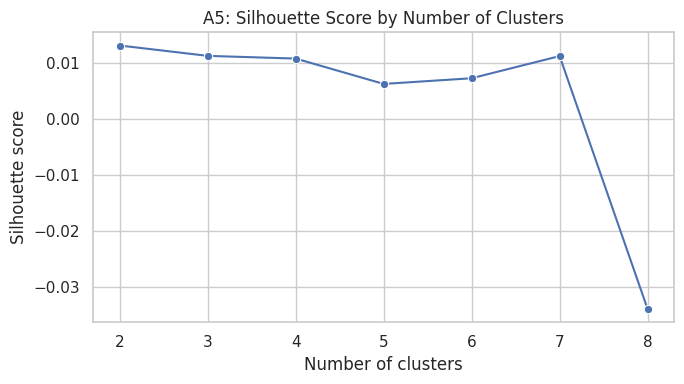

Selected number of clusters: k = 2
Final cluster sizes:


,num_inscriptions
cluster,
0,142
1,82


In [ ]:
# A5 Cell 2: TF-IDF features and cluster selection

if len(a5_docs_df) < 3:
    raise ValueError("A5 needs at least three usable inscription documents for silhouette-based clustering.")

texts = a5_docs_df["text"].tolist()
raw_continuous_texts = a5_docs_df["raw_continuous_text"].tolist()

# Word features capture content vocabulary and formulaic expressions.
word_vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b[Α-Ω]{3,}\b",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.85
)

# Character features use the raw continuous Greek text, so they are less dependent on A2 segmentation.
char_vectorizer = TfidfVectorizer(
    lowercase=False,
    analyzer="char",
    ngram_range=(4, 8),
    min_df=2,
    max_df=0.85
)

word_tfidf = word_vectorizer.fit_transform(texts)
char_tfidf = char_vectorizer.fit_transform(raw_continuous_texts)

X = hstack([
    0.75 * normalize(word_tfidf),
    0.25 * normalize(char_tfidf),
])

print(f"Word TF-IDF shape: {word_tfidf.shape}")
print(f"Character TF-IDF shape: {char_tfidf.shape}")
print(f"Combined feature matrix shape: {X.shape}")

max_candidate_k = min(8, len(a5_docs_df) - 1)
candidate_ks = range(2, max_candidate_k + 1)

silhouette_rows = []

for k in candidate_ks:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X)

    cluster_sizes = pd.Series(labels).value_counts().sort_index().to_dict()
    score = silhouette_score(X, labels, metric="cosine")

    silhouette_rows.append({
        "k": k,
        "silhouette_score": score,
        "min_cluster_size": min(cluster_sizes.values()),
        "cluster_sizes": cluster_sizes,
    })

silhouette_df = pd.DataFrame(silhouette_rows)

display(silhouette_df)

plt.figure(figsize=(7, 4))
sns.lineplot(data=silhouette_df, x="k", y="silhouette_score", marker="o")
plt.title("A5: Silhouette Score by Number of Clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.show()

best_k = int(
    silhouette_df
    .sort_values("silhouette_score", ascending=False)
    .iloc[0]["k"]
)

print(f"Selected number of clusters: k = {best_k}")

# Fit the final KMeans model using the selected number of clusters.
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
a5_docs_df["cluster"] = kmeans.fit_predict(X)

print("Final cluster sizes:")
display(
    a5_docs_df["cluster"]
    .value_counts()
    .sort_index()
    .rename("num_inscriptions")
    .to_frame()
)

Candidate `k` values were compared with cosine silhouette scores, then checked for cluster-size balance. The selected `k` avoids singleton clusters where possible, so the final clustering is based on both quantitative separation and interpretability.

#### Applying clustering and visualize clusters

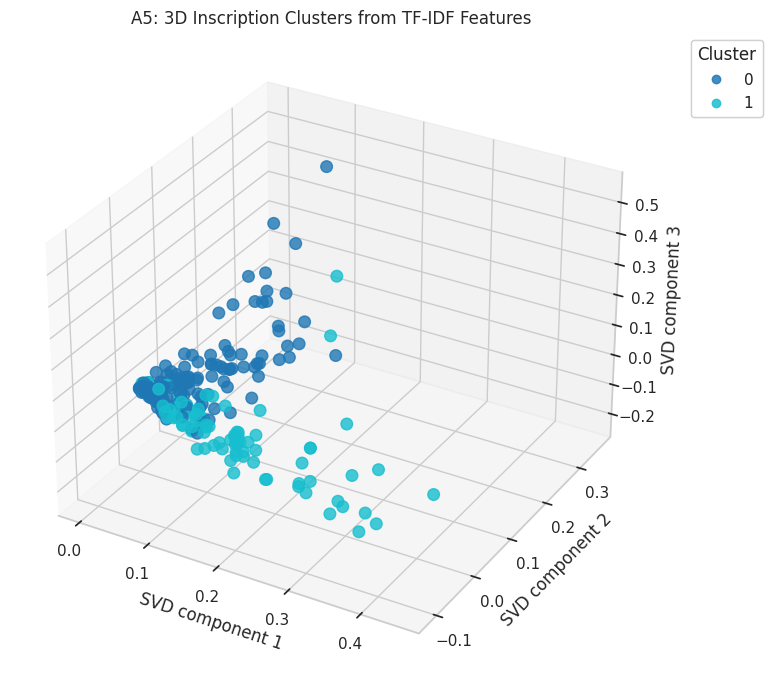

In [ ]:
# 3D visualization using TruncatedSVD.
if min(X.shape) >= 3:
    svd_3d = TruncatedSVD(n_components=3, random_state=42)
    coords_3d = svd_3d.fit_transform(X)
else:
    coords_3d = np.zeros((X.shape[0], 3))

a5_docs_df["svd_x"] = coords_3d[:, 0]
a5_docs_df["svd_y"] = coords_3d[:, 1]
a5_docs_df["svd_z"] = coords_3d[:, 2]

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    a5_docs_df["svd_x"],
    a5_docs_df["svd_y"],
    a5_docs_df["svd_z"],
    c=a5_docs_df["cluster"],
    cmap="tab10",
    s=70,
    alpha=0.8
)

ax.set_title("A5: 3D Inscription Clusters from TF-IDF Features")
ax.set_xlabel("SVD component 1")
ax.set_ylabel("SVD component 2")
ax.set_zlabel("SVD component 3")

legend = ax.legend(
    *scatter.legend_elements(),
    title="Cluster",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
ax.add_artist(legend)

plt.tight_layout()
plt.show()

#### A5(a): structural similarity by cluster

,cluster,num_inscriptions,mean_char_length,mean_line_count,mean_token_count,mean_avg_token_length,mean_damaged_marker_count,mean_damaged_marker_ratio
0,0,142,266.549296,19.176056,20.894366,6.270404,31.035211,0.101601
1,1,82,499.036585,22.536585,37.743902,6.158527,41.219512,0.081113


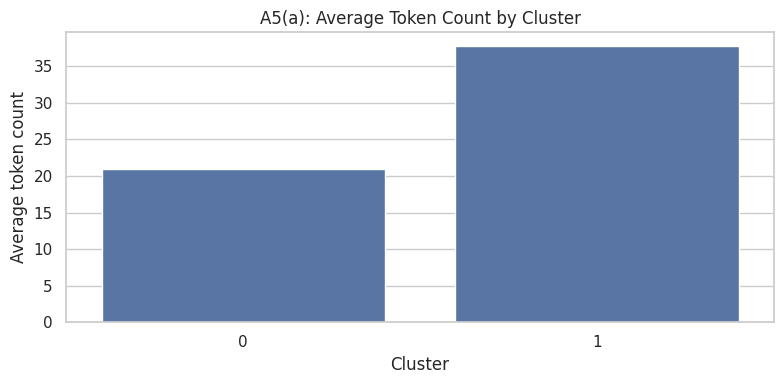

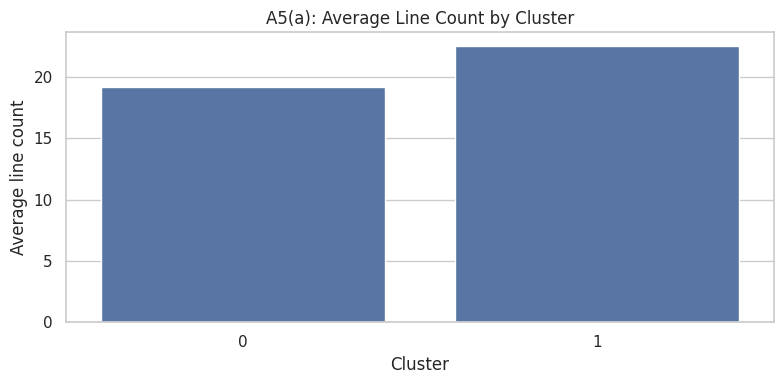

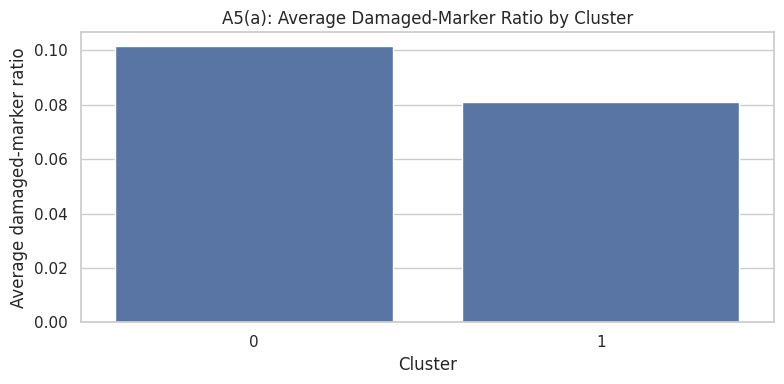

In [ ]:
# A5 Cell 4: A5(a) Structural similarity by cluster
a5_cluster_structure_summary_df = (
    a5_docs_df
    .groupby("cluster", as_index=False)
    .agg(
        num_inscriptions=("inscription_id", "count"),
        mean_char_length=("char_length", "mean"),
        mean_line_count=("line_count", "mean"),
        mean_token_count=("token_count", "mean"),
        mean_avg_token_length=("avg_token_length", "mean"),
        mean_damaged_marker_count=("damaged_marker_count", "mean"),
        mean_damaged_marker_ratio=("damaged_marker_ratio", "mean"),
    )
)

display(a5_cluster_structure_summary_df)


plt.figure(figsize=(8, 4))
sns.barplot(
    data=a5_cluster_structure_summary_df,
    x="cluster",
    y="mean_token_count"
)
plt.title("A5(a): Average Token Count by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average token count")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
sns.barplot(
    data=a5_cluster_structure_summary_df,
    x="cluster",
    y="mean_line_count"
)
plt.title("A5(a): Average Line Count by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average line count")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
sns.barplot(
    data=a5_cluster_structure_summary_df,
    x="cluster",
    y="mean_damaged_marker_ratio"
)
plt.title("A5(a): Average Damaged-Marker Ratio by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Average damaged-marker ratio")
plt.tight_layout()
plt.show()

#### A5(b): repeated phrases by cluster

In [ ]:
# A5 Cell 5: A5(b) Repeated phrases by cluster

phrase_vectorizer = TfidfVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b[Α-Ω]{3,}\b",
    ngram_range=(2, 4),
    min_df=2,
    max_df=0.90
)

phrase_tfidf = phrase_vectorizer.fit_transform(texts)
phrase_terms = phrase_vectorizer.get_feature_names_out()

phrase_rows = []

for cluster_id in sorted(a5_docs_df["cluster"].unique()):
    cluster_mask = a5_docs_df["cluster"].values == cluster_id
    cluster_mean_scores = np.asarray(
        phrase_tfidf[cluster_mask].mean(axis=0)
    ).ravel()

    top_indices = cluster_mean_scores.argsort()[::-1][:10]

    for index in top_indices:
        if cluster_mean_scores[index] <= 0:
            continue

        phrase_rows.append({
            "cluster": cluster_id,
            "phrase": phrase_terms[index],
            "mean_tfidf": cluster_mean_scores[index],
        })

a5_repeated_phrases_df = pd.DataFrame(
    phrase_rows,
    columns=["cluster", "phrase", "mean_tfidf"],
)

display(a5_repeated_phrases_df)

,cluster,phrase,mean_tfidf
0,0,ΙΕΡΕΥΣ ΑΝΤΙΝΟΟΥ,0.014085
1,0,ΑΓΑΘΗ ΤΥΧΗ,0.012022
2,0,ΔΗΜΟΣ ΑΘΗΝΑΙΩΝ,0.007042
3,0,ΕΙΠΕΝ ΕΠΕΙ,0.004980
4,0,ΠΡΥΤΑΝΕΙΑΣ ΕΚΚΛΗΣΙΑ,0.004980
5,0,ΣΥΜΠΡΟΕΔΡΟΙ ΕΔΟΞΕΝ,0.004980
6,0,ΑΙΤΩΙ ΔΗΜΩΙ,0.004980
7,0,ΑΓΑΘΗΙ ΤΥΧΗΙ,0.004980
8,0,ΑΖΗΝ ΠΩΝ ΥΜΟΣ ΑΙΛ,0.001774
9,0,ΟΥΣ ΟΠΛ,0.001774


#### A5(c) Topic modeling with LDA

In [ ]:
pd.set_option("display.max_colwidth", None)

# LDA uses raw word counts, not TF-IDF.
topic_vectorizer = CountVectorizer(
    lowercase=False,
    token_pattern=r"(?u)\b[Α-Ω]{3,}\b",
    min_df=2,
    max_df=0.75
)

topic_counts = topic_vectorizer.fit_transform(texts)
topic_terms = topic_vectorizer.get_feature_names_out()

num_topics = min(best_k, 8)

lda_model = LatentDirichletAllocation(
    n_components=num_topics,
    random_state=42,
    learning_method="batch",
    max_iter=50,
    doc_topic_prior=0.1,
    topic_word_prior=0.1
)

topic_matrix = lda_model.fit_transform(topic_counts)

# Top words per topic
top_n_words = 25
topic_rows = []

for topic_id, weights in enumerate(lda_model.components_):
    top_indices = weights.argsort()[::-1][:top_n_words]
    top_words = [topic_terms[i] for i in top_indices]

    topic_rows.append({
        "topic": topic_id,
        "top_words": ", ".join(top_words)
    })

a5_topic_words_df = pd.DataFrame(topic_rows)

display(a5_topic_words_df)

# Assign each document to its strongest LDA topic.
a5_docs_df["dominant_topic"] = topic_matrix.argmax(axis=1)
a5_docs_df["dominant_topic_probability"] = topic_matrix.max(axis=1)

# Add readable topic labels.
topic_label_map = {
    row["topic"]: f"Topic {row['topic']}: {row['top_words']}"
    for _, row in a5_topic_words_df.iterrows()
}

a5_docs_df["dominant_topic_words"] = a5_docs_df["dominant_topic"].map(topic_label_map)

# Show dominant topic for each inscription.
display(
    a5_docs_df[
        [
            "cluster",
            "dominant_topic",
            "dominant_topic_probability",
            "dominant_topic_words",
            "text"
        ]
    ].head(20)
)

# Raw topic counts per cluster.
a5_topic_by_cluster_df = pd.crosstab(
    a5_docs_df["cluster"],
    a5_docs_df["dominant_topic"]
)

a5_topic_by_cluster_df.columns = [
    f"Topic {col}" for col in a5_topic_by_cluster_df.columns
]

display(a5_topic_by_cluster_df)

# Topic percentages per cluster.
a5_topic_by_cluster_pct_df = pd.crosstab(
    a5_docs_df["cluster"],
    a5_docs_df["dominant_topic"],
    normalize="index"
).round(3)

a5_topic_by_cluster_pct_df.columns = [
    f"Topic {col}" for col in a5_topic_by_cluster_pct_df.columns
]

display(a5_topic_by_cluster_pct_df)

,topic,top_words
0,0,"ΖΩΣΙΜΟΣ, ΔΙΟΝΥΣΙΟΣ, ΟΥΣ, ΔΙΟΝΥΣΙΟΥ, ΑΡΧΟΝΤΟΣ, ΔΗΜΗΤΡΙΟΣ, ΦΛΥ, ΑΛΕΞΑΝΔΡΟΣ, ΝΟΣ, ΘΕΟ, ΙΟΣ, ΕΥΟΔΟΣ, ΠΑΛ, ΜΕΛΙ, ΥΓΕΙΝΟΣ, ΕΥΤΥΧΙΔΗΣ, ΠΑΙ, ΙΟΥ, ΤΕΙ, ΤΩΙ, ΑΝΤΙ, ΑΠΟΛΛΩΝΙΟΣ, ΜΗΚΟΣ, ΕΥΚΑΡΠΟΣ, ΜΑΡΑΘ"
1,1,"ΤΩΙ, ΤΗΙ, ΔΗΜΩΙ, ΑΘΗΝΑΙΩΝ, ΔΗΜΟΝ, ΤΟΣ, ΔΗΜΟΥ, ΠΕΡΙ, ΕΙΝΑΙ, ΠΡΥΤΑΝΕΙΑΣ, ΕΙΠΕΝ, ΑΡΧΟΝΤΟΣ, ΟΤΙ, ΔΗΜ, ΑΥΤΩΝ, ΕΠΑΙΝΕΣΑΙ, ΔΕΔΟΧΘΑΙ, ΕΔΟΞΕΝ, ΕΠΕΙΔΗ, ΑΥΤΟΝ, ΔΡΑΧΜΑΣ, ΒΟΥΛΗΣ, ΒΟΥΛΗΙ, ΠΡΟΕΔΡΩΝ, ΠΡΟ"


,cluster,dominant_topic,dominant_topic_probability,dominant_topic_words,text
0,0,1,0.983870,"Topic 1: ΤΩΙ, ΤΗΙ, ΔΗΜΩΙ, ΑΘΗΝΑΙΩΝ, ΔΗΜΟΝ, ΤΟΣ, ΔΗΜΟΥ, ΠΕΡΙ, ΕΙΝΑΙ, ΠΡΥΤΑΝΕΙΑΣ, ΕΙΠΕΝ, ΑΡΧΟΝΤΟΣ, ΟΤΙ, ΔΗΜ, ΑΥΤΩΝ, ΕΠΑΙΝΕΣΑΙ, ΔΕΔΟΧΘΑΙ, ΕΔΟΞΕΝ, ΕΠΕΙΔΗ, ΑΥΤΟΝ, ΔΡΑΧΜΑΣ, ΒΟΥΛΗΣ, ΒΟΥΛΗΙ, ΠΡΟΕΔΡΩΝ, ΠΡΟ",ΣΤΟ ΙΗΙΔΙΚΗΤ ΟΣΕΝ ΑΥΤ ΝΕΑΝΤΙΣΑ ΣΙΑ ΔΟΝΑΙ ΝΠΟΛΕΩΣΑΠ ΝΙΟΣ ΑΘΗΝ ΙΛΙΟΝΜ
1,1,1,0.995868,"Topic 1: ΤΩΙ, ΤΗΙ, ΔΗΜΩΙ, ΑΘΗΝΑΙΩΝ, ΔΗΜΟΝ, ΤΟΣ, ΔΗΜΟΥ, ΠΕΡΙ, ΕΙΝΑΙ, ΠΡΥΤΑΝΕΙΑΣ, ΕΙΠΕΝ, ΑΡΧΟΝΤΟΣ, ΟΤΙ, ΔΗΜ, ΑΥΤΩΝ, ΕΠΑΙΝΕΣΑΙ, ΔΕΔΟΧΘΑΙ, ΕΔΟΞΕΝ, ΕΠΕΙΔΗ, ΑΥΤΟΝ, ΔΡΑΧΜΑΣ, ΒΟΥΛΗΣ, ΒΟΥΛΗΙ, ΠΡΟΕΔΡΩΝ, ΠΡΟ",ΡΧΟΝΤΟΣ ΑΡΙ ΑΓΑΘΗΙ ΑΘΗΝΑΙ ΘΥΣΙΑ ΚΑΛΛΙΣΤ ΙΚΡΟΙΣ ΠΡΟΣΟΔΟΣ ΔΕΔΟΧΘΑΙ ΝΟΜΟ ΘΕΤ ΠΡΟΤΕΡΟΝ ΕΤΗ ΔΙΚΛΗΡΙΑΝ ΤΩΙ ΟΤΕ ΡΩΙ ΕΤΕΙ ΣΘΩ ΕΓΓΥΗΤΑΣ ΠΩΛΕΙΝ ΠΡΥΤΑΝΕΙΣ ΠΡΟ ΓΡΑΦΕΙ ΜΙΣΘΩΣΙΝ ΝΕΑΣ ΠΡΑΣΙΝ ΤΗΙ ΝΕΑΙ ΧΩΡΙ ΣΟΔΟΣ ΓΕΝΗΤΑΙ ΔΥΟΙΝ ΚΤΗΜΑΤΩΝ ΤΗΙ ΠΞΕΙΝ ΤΗΙ ΑΘΗΝΑΙ ΤΟΥΤΟ ΜΙΚΡΩΝ ΑΥΤΟ ΕΙΝΑΙ ΤΟΜ ΠΡΟ ΜΙΣΘΟΥΝ ΚΑΘΟ ΤΑΜΙΑΝ ΟΝΤΑΣ
2,0,1,0.983860,"Topic 1: ΤΩΙ, ΤΗΙ, ΔΗΜΩΙ, ΑΘΗΝΑΙΩΝ, ΔΗΜΟΝ, ΤΟΣ, ΔΗΜΟΥ, ΠΕΡΙ, ΕΙΝΑΙ, ΠΡΥΤΑΝΕΙΑΣ, ΕΙΠΕΝ, ΑΡΧΟΝΤΟΣ, ΟΤΙ, ΔΗΜ, ΑΥΤΩΝ, ΕΠΑΙΝΕΣΑΙ, ΔΕΔΟΧΘΑΙ, ΕΔΟΞΕΝ, ΕΠΕΙΔΗ, ΑΥΤΟΝ, ΔΡΑΧΜΑΣ, ΒΟΥΛΗΣ, ΒΟΥΛΗΙ, ΠΡΟΕΔΡΩΝ, ΠΡΟ",ΠΡΟΣΕΤΑΞΕΝ ΟΝΙΜΟΣ ΓΕΓΕΝΗΤΟ ΣΩΜ ΜΕΧΡΙ ΕΧΟΥΣΑ ΜΗΚΟΣ ΙΚΟΝΤΟ ΟΥΤΕ ΚΥΟΥΣΑ ΠΟΝΟΥΣ ΔΕΙΝΟΥΣ ΤΕΚΝΟΓΕΝΝΗΤΟΥΣ ΜΟΙΡΩ ΝΤΕ ΤΕΛΕΙΩΝ ΓΟΝΗΕΣ ΑΤΕ ΔΕΛΦΩΝ ΕΧΟΥΣΑ ΟΝΟΜΑΞΑΝ ΠΥΘΟΥΣ ΕΡΑΤΕΙΝΗΣ ΛΟΥΝ ΤΕΣ ΠΥΘΙΑ ΠΟΛΛΟΝ
3,0,1,0.916656,"Topic 1: ΤΩΙ, ΤΗΙ, ΔΗΜΩΙ, ΑΘΗΝΑΙΩΝ, ΔΗΜΟΝ, ΤΟΣ, ΔΗΜΟΥ, ΠΕΡΙ, ΕΙΝΑΙ, ΠΡΥΤΑΝΕΙΑΣ, ΕΙΠΕΝ, ΑΡΧΟΝΤΟΣ, ΟΤΙ, ΔΗΜ, ΑΥΤΩΝ, ΕΠΑΙΝΕΣΑΙ, ΔΕΔΟΧΘΑΙ, ΕΔΟΞΕΝ, ΕΠΕΙΔΗ, ΑΥΤΟΝ, ΔΡΑΧΜΑΣ, ΒΟΥΛΗΣ, ΒΟΥΛΗΙ, ΠΡΟΕΔΡΩΝ, ΠΡΟ",ΙΟΥΛΙ ΟΣΑ ΒΗΤΟΣΝΕ
4,0,0,0.986108,"Topic 0: ΖΩΣΙΜΟΣ, ΔΙΟΝΥΣΙΟΣ, ΟΥΣ, ΔΙΟΝΥΣΙΟΥ, ΑΡΧΟΝΤΟΣ, ΔΗΜΗΤΡΙΟΣ, ΦΛΥ, ΑΛΕΞΑΝΔΡΟΣ, ΝΟΣ, ΘΕΟ, ΙΟΣ, ΕΥΟΔΟΣ, ΠΑΛ, ΜΕΛΙ, ΥΓΕΙΝΟΣ, ΕΥΤΥΧΙΔΗΣ, ΠΑΙ, ΙΟΥ, ΤΕΙ, ΤΩΙ, ΑΝΤΙ, ΑΠΟΛΛΩΝΙΟΣ, ΜΗΚΟΣ, ΕΥΚΑΡΠΟΣ, ΜΑΡΑΘ",ΝΕΡΟΥΑΝ ΑΙΩΝ ΠΟΛΙΣ ΗΣΑΝ ΑΥΤΗ ΤΡΟ ΠΟΛΕΟΣ ΔΟΝΤΟΣ ΤΗΝΔ ΑΠΑ ΝΙΔΙ ΙΟΥΛΙΟΥ ΟΥΣ ΑΡΞ ΙΕΡΕΩΣ ΚΑΤ ΑΓΩΝΟΘΕ
5,0,0,0.976188,"Topic 0: ΖΩΣΙΜΟΣ, ΔΙΟΝΥΣΙΟΣ, ΟΥΣ, ΔΙΟΝΥΣΙΟΥ, ΑΡΧΟΝΤΟΣ, ΔΗΜΗΤΡΙΟΣ, ΦΛΥ, ΑΛΕΞΑΝΔΡΟΣ, ΝΟΣ, ΘΕΟ, ΙΟΣ, ΕΥΟΔΟΣ, ΠΑΛ, ΜΕΛΙ, ΥΓΕΙΝΟΣ, ΕΥΤΥΧΙΔΗΣ, ΠΑΙ, ΙΟΥ, ΤΕΙ, ΤΩΙ, ΑΝΤΙ, ΑΠΟΛΛΩΝΙΟΣ, ΜΗΚΟΣ, ΕΥΚΑΡΠΟΣ, ΜΑΡΑΘ",ΘΕΝ ΟΠΗΝ ΚΛΥΤΟΝ ΕΙΔΟΣ ΕΧΟΥΣΑΝ ΦΟΝΗ ΧΩΡΟΝ ΕΥΣΕΒΕΩΝ ΩΦΘΟΝΕΚΑΙΠΛΟΥ ΤΕΙ ΣΥΛΗΣΑΣ ΣΕΟΝΑΝΘΟΣ ΚΕΙΡΑΣ ΓΟΝΕΩΝ ΔΑΣ ΕΣΘΛΟ ΤΑΤΑΣ ΤΕΘΝΗΚΕΝ ΠΙΣΤΕΙ ΙΑΣ ΜΟΡΦΗΣ ΑΤΟ ΜΟΙΡΑ ΠΙΚΡΑ ΓΗΡΑΣΑΝΗΛ ΙΧΕΣΕΛΕΙΝ ΨΥΧΗΝ ΝΠΕΡΑΩΡΟΜΕΧ ΟΜΟ ΠΑΡΘΕΝΟΠΗΝ ΑΙΔΗ ΣΥΜΟΝΟΣ ΚΑΤΕΧΕΙΣ
6,1,1,0.954544,"Topic 1: ΤΩΙ, ΤΗΙ, ΔΗΜΩΙ, ΑΘΗΝΑΙΩΝ, ΔΗΜΟΝ, ΤΟΣ, ΔΗΜΟΥ, ΠΕΡΙ, ΕΙΝΑΙ, ΠΡΥΤΑΝΕΙΑΣ, ΕΙΠΕΝ, ΑΡΧΟΝΤΟΣ, ΟΤΙ, ΔΗΜ, ΑΥΤΩΝ, ΕΠΑΙΝΕΣΑΙ, ΔΕΔΟΧΘΑΙ, ΕΔΟΞΕΝ, ΕΠΕΙΔΗ, ΑΥΤΟΝ, ΔΡΑΧΜΑΣ, ΒΟΥΛΗΣ, ΒΟΥΛΗΙ, ΠΡΟΕΔΡΩΝ, ΠΡΟ",ΑΡΤΕΜΙΔΩΡΑΝ ΕΝΕΚ ΤΩΙ ΔΙΩΝ
7,1,1,0.916667,"Topic 1: ΤΩΙ, ΤΗΙ, ΔΗΜΩΙ, ΑΘΗΝΑΙΩΝ, ΔΗΜΟΝ, ΤΟΣ, ΔΗΜΟΥ, ΠΕΡΙ, ΕΙΝΑΙ, ΠΡΥΤΑΝΕΙΑΣ, ΕΙΠΕΝ, ΑΡΧΟΝΤΟΣ, ΟΤΙ, ΔΗΜ, ΑΥΤΩΝ, ΕΠΑΙΝΕΣΑΙ, ΔΕΔΟΧΘΑΙ, ΕΔΟΞΕΝ, ΕΠΕΙΔΗ, ΑΥΤΟΝ, ΔΡΑΧΜΑΣ, ΒΟΥΛΗΣ, ΒΟΥΛΗΙ, ΠΡΟΕΔΡΩΝ, ΠΡΟ",ΤΕΙΕΡΕΙΣΕΙΔΕΙΑΓΥ ΝΕΚΕΙΕΥΜΗΚΕΙ ΩΕΠΟΙΗΣΑΤΑΥ ΣΤΙ ΛΛΙ ΔΑΝ ΜΝΗΜΗΣ ΧΑΡΕΙΝ ΧΑΙΡΑΙ ΠΑΡΟΔΕΙΤΕ
8,0,0,0.916667,"Topic 0: ΖΩΣΙΜΟΣ, ΔΙΟΝΥΣΙΟΣ, ΟΥΣ, ΔΙΟΝΥΣΙΟΥ, ΑΡΧΟΝΤΟΣ, ΔΗΜΗΤΡΙΟΣ, ΦΛΥ, ΑΛΕΞΑΝΔΡΟΣ, ΝΟΣ, ΘΕΟ, ΙΟΣ, ΕΥΟΔΟΣ, ΠΑΛ, ΜΕΛΙ, ΥΓΕΙΝΟΣ, ΕΥΤΥΧΙΔΗΣ, ΠΑΙ, ΙΟΥ, ΤΕΙ, ΤΩΙ, ΑΝΤΙ, ΑΠΟΛΛΩΝΙΟΣ, ΜΗΚΟΣ, ΕΥΚΑΡΠΟΣ, ΜΑΡΑΘ",ΦΛΑΜΜΕΑΤΗΣΟΤΟΠΡΙΝΖΩΣ ΜΟΣΠΡΩΤΟΣΠΑΛΟΣΡΗΤΙΑΡΙΩΝ ΔΕΚΙΜΕΠΑΡΟΔΕΙΤΑΘΝΗΣΚΩΟΥ ΧΥΠΟΑΝΤΙΠΑΛΟΥΑΛΛΑΥΠΟΒΙΑ ΕΠΤΑ ΣΤΕΦΑΝΩΘΕΙΣ ΗΤΤΩΜΕ ΥΞΥΠΟΑΝΤΙΔΙΚΟΥΑΛΛΑΥΠΟΒΙΑΣ ΕΡΜΙΟΝΗΦΛΑΜΜΕΑΤΗΤΩΠΡΙΝ ΖΩΣΙΜΩ ΑΝΔΡΙ ΕΑΥΤΗΣ ΜΝΙΑΣΧΑΡΙΝΕΑΝΔΕΤΙΣΤΑΥ ΣΤΗΛΛΙΔΑ ΣΤΡΕΨΗΗΚΑΚΟΝΤΙΠΟΙΗΣΗ ΔΩΣΙ ΤΑΜΙΟΝ
9,0,0,0.500000,"Topic 0: ΖΩΣΙΜΟΣ, ΔΙΟΝΥΣΙΟΣ, ΟΥΣ, ΔΙΟΝΥΣΙΟΥ, ΑΡΧΟΝΤΟΣ, ΔΗΜΗΤΡΙΟΣ, ΦΛΥ, ΑΛΕΞΑΝΔΡΟΣ, ΝΟΣ, ΘΕΟ, ΙΟΣ, ΕΥΟΔΟΣ, ΠΑΛ, ΜΕΛΙ, ΥΓΕΙΝΟΣ, ΕΥΤΥΧΙΔΗΣ, ΠΑΙ, ΙΟΥ, ΤΕΙ, ΤΩΙ, ΑΝΤΙ, ΑΠΟΛΛΩΝΙΟΣ, ΜΗΚΟΣ, ΕΥΚΑΡΠΟΣ, ΜΑΡΑΘ",ΚΛΕΑΓΟΡΑ ΤΡΥΙΤΩΥΙΩΕΚ ΙΔΙΩΝ ΜΝΕΙ ΑΣΧΑΡΙΝΧΑΙ ΠΑΡΟΔΕΙΤΑ


,Topic 0,Topic 1
cluster,,
0,100,42
1,16,66


,Topic 0,Topic 1
cluster,,
0,0.704,0.296
1,0.195,0.805


**Α6.** Δεν υπάρχουν γνωστές χρονολογίες (ground-truth dates) για τις επιγραφές αυτού του dataset. *(12 μονάδες)*

1. Χρησιμοποιήστε το προ-εκπαιδευμένο σε επιγραφές μοντέλο [Aeneas](https://github.com/google-deepmind/predictingthepast) για να προβλέψετε τις χρονολογίες 10 επιγραφών.
2. Στη συνέχεια, συγκρίνετε τις προβλέψεις με αυτές ενός γενικού (general-purpose) LLM της επιλογής σας.
3. Σε κελί markdown: Συγκρίνετε τα αποτελέσματα. Μπορούν τα γενικά LLMs να χρησιμοποιηθούν αποτελεσματικά από ιστορικούς για χρονολόγηση; Ποιο μοντέλο ήταν καλύτερο και γιατί;
4. Υπάρχει κάτι κοινό στα σφάλματα (common failure) μεταξύ των μοντέλων AI;


> Assael, Y. et al. "Contextualising ancient texts with generative neural networks." *Nature* 643(8073) (2025). DOI: 10.1038/s41586-025-09292-5
>
> *Σημείωση: Το μοντέλο Aeneas αποτελεί εξέλιξη του Ithaca (Assael et al., Nature 2022) και είναι διαθέσιμο στο ίδιο αποθετήριο.*

### A6 Solution:
### A6 – Σύγκριση Aeneas και general-purpose LLM

Για το πείραμα επιλέχθηκαν 10 επιγραφές χωρίς γνωστές ground-truth χρονολογίες. Οι χρονολογήσεις του Aeneas προήλθαν από το προ-εκπαιδευμένο μοντέλο σε αρχαίες επιγραφές, ενώ οι προβλέψεις του γενικού LLM έγιναν χειροκίνητα: τα αποσπάσματα των επιγραφών δόθηκαν στο **ChatGPT / GPT-5.5 Thinking** και ζητήθηκε εκτίμηση χρονολόγησης με σύντομη αιτιολόγηση.

Επειδή δεν υπάρχουν πραγματικές χρονολογίες αναφοράς, η σύγκριση δεν μπορεί να μετρήσει πραγματική ακρίβεια. Αντί για αυτό, συγκρίνουμε τη συμφωνία των δύο μοντέλων, το πόσο συγκεκριμένες είναι οι προβλέψεις και το πόσο πειστική είναι η αιτιολόγηση.

Το **Aeneas** δίνει πιο συγκεκριμένες προβλέψεις, συνήθως σε δεκαετίες, μαζί με confidence scores και top-3 πιθανές δεκαετίες. Αυτό είναι χρήσιμο για ιστορική χρονολόγηση, επειδή το μοντέλο έχει εκπαιδευτεί ειδικά σε επιγραφικό υλικό και φαίνεται να αξιοποιεί μοτίβα που σχετίζονται με γλώσσα, φόρμουλες, ονόματα, θεσμούς και επιγραφικό ύφος. Για παράδειγμα, στην επιγραφή `IG_II2_1801_Copy2_Rotation2_300dpi`, το Aeneas προβλέπει **210–220 CE** με πολύ υψηλή εμπιστοσύνη, ενώ το GPT δίνει επίσης ρωμαϊκή χρονολόγηση μετά το 212 CE λόγω του ονόματος **Aurelius**. Εδώ τα δύο μοντέλα συμφωνούν αρκετά καλά.

Το **GPT-5.5 Thinking**, ως general-purpose LLM, έδωσε συνήθως πιο ευρείες και προσεκτικές εκτιμήσεις, π.χ. “late 4th century BCE”, “Roman Imperial period”, ή “1st–2nd century CE”. Το πλεονέκτημά του είναι ότι παρέχει αναγνώσιμη αιτιολόγηση: εξηγεί ότι βασίζεται σε στοιχεία όπως honorific decree language, archon dating, prytany, ephebes, Roman names ή funerary formulae. Ωστόσο, επειδή δεν είναι ειδικά εκπαιδευμένο για επιγραφική χρονολόγηση, οι απαντήσεις του είναι λιγότερο ακριβείς και συχνά υπερβολικά γενικές.

Συνολικά, το **Aeneas φαίνεται καλύτερο για την καθαρή εργασία της χρονολόγησης**, επειδή είναι domain-specific και δίνει συγκεκριμένες δεκαετίες με πιθανοτική κατανομή. Το GPT είναι χρήσιμο ως βοηθητικό εργαλείο ερμηνείας, επειδή εξηγεί ποια γλωσσικά ή ιστορικά στοιχεία μπορεί να δείχνουν μια περίοδο, αλλά δεν πρέπει να χρησιμοποιείται μόνο του ως αξιόπιστο εργαλείο χρονολόγησης από ιστορικούς. Ένα γενικό LLM μπορεί να βοηθήσει στη δημιουργία υποθέσεων, όχι όμως να αντικαταστήσει ένα εξειδικευμένο μοντέλο ή την κρίση ενός επιγραφολόγου.

Ένα σημαντικό παράδειγμα διαφωνίας είναι η επιγραφή `IG_II2_1934a_Rotation1_300dpi`: το Aeneas δίνει **330–320 BCE** με σχετικά υψηλή εμπιστοσύνη, ενώ το GPT την εκτιμά ως **Roman Imperial period, probably 1st–2nd century CE**. Αυτό δείχνει ότι το GPT μπορεί να παρασυρθεί από μεμονωμένα θεματικά στοιχεία, όπως cultic vocabulary ή catalogue-like structure, και να τα συνδέσει με λάθος ιστορική περίοδο. Από την άλλη, και το Aeneas μπορεί να είναι υπερβολικά βέβαιο, ειδικά όταν το κείμενο είναι πολύ φθαρμένο.

Το συμπέρασμα είναι ότι τα general-purpose LLMs μπορούν να είναι χρήσιμα για ιστορικούς ως exploratory εργαλεία, κυρίως για σχολιασμό και διατύπωση υποθέσεων. Για πραγματική χρονολόγηση, όμως, ένα εξειδικευμένο μοντέλο όπως το Aeneas είναι καταλληλότερο, ειδικά όταν συνοδεύεται από confidence scores και πιθανές εναλλακτικές δεκαετίες.

In [ ]:
# A6. Chronological prediction with Aeneas and qualitative LLM comparison

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "DejaVu Sans"


def a6_clean_model_text(text):
    """Prepare Greek text for Aeneas: normalized Greek, spaces, and # for damaged text."""
    text = normalize_greek(str(text)).replace("*", "#")
    text = re.sub(r"[^Α-Ω#\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def a6_trim_for_aeneas(text, max_chars=740):
    """Trim text safely under the Aeneas character limit, preferably at a word boundary."""
    if len(text) <= max_chars:
        return text

    trimmed = text[:max_chars].rsplit(" ", 1)[0]
    return trimmed if trimmed else text[:max_chars]


a6_rows = []

for inscription_id, tokens in unique_segmented_transcripts.items():
    raw_greek_text = greek_transcripts.get(inscription_id, "")
    segmented_text = " ".join(tokens)

    text_for_model = a6_clean_model_text(segmented_text)

    # If the segmented version is too short, fall back to the raw transcription.
    if len(text_for_model) < 50:
        raw_model_text = a6_clean_model_text(raw_greek_text)
        if len(raw_model_text) > len(text_for_model):
            text_for_model = raw_model_text

    text_for_model = a6_trim_for_aeneas(text_for_model)

    readable_chars = len(re.sub(r"[^Α-Ω]", "", text_for_model))
    damage_ratio = text_for_model.count("#") / max(len(text_for_model), 1)

    a6_rows.append({
        "inscription_id": inscription_id,
        "greek_text": raw_greek_text,
        "segmented_text": segmented_text,
        "text_for_model": text_for_model,
        "model_char_count": len(text_for_model),
        "readable_char_count": readable_chars,
        "damage_ratio": damage_ratio,
    })


a6_candidates_df = pd.DataFrame(a6_rows)

if a6_candidates_df.empty:
    raise ValueError("No inscriptions are available for A6.")

# Prefer inscriptions that are long enough, readable, and not too damaged.
a6_candidates_df["aeneas_length_ok"] = a6_candidates_df["model_char_count"] >= 50

a6_candidates_df["selection_score"] = (
    a6_candidates_df["aeneas_length_ok"].astype(int) * 10_000
    + a6_candidates_df["readable_char_count"]
    - a6_candidates_df["damage_ratio"] * 1_000
)

a6_selected_df = (
    a6_candidates_df
    .sort_values(
        ["selection_score", "damage_ratio", "model_char_count"],
        ascending=[False, True, False]
    )
    .head(10)
    [[
        "inscription_id",
        "greek_text",
        "segmented_text",
        "text_for_model"
    ]]
    .reset_index(drop=True)
)

print("A6 selected inscriptions:\n")

for i, row in a6_selected_df.iterrows():
    print("=" * 80)
    print(f"{i + 1}. {row['inscription_id']}")
    print("-" * 80)
    print(row["text_for_model"])
    print()

A6 selected inscriptions:

1. IG_II2_1675_Copy2_Rotation1_300dpi
--------------------------------------------------------------------------------
ΘΕΟ ΕΙΣ ΤΟΙ ΕΡΟΝΕΛΕΥΣΙΝΑΔΕΤΟΙΣΣΦΟΝΔΥ ΛΟΙΣ ΤΩΝ ΚΙΟΝΩΝ ΤΟΥ ΠΡΟΣΤΩΙΟΥ ΕΙΣ ΤΟ ΥΣΑΡΜΟΥΣΠΟΛΟΥΣΠΟΗΣΑΙΚΑΙ ΕΜΠΟΛΙΑ ΧΑΛΚΑ ΔΥΟΕΙΣΕΚΑΣΤΟΝΤΟΝΑΡΜΟΝΕΜΠΟ ΛΙΑΚΑΙΕΝΑΠΟΛΟΝΤΑΜΕΝΚΑΤΩΤΑ ΠΡΩΤΑ ΕΓΔΑΚΤΥΛΑ ΠΑΝΤΑΧΗΙ ΤΕΤΡΑΓΩΝΑ ΤΑΔΕ ΑΝΩΤΑΤΩ ΠΕΝΤΕΔΑΚΤΥΛΑ ΠΑΝΤΑΧΗΙ ΤΑΔ ΕΑΛΛΑΑΜΕΙΒΟΜΕΝΑΤΟΙΣΟΝΑΠΟ ΤΟΥ ΜΕΓ ΙΣΤΟΥΕΙΣΤΟΕΛΑΧΙΣΤΟΝΤΟΥΣΔΕ ΠΟΛΟΥ ΣΣΤΡΟΓΓΥΛΟΥΣΤΟΥΜΕΝΚΑΤΩ ΜΗΚΟΣ ΠΕΝ ΤΕΔΑΚΤΥΛΟΥΣΠΑΧΟΣΔΕΔΙΔΑΚΤΥ ΛΟΥΣΤ ΟΥΣ ΔΕ ΑΝΩΜΗΚΟΣΜΕΝΠΑΛΑΣΤΙΑΙΟΥΣΠΑ ΧΟΣ ΔΕ ΔΑΚΤΥΛΟΥ ΚΑΙ ΗΜΙΣΕΟΣ ΔΑΚΤΥΛΟ ΤΟΥΣΔΕ ΑΛΛΟΥΣΑΜΕΙΒΟΜΕΝΟΥΣΤΩΙΜΗΚ ΕΙ ΚΑΙ ΤΩΙΠΑΧΕΙΤΟΙΣΟΝΑΠΟΤΟΥΜΕΓΙΣ ΤΟΥ ΕΙΣ ΤΟΝ ΕΛΑΧΙΣΤΟΝ ΧΑΛΚΟΥ ΔΕ ΕΡΓΑ ΣΕΤΑΙ ΜΑΡΙΕΩΣ ΚΕΚΡΑΜΕΝΟΥ ΤΗΝ ΔΩΔΕ ΚΑΤ ΗΝΤΑΕΝΔΕΚΑΜΕΡΗΧΑΛΚΟΥΤΟΔΕ ΔΩΔΕΚΑ ΤΟΝ ΚΑΤΤΙΤΕΡΟΥ ΚΑΙ ΑΠΟΔΩΣΕΙ ΤΑ ΜΕΝΕ ΜΠΟΛΙΑΟΡΘΑΚΑΙΑΣΤΡΑΦΗΚΑΙ ΕΥΓΩΝΙΑ ΤΟΥΣΔΕ ΠΟΛΟΥΣ ΤΟΡΝΕΥΣΕΙ ΣΤΡΟΓΓΥΛΟ ΥΣΠΡΟΣΤΟ ΠΑΡΑΔΕΙΓΜΑ ΚΑΙ

2. IG_II2_1_Copy2_Merged_Rotation1_300dpi
----------------------------------------------------------------------------

#### A6 Aeneas setup



In [ ]:
# A6 setup: install Aeneas/predictingthepast and download Greek model files in Colab.
PROJECT_ROOT = Path("/content/drive/MyDrive/GREEK_SQUEEZES")

AENEAS_REPO_DIR = Path("/content/predictingthepast")
AENEAS_MODEL_DIR = PROJECT_ROOT / "aeneas_model"
AENEAS_MODEL_DIR.mkdir(parents=True, exist_ok=True)

AENEAS_GREEK_CHECKPOINT = AENEAS_MODEL_DIR / "ithaca_153143996_2.pkl"
AENEAS_GREEK_DATASET = AENEAS_MODEL_DIR / "iphi.json"
AENEAS_GREEK_RETRIEVAL = AENEAS_MODEL_DIR / "iphi_emb_xid153143996.pkl"

def a6_run_command(command):
    print("+", " ".join(map(str, command)))
    subprocess.run(command, check=True)

if not AENEAS_REPO_DIR.exists():
    a6_run_command([
        "git", "clone", "--depth", "1",
        "https://github.com/google-deepmind/predictingthepast.git",
        str(AENEAS_REPO_DIR),
    ])
else:
    print(f"Using existing repo: {AENEAS_REPO_DIR}")

# Colab runtimes reset, so install this every fresh runtime.
a6_run_command([
    sys.executable, "-m", "pip", "install", "-q", "-e", str(AENEAS_REPO_DIR)
])

model_downloads = {
    AENEAS_GREEK_CHECKPOINT: "https://storage.googleapis.com/ithaca-resources/models/ithaca_153143996_2.pkl",
    AENEAS_GREEK_DATASET: "https://storage.googleapis.com/ithaca-resources/models/iphi.json",
    AENEAS_GREEK_RETRIEVAL: "https://storage.googleapis.com/ithaca-resources/models/iphi_emb_xid153143996.pkl",
}

for output_path, url in model_downloads.items():
    if output_path.exists() and output_path.stat().st_size > 0:
        print(f"Already downloaded: {output_path.name}")
        continue

    print(f"Downloading {output_path.name} to {output_path}")
    urllib.request.urlretrieve(url, output_path)

for required_path in model_downloads:
    if not required_path.exists() or required_path.stat().st_size == 0:
        raise FileNotFoundError(f"Download failed or empty file: {required_path}")

if str(AENEAS_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(AENEAS_REPO_DIR))

print("A6 setup complete.")
print("Repo:", AENEAS_REPO_DIR)
print("Model dir:", AENEAS_MODEL_DIR)

+ git clone --depth 1 https://github.com/google-deepmind/predictingthepast.git /content/predictingthepast
+ /usr/bin/python3 -m pip install -q -e /content/predictingthepast
Already downloaded: ithaca_153143996_2.pkl
Already downloaded: iphi.json
Already downloaded: iphi_emb_xid153143996.pkl
A6 setup complete.
Repo: /content/predictingthepast
Model dir: /content/drive/MyDrive/GREEK_SQUEEZES/aeneas_model


In [ ]:
# A6: Actual Aeneas date attribution.
import random

A6_RANDOM_SEED = 42
A6_SAMPLE_SIZE = 10

random.seed(A6_RANDOM_SEED)
np.random.seed(A6_RANDOM_SEED)

# Random but reproducible selection of inscriptions to feed into Aeneas.
# We sort first so that the sampling pool has a stable order.
a6_aeneas_pool_df = (
    a6_candidates_df
    .loc[a6_candidates_df["aeneas_length_ok"]]
    .sort_values("inscription_id")
    .reset_index(drop=True)
)

if a6_aeneas_pool_df.empty:
    raise ValueError("No inscriptions are long enough for Aeneas.")

a6_selected_df = (
    a6_aeneas_pool_df
    .sample(
        n=min(A6_SAMPLE_SIZE, len(a6_aeneas_pool_df)),
        random_state=A6_RANDOM_SEED
    )
    .reset_index(drop=True)
)

AENEAS_REPO_DIR = Path("/content/predictingthepast")
AENEAS_MODEL_DIR = PROJECT_ROOT / "aeneas_model"

AENEAS_GREEK_CHECKPOINT = AENEAS_MODEL_DIR / "ithaca_153143996_2.pkl"
AENEAS_GREEK_DATASET = AENEAS_MODEL_DIR / "iphi.json"
AENEAS_GREEK_RETRIEVAL = AENEAS_MODEL_DIR / "iphi_emb_xid153143996.pkl"

if str(AENEAS_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(AENEAS_REPO_DIR))

missing_aeneas_files = [
    str(path)
    for path in [
        AENEAS_GREEK_CHECKPOINT,
        AENEAS_GREEK_DATASET,
        AENEAS_GREEK_RETRIEVAL,
    ]
    if not path.exists() or path.stat().st_size == 0
]

if missing_aeneas_files:
    raise FileNotFoundError(
        "Aeneas model files are missing. Run the A6 setup cell first.\n"
        + "\n".join(missing_aeneas_files)
    )

from predictingthepast.eval import inference as aeneas_inference
from predictingthepast.models.model import Model
from predictingthepast.util import alphabet as util_alphabet


def a6_year_label(year):
    year = int(year)
    if year < 0:
        return f"{abs(year)} BCE"
    if year == 0:
        return "around 1 BCE/CE"
    return f"{year} CE"


def a6_decade_label(year):
    return f"{a6_year_label(year)} to {a6_year_label(year + 10)}"


def a6_load_aeneas_attributor():
    with open(AENEAS_GREEK_CHECKPOINT, "rb") as f:
        checkpoint = pickle.load(f)

    params = jax.device_put(checkpoint["params"])
    model = Model(**checkpoint["model_config"])
    forward = model.apply
    alphabet = util_alphabet.GreekAlphabet()
    vocab_char_size = checkpoint["model_config"]["vocab_char_size"]

    def predict_date(input_text):
        input_text = re.sub(r"\s+", " ", str(input_text)).strip()

        if len(input_text) < 25:
            raise ValueError(f"Input text too short for Aeneas: {len(input_text)} chars")

        if len(input_text) >= 768:
            input_text = input_text[:740].rsplit(" ", 1)[0] or input_text[:740]

        attribution = aeneas_inference.attribute(
            input_text,
            forward=forward,
            params=params,
            alphabet=alphabet,
            vocab_char_size=vocab_char_size,
        )

        year_scores = np.asarray(attribution.year_scores, dtype=float)

        if year_scores.size == 0 or np.isnan(year_scores).all():
            raise ValueError("Aeneas returned empty/NaN year_scores.")

        years = np.arange(-800, -800 + (len(year_scores) * 10), 10)
        top_indices = np.argsort(year_scores)[::-1][:3]

        best_index = int(top_indices[0])
        best_year = int(years[best_index])

        top_3 = [
            f"{a6_decade_label(int(years[i]))} ({float(year_scores[i]):.3f})"
            for i in top_indices
        ]

        return {
            "aeneas_predicted_date": a6_decade_label(best_year),
            "aeneas_confidence": float(year_scores[best_index]),
            "aeneas_raw_year": best_year,
            "aeneas_top_3_decades": "; ".join(top_3),
            "aeneas_status": "ok",
        }

    return predict_date


aeneas_predict_date = a6_load_aeneas_attributor()

a6_aeneas_rows = []

for _, row in a6_selected_df.iterrows():
    try:
        prediction = aeneas_predict_date(row["text_for_model"])
    except Exception as error:
        prediction = {
            "aeneas_predicted_date": "Aeneas prediction failed",
            "aeneas_confidence": None,
            "aeneas_raw_year": None,
            "aeneas_top_3_decades": None,
            "aeneas_status": repr(error),
        }

    a6_aeneas_rows.append({
        "inscription_id": row["inscription_id"],
        **prediction,
    })

a6_aeneas_predictions_df = pd.DataFrame(a6_aeneas_rows)

display(a6_aeneas_predictions_df)

print("A6 random seed:", A6_RANDOM_SEED)
print("Aeneas rows:", len(a6_aeneas_predictions_df))
print("Successful Aeneas calls:", (a6_aeneas_predictions_df["aeneas_status"] == "ok").sum())

if (a6_aeneas_predictions_df["aeneas_status"] == "ok").sum() == 0:
    raise RuntimeError(
        "Aeneas was loaded, but all predictions failed. "
        "Inspect aeneas_status and the text length/damage in a6_selected_df."
    )

,inscription_id,aeneas_predicted_date,aeneas_confidence,aeneas_raw_year,aeneas_top_3_decades,aeneas_status
0,IG_II2_1682a_Copy1_Rotation1_300dpi,350 BCE to 340 BCE,0.285108,-350,350 BCE to 340 BCE (0.285); 360 BCE to 350 BCE (0.267); 340 BCE to 330 BCE (0.215),ok
1,IG_II2_379_Copy1_Rotation1_300dpi,250 BCE to 240 BCE,0.143055,-250,250 BCE to 240 BCE (0.143); 270 BCE to 260 BCE (0.112); 260 BCE to 250 BCE (0.109),ok
2,IG_II2_217_Rotation1_300dpi,380 BCE to 370 BCE,0.118249,-380,380 BCE to 370 BCE (0.118); 400 BCE to 390 BCE (0.082); 370 BCE to 360 BCE (0.081),ok
3,IG_II2_1934a_Rotation1_300dpi,330 BCE to 320 BCE,0.385289,-330,330 BCE to 320 BCE (0.385); 340 BCE to 330 BCE (0.230); 350 BCE to 340 BCE (0.081),ok
4,IG_II2_1801_Copy2_Rotation2_300dpi,210 CE to 220 CE,0.999010,210,210 CE to 220 CE (0.999); 220 CE to 230 CE (0.000); 200 CE to 210 CE (0.000),ok
5,IG_II2_7_Copy1_Rotation1_300dpi,390 BCE to 380 BCE,0.149248,-390,390 BCE to 380 BCE (0.149); 370 BCE to 360 BCE (0.077); 320 BCE to 310 BCE (0.068),ok
6,IG_II2_1706a_Rotation1_300dpi,330 BCE to 320 BCE,0.976124,-330,330 BCE to 320 BCE (0.976); 340 BCE to 330 BCE (0.015); 350 BCE to 340 BCE (0.003),ok
7,IG_II2_426_Rotation1_300dpi,350 BCE to 340 BCE,0.407469,-350,350 BCE to 340 BCE (0.407); 340 BCE to 330 BCE (0.104); 330 BCE to 320 BCE (0.056),ok
8,IAS33163_Rotation1_300dpi,200 CE to 210 CE,0.073971,200,200 CE to 210 CE (0.074); 220 CE to 230 CE (0.073); 230 CE to 240 CE (0.068),ok
9,IG_II2_2006_Copy1_Rotation1_300dpi,200 CE to 210 CE,0.077998,200,200 CE to 210 CE (0.078); 80 CE to 90 CE (0.051); 170 CE to 180 CE (0.045),ok


A6 random seed: 42
Aeneas rows: 10
Successful Aeneas calls: 10


In [ ]:
# A6: Print the exact texts fed into Aeneas

print("Texts fed into Aeneas:\n")
print(f"Random seed used: {A6_RANDOM_SEED}")
print(f"Number of inscriptions: {len(a6_selected_df)}\n")

for i, row in a6_selected_df.iterrows():
    print("=" * 100)
    print(f"{i + 1}. {row['inscription_id']}")
    print(f"Characters: {len(row['text_for_model'])}")
    print("-" * 100)
    print(row["text_for_model"])
    print()

Texts fed into Aeneas:

Random seed used: 42
Number of inscriptions: 10

1. IG_II2_1682a_Copy1_Rotation1_300dpi
Characters: 738
----------------------------------------------------------------------------------------------------
ΘΕΟΙ ΤΑΔΕ ΕΜΙΣΘΩΘΗ ΕΠΙ ΔΙΟΤΙΜΟΥ ΑΡΧΟΝΤΟΣ ΜΟΥΝΙΧΙΩΝΟΣ ΤΕΤΡ### ΙΣΤΑΜΕΝΟΥ ΕΛΕΥΣΙΝΙ ΕΝ ΤΩΙ ΙΕΡΩΙ ΠΑΡΑ ΤΟ ΝΟΤΙΟΝ ΤΕΙΧΟΣ ΤΟ ΤΟΥ ΙΕΡΟΥ ΑΡ#ΑΜΕΝΟΝ ΑΠΟ ΤΟΥ Ε#ΤΡΩΜΕΝΟΥ Ο ΤΟΙΣ ΚΙΟΣΙΝ ΕΣΤΡΩΤΑΙ ΤΟΙΣ ΠΡΟΣΘΙΟΙΣ ΤΑ###Ν ΟΡΥΞΑΙ ΠΛΑΤΟΣ ΟΚΤΩ ΠΟΔΩΝ ΜΗΚΟΣ ΤΡΙΑ ΚΟΝΤΑ ΠΟΔΩΝΒΑΘΟ######ΤΟΥ ΣΤΕΡΙΦΟΥ ΚΑΙ ΕΚΦΟΡΗΣΑΝΤΑ ΤΗΝ Γ ΗΝ ΕΞΩ ΤΟΥ ΙΕΡΟΥ ΕΙ####### #ΟΝ ΤΟ ΕΠΙ ΤΟΥ ΣΤΑΔΙΟΥ ΤΙΘΕΝΑΙ ΤΟ ΥΣ ΛΙΘΟΥΣ ΤΗΣ ΜΑΛΑΚΗΣ ΠΕΤΡ## ##ΟΣΕΠΙΤΕΜΝΟΝΤΑ ΟΥ ΑΝ ΗΙ ΠΕΤΡ Α ΣΥΝΤΙΘΕΝΤΑ ΤΟΥΣ ΑΡΜΟΥΣ ΣΤΕΡΙΦΟΥΣ ΑΡΜΟΤΤΟΝΤΑΣ ΠΑΝΤΑΧΗΙ ##ΚΟΣ ΤΕΤΡΑΠΟΔΑΣ ΠΛΑΤΟΣ ΔΙΠΟΔΑΣ ΠΑΧΟΣ ΤΡΙΗΜΙΠΟΔΙΟΥΣ ΚΑΙ ΕΠΕΡΓΑΖΕΣΘΑΙ ΚΑΤΑ ΤΟΝ ΣΤΟΙΧΟΝ ΕΚΑΣΤΟΝ ΔΙΑΝΕΚΗ ΕΠΙ ΔΕ ΤΟΥΤ ΩΝ ΤΙΘΕΝΑΙ ΚΑΤΑΛΗΠΤΗΡΑΣ ΜΗΚΟΣ ΤΕΤΡΑΠΟΔΑΣ ΠΛΑΤΟΣ ΠΕΝΘ ΗΜΙ ΠΟΔΙ ΟΥΣ ΠΑΧΟΣ ΠΕΝΤΕΠΑΛΑΣΤΟΣ ΤΩΝ ΕΚ ΤΗΣ ΣΤΟΑΣ ΚΑΘ ΑΙΡΟΥ ΜΕΝ ΩΝ ΕΞΕΡΓΑΣΑΜΕΝ Ο ΟΡΘΟΥΣ ΚΑΙ ΕΥΓΩΝΙΟΥΣ

2. IG_II2_379_Copy1_Rotation1_3

#### Manual ChatGPT responses

In [ ]:
# A6: Manual ChatGPT/LLM answers.
# It stores the manual answers in a dataframe so they can be merged with Aeneas results.


manual_llm_answers = {
    "IG_II2_1682a_Copy1_Rotation1_300dpi": {
        "llm_predicted_date_or_range": "late 4th century BCE, probably around 330-300 BCE",
        "llm_confidence": "medium",
        "llm_reasoning_short": (
            "The text is an Athenian building/lease contract from Eleusis, with archon dating, "
            "month dating, detailed measurements, and technical construction vocabulary. "
            "The formulae and institutional context fit a late Classical Athenian inscription."
        ),
    },

    "IG_II2_379_Copy1_Rotation1_300dpi": {
        "llm_predicted_date_or_range": "late 4th to early 3rd century BCE",
        "llm_confidence": "low",
        "llm_reasoning_short": (
            "The inscription is very damaged, but it preserves honorific decree language such as praise, "
            "crowning, a bronze image, and references to public service or election. "
            "These features suggest a late Classical or early Hellenistic Athenian honorific decree."
        ),
    },

    "IG_II2_217_Rotation1_300dpi": {
        "llm_predicted_date_or_range": "4th century BCE, probably mid-4th century BCE",
        "llm_confidence": "low",
        "llm_reasoning_short": (
            "The text is heavily damaged, but it contains typical Athenian civic-decree vocabulary, "
            "including prytany, secretary, treasurer, archon, and references to dedication or handing over objects. "
            "This points broadly to a Classical Athenian public inscription."
        ),
    },

    "IG_II2_1934a_Rotation1_300dpi": {
        "llm_predicted_date_or_range": "Roman Imperial period, probably 1st-2nd century CE",
        "llm_confidence": "low",
        "llm_reasoning_short": (
            "The inscription appears to be a damaged cultic or list inscription, mentioning a hierophant "
            "and several personal names. The Eleusinian/cultic vocabulary and catalogue-like structure suggest "
            "a Roman-period Athenian context, although the text lacks a clear imperial dating formula."
        ),
    },

    "IG_II2_1801_Copy2_Rotation2_300dpi": {
        "llm_predicted_date_or_range": "early to mid-3rd century CE, after 212 CE",
        "llm_confidence": "high",
        "llm_reasoning_short": (
            "The presence of the name Aurelius strongly suggests a date after the Constitutio Antoniniana "
            "of 212 CE, when the nomen Aurelius became very widespread. The text also has Roman-period "
            "Athenian civic/prytany-list features."
        ),
    },

    "IG_II2_7_Copy1_Rotation1_300dpi": {
        "llm_predicted_date_or_range": "early 4th century BCE",
        "llm_confidence": "low",
        "llm_reasoning_short": (
            "The text is extremely fragmentary, but it seems to preserve parts of an Athenian decree, "
            "including voting/decree language and tribal or civic references. The formulaic style points "
            "broadly to an early Classical Athenian decree tradition."
        ),
    },

    "IG_II2_1706a_Rotation1_300dpi": {
        "llm_predicted_date_or_range": "late 4th to early 3rd century BCE",
        "llm_confidence": "medium",
        "llm_reasoning_short": (
            "The text is mainly a catalogue of Athenian officials and citizens, with many demotics "
            "and repeated references to thesmothetai. The absence of Roman names and the classical civic "
            "structure suggest a late Classical or early Hellenistic Athenian list."
        ),
    },

    "IG_II2_426_Rotation1_300dpi": {
        "llm_predicted_date_or_range": "late 4th century BCE, probably around 330-300 BCE",
        "llm_confidence": "medium",
        "llm_reasoning_short": (
            "The inscription preserves honorific decree language, including the demos, descendants, "
            "enktesis of land, boule, decree formulae, and xenia. These are typical features of "
            "late Classical Athenian honorific decrees for benefactors or foreigners."
        ),
    },

    "IAS33163_Rotation1_300dpi": {
        "llm_predicted_date_or_range": "Roman Imperial period, probably 1st-2nd century CE",
        "llm_confidence": "medium",
        "llm_reasoning_short": (
            "The inscription is funerary and contains Roman-style personal names such as Iulius and Pomponia Marcia. "
            "The phrasing about a beloved husband and heroization fits a Roman Imperial Greek funerary context."
        ),
    },

    "IG_II2_2006_Copy1_Rotation1_300dpi": {
        "llm_predicted_date_or_range": "Roman Imperial period, probably 1st-2nd century CE",
        "llm_confidence": "low",
        "llm_reasoning_short": (
            "The text is very damaged, but it appears to mention ephebes, a paidotribes or trainer, "
            "a hegemon, secretaries, and personal names. This suggests an Athenian ephebic inscription, "
            "a type especially common in the Roman Imperial period."
        ),
    },
}


a6_llm_rows = []

for _, row in a6_selected_df.iterrows():
    inscription_id = row["inscription_id"]

    if inscription_id not in manual_llm_answers:
        answer = {
            "llm_predicted_date_or_range": "",
            "llm_confidence": "",
            "llm_reasoning_short": "No manual answer entered for this inscription.",
        }
    else:
        answer = manual_llm_answers[inscription_id]

    a6_llm_rows.append({
        "inscription_id": inscription_id,
        "llm_model": "ChatGPT manual text-only estimate",
        "llm_predicted_date_or_range": answer["llm_predicted_date_or_range"],
        "llm_confidence": answer["llm_confidence"],
        "llm_reasoning_short": answer["llm_reasoning_short"],
    })


a6_llm_predictions_df = pd.DataFrame(a6_llm_rows)

display(a6_llm_predictions_df)

print("Manual LLM rows:", len(a6_llm_predictions_df))
print(
    "Filled manual LLM answers:",
    (a6_llm_predictions_df["llm_predicted_date_or_range"] != "").sum()
)

,inscription_id,llm_model,llm_predicted_date_or_range,llm_confidence,llm_reasoning_short
0,IG_II2_1682a_Copy1_Rotation1_300dpi,ChatGPT manual text-only estimate,"late 4th century BCE, probably around 330-300 BCE",medium,"The text is an Athenian building/lease contract from Eleusis, with archon dating, month dating, detailed measurements, and technical construction vocabulary. The formulae and institutional context fit a late Classical Athenian inscription."
1,IG_II2_379_Copy1_Rotation1_300dpi,ChatGPT manual text-only estimate,late 4th to early 3rd century BCE,low,"The inscription is very damaged, but it preserves honorific decree language such as praise, crowning, a bronze image, and references to public service or election. These features suggest a late Classical or early Hellenistic Athenian honorific decree."
2,IG_II2_217_Rotation1_300dpi,ChatGPT manual text-only estimate,"4th century BCE, probably mid-4th century BCE",low,"The text is heavily damaged, but it contains typical Athenian civic-decree vocabulary, including prytany, secretary, treasurer, archon, and references to dedication or handing over objects. This points broadly to a Classical Athenian public inscription."
3,IG_II2_1934a_Rotation1_300dpi,ChatGPT manual text-only estimate,"Roman Imperial period, probably 1st-2nd century CE",low,"The inscription appears to be a damaged cultic or list inscription, mentioning a hierophant and several personal names. The Eleusinian/cultic vocabulary and catalogue-like structure suggest a Roman-period Athenian context, although the text lacks a clear imperial dating formula."
4,IG_II2_1801_Copy2_Rotation2_300dpi,ChatGPT manual text-only estimate,"early to mid-3rd century CE, after 212 CE",high,"The presence of the name Aurelius strongly suggests a date after the Constitutio Antoniniana of 212 CE, when the nomen Aurelius became very widespread. The text also has Roman-period Athenian civic/prytany-list features."
5,IG_II2_7_Copy1_Rotation1_300dpi,ChatGPT manual text-only estimate,early 4th century BCE,low,"The text is extremely fragmentary, but it seems to preserve parts of an Athenian decree, including voting/decree language and tribal or civic references. The formulaic style points broadly to an early Classical Athenian decree tradition."
6,IG_II2_1706a_Rotation1_300dpi,ChatGPT manual text-only estimate,late 4th to early 3rd century BCE,medium,"The text is mainly a catalogue of Athenian officials and citizens, with many demotics and repeated references to thesmothetai. The absence of Roman names and the classical civic structure suggest a late Classical or early Hellenistic Athenian list."
7,IG_II2_426_Rotation1_300dpi,ChatGPT manual text-only estimate,"late 4th century BCE, probably around 330-300 BCE",medium,"The inscription preserves honorific decree language, including the demos, descendants, enktesis of land, boule, decree formulae, and xenia. These are typical features of late Classical Athenian honorific decrees for benefactors or foreigners."
8,IAS33163_Rotation1_300dpi,ChatGPT manual text-only estimate,"Roman Imperial period, probably 1st-2nd century CE",medium,The inscription is funerary and contains Roman-style personal names such as Iulius and Pomponia Marcia. The phrasing about a beloved husband and heroization fits a Roman Imperial Greek funerary context.
9,IG_II2_2006_Copy1_Rotation1_300dpi,ChatGPT manual text-only estimate,"Roman Imperial period, probably 1st-2nd century CE",low,"The text is very damaged, but it appears to mention ephebes, a paidotribes or trainer, a hegemon, secretaries, and personal names. This suggests an Athenian ephebic inscription, a type especially common in the Roman Imperial period."


Manual LLM rows: 10
Filled manual LLM answers: 10


#### Merge and compare responses

In [ ]:
# Merge Aeneas and manual ChatGPT/LLM predictions for qualitative comparison.

def a6_comparison_comment(row):
    aeneas_status = str(row.get("aeneas_status", "")).lower()
    aeneas_date = str(row.get("aeneas_predicted_date", "")).lower()

    if aeneas_status != "ok":
        return (
            "Aeneas did not produce a valid prediction for this inscription; "
            "inspect aeneas_status. The ChatGPT estimate is a manual exploratory comparison."
        )

    if "failed" in aeneas_date:
        return (
            "Aeneas failed on this input; inspect text length/damage and rerun. "
            "The ChatGPT estimate remains exploratory."
        )

    return (
        "Aeneas gives a model-based date distribution; the ChatGPT estimate is broader "
        "and based on visible formulaic, civic, imperial, and onomastic clues."
    )


a6_comparison_df = (
    a6_selected_df
    .assign(short_text_excerpt=lambda df: df["text_for_model"].apply(lambda x: re.sub(r"\s+", " ", str(x)).strip()[:180] + ("..." if len(re.sub(r"\s+", " ", str(x)).strip()) > 180 else "")))
    .loc[:, ["inscription_id", "short_text_excerpt"]]
    .merge(
        a6_aeneas_predictions_df[[
            "inscription_id",
            "aeneas_predicted_date",
            "aeneas_confidence",
            "aeneas_top_3_decades",
            "aeneas_status",
        ]],
        on="inscription_id",
        how="left",
    )
    .merge(
        a6_llm_predictions_df[[
            "inscription_id",
            "llm_model",
            "llm_predicted_date_or_range",
            "llm_confidence",
            "llm_reasoning_short",
        ]],
        on="inscription_id",
        how="left",
    )
)

a6_comparison_df["short_comparison_comment"] = a6_comparison_df.apply(
    a6_comparison_comment,
    axis=1,
)

display(a6_comparison_df)

print("A6 checks")
print("Selected inscriptions:", len(a6_selected_df))
print("Aeneas prediction rows:", len(a6_aeneas_predictions_df))
print("Manual ChatGPT/LLM prediction rows:", len(a6_llm_predictions_df))
print("Comparison rows:", len(a6_comparison_df))

print(
    "Successful Aeneas predictions:",
    (a6_aeneas_predictions_df["aeneas_status"] == "ok").sum()
)

print(
    "Filled manual ChatGPT/LLM answers:",
    (a6_llm_predictions_df["llm_predicted_date_or_range"] != "").sum()
)

,inscription_id,short_text_excerpt,aeneas_predicted_date,aeneas_confidence,aeneas_top_3_decades,aeneas_status,llm_model,llm_predicted_date_or_range,llm_confidence,llm_reasoning_short,short_comparison_comment
0,IG_II2_1682a_Copy1_Rotation1_300dpi,ΘΕΟΙ ΤΑΔΕ ΕΜΙΣΘΩΘΗ ΕΠΙ ΔΙΟΤΙΜΟΥ ΑΡΧΟΝΤΟΣ ΜΟΥΝΙΧΙΩΝΟΣ ΤΕΤΡ### ΙΣΤΑΜΕΝΟΥ ΕΛΕΥΣΙΝΙ ΕΝ ΤΩΙ ΙΕΡΩΙ ΠΑΡΑ ΤΟ ΝΟΤΙΟΝ ΤΕΙΧΟΣ ΤΟ ΤΟΥ ΙΕΡΟΥ ΑΡ#ΑΜΕΝΟΝ ΑΠΟ ΤΟΥ Ε#ΤΡΩΜΕΝΟΥ Ο ΤΟΙΣ ΚΙΟΣΙΝ ΕΣΤΡΩΤΑΙ ...,350 BCE to 340 BCE,0.285108,350 BCE to 340 BCE (0.285); 360 BCE to 350 BCE (0.267); 340 BCE to 330 BCE (0.215),ok,ChatGPT manual text-only estimate,"late 4th century BCE, probably around 330-300 BCE",medium,"The text is an Athenian building/lease contract from Eleusis, with archon dating, month dating, detailed measurements, and technical construction vocabulary. The formulae and institutional context fit a late Classical Athenian inscription.","Aeneas gives a model-based date distribution; the ChatGPT estimate is broader and based on visible formulaic, civic, imperial, and onomastic clues."
1,IG_II2_379_Copy1_Rotation1_300dpi,# Η ###ΙΛΟ# ##ΙΑΝΘΙ ΠΠ# #ΝΩΣΕΝΤΗΝΕΡ# ΔΙΑ ΤΑΥΤ ΑΥΤΟΝ# ΝΤΕ ΚΑΙ ΕΣΤΕΦΑΝΩ ΦΑΝΩΙ ΕΠΕΙΝΕΣΑΝ ΔΑ ΠΕΙΣ ΚΑΙΕ ΣΤΕΦΑΝΩ# ΝΩΙ ΚΑΙ ΕΙΚΟΝΙ ΧΑΛ# ΚΑΙ ΦΙΛΟΤΙΜΙΑΣ ΤΗ# ΠΑΛΙΝ ΧΕΙΡΟΤΟΝΗΘΕ #ΥΣ ΞΕΝΟΥΣ ΕΠΙΑ...,250 BCE to 240 BCE,0.143055,250 BCE to 240 BCE (0.143); 270 BCE to 260 BCE (0.112); 260 BCE to 250 BCE (0.109),ok,ChatGPT manual text-only estimate,late 4th to early 3rd century BCE,low,"The inscription is very damaged, but it preserves honorific decree language such as praise, crowning, a bronze image, and references to public service or election. These features suggest a late Classical or early Hellenistic Athenian honorific decree.","Aeneas gives a model-based date distribution; the ChatGPT estimate is broader and based on visible formulaic, civic, imperial, and onomastic clues."
2,IG_II2_217_Rotation1_300dpi,ΧΟΝ ΤΟΣ ΡΥΤΑΝΕΥΕΝΚ## ΡΑΜ ΜΑΤΕΥΕΝ #ΤΕΙ #ΣΤΑΜΙΑΣΤ##### ΤΑΤΑΕΝΤΗΙΑ### ΟΠΩΣ ΔΑΝΩΣΔ## ΛΜΑΚΑΙΤΑΠΟ### ΝΤΗΙΑΚΡΟΠΟ## ΟΥ ΑΡΧΟΝΤ ΟΣΑ## #ΔΟΥΝ ΑΙΔΕ ΤΟ# ΣΤΑΜΕΜΠΟΜ### ΝΔΡΟΤΙΩΝΕ## ΤΑΤΟ ΑΡΧΙΤ## ΩΝ ...,380 BCE to 370 BCE,0.118249,380 BCE to 370 BCE (0.118); 400 BCE to 390 BCE (0.082); 370 BCE to 360 BCE (0.081),ok,ChatGPT manual text-only estimate,"4th century BCE, probably mid-4th century BCE",low,"The text is heavily damaged, but it contains typical Athenian civic-decree vocabulary, including prytany, secretary, treasurer, archon, and references to dedication or handing over objects. This points broadly to a Classical Athenian public inscription.","Aeneas gives a model-based date distribution; the ChatGPT estimate is broader and based on visible formulaic, civic, imperial, and onomastic clues."
3,IG_II2_1934a_Rotation1_300dpi,ΤΗΣ ΝΟΥΦΡΑ################ #ΤΟΥΣ ΕΠΙΟΦΘ############### ΚΛΙΝΗΝ ΣΤΡΩΣΑΙ ΤΩΙ############# ΤΡΑΠΕΖΑΝ ΚΟΣΜΗ################ ΤΟΥ ΘΕ## ΙΕΡΟΦΑΝΤΗΝ ΝΟΥΦΡ############ ΧΑΡΙΚΛΗΝ ΘΕΟΔΩΡΟ# ##### ...,330 BCE to 320 BCE,0.385289,330 BCE to 320 BCE (0.385); 340 BCE to 330 BCE (0.230); 350 BCE to 340 BCE (0.081),ok,ChatGPT manual text-only estimate,"Roman Imperial period, probably 1st-2nd century CE",low,"The inscription appears to be a damaged cultic or list inscription, mentioning a hierophant and several personal names. The Eleusinian/cultic vocabulary and catalogue-like structure suggest a Roman-period Athenian context, although the text lacks a clear imperial dating formula.","Aeneas gives a model-based date distribution; the ChatGPT estimate is broader and based on visible formulaic, civic, imperial, and onomastic clues."
4,IG_II2_1801_Copy2_Rotation2_300dpi,ΘΩΝΙΟ #ΓΟΥΝΤΟΣ ΟΥΣ ΟΠΛ ΕΙ# ΟΥΝΑΤΙΟΥ Ο #ΙΕΣ ΚΟΥ ΑΖΗΝ ΩΣ ΠΩΝ ΥΜΟΣ ΑΙΛ ΠΥΡΦΟΡΟΣ ΑΧΑΡΝΕΙΣ ΑΥΡΗΛ Δ#ΟΝΥΣΙΟΣ ΘΕΟΜΝΗΣΤΟΣ ΠΛΟΥΤΑΡΧΟΥ ΜΑΚΑΡΕΥΣ ΕΛΕΥΣΕΙΝΙΟΥ ΠΙΜΑΧΟΣ ΕΛΕΥΣΕΙΝΙΟΥ ΙΣΙΔΟΤΟΣ ΘΕΜΙΣΤ...,210 CE to 220 CE,0.999010,210 CE to 220 CE (0.999); 220 CE to 230 CE (0.000); 200 CE to 210 CE (0.000),ok,ChatGPT manual text-only estimate,"early to mid-3rd century CE, after 212 CE",high,"The presence of the name Aurelius strongly suggests a date after the Constitu

A6 checks
Selected inscriptions: 10
Aeneas prediction rows: 10
Manual ChatGPT/LLM prediction rows: 10
Comparison rows: 10
Successful Aeneas predictions: 10
Filled manual ChatGPT/LLM answers: 10


## Μέρος Β — Ανάλυση Εικόνων (50 μονάδες)

Β2. Χρησιμοποιήστε embeddings από ένα οπτικό μοντέλο για να ομαδοποιήσετε τις εικόνες βάσει οπτικής ομοιότητας. (16 μονάδες)

Οδηγίες:

Εξαγάγετε embeddings από ένα οπτικό μοντέλο (π.χ. ViT).
Χρησιμοποιήστε PCA, t-SNE ή/και UMAP για ομαδοποίηση και απεικόνιση.
Εκτυπώστε εικόνες κοντά στα κεντροειδή κάθε cluster (π.χ. 3 εικόνες ανά κεντροειδές).
Ονομάστε τα θέματα (topics) 3 clusters — χρησιμοποιήστε τα filenames για να ελέγξετε αν ανήκουν στην ίδια εποχή.
Χρησιμοποιήστε ένα LLM για να αυτοματοποιήσετε την ονοματοδοσία θεμάτων.
Αναλύστε: Βρίσκονται ζεύγη εικόνων στο ίδιο cluster; Εικόνες από τον ίδιο τόπο/αρχείο;

In [ ]:
# TODO: Προεπεξεργασία εικόνων — δείξτε i) originals, ii) preprocessing steps, iii) cleaned

### B1 Solution:

In this part, we prepared the inscription images for the text recognition task. The requirement was to show examples of the original images, the preprocessing steps applied to the same samples, and the final cleaned images. The main goal of this stage was to clean the images, reduce noise, standardize their format, and make the engraved characters easier to recognize in later stages.

First, we collected the image files from the dataset folders and kept only the images that had a matching transcription file. This ensured that the preprocessing pipeline was applied only to valid image-text pairs. For the visual demonstration, we selected a small fixed sample using `random_state=42`, so that the same examples are displayed every time the notebook is executed.

For each selected image, we displayed four stages of the pipeline:

1. **Original image**  
   The raw RGB image was shown before any processing. The original images differ in size, orientation, lighting, background texture, contrast, and noise level.

2. **Standardized grayscale image**  
   Each image was converted from RGB to grayscale, because the recognition task mainly depends on the shape and contrast of the engraved letters rather than color. Then, the image was resized while preserving its aspect ratio and padded to a fixed size of `512 × 512`. This avoids geometric distortion while ensuring that all images have the same input dimensions.

3. **Contrast enhanced image**  
   We applied CLAHE, using `clipLimit=1.5` and `tileGridSize=(8, 8)`, to improve local contrast. This step is useful for inscription images because many letters are faint, shallow, or visually close to the stone background. The contrast enhancement makes these weak character strokes more visible.

4. **Final cleaned image**  
   Finally, we applied OpenCV's `fastNlMeansDenoising` method, using `h=7`, `templateWindowSize=7`, and `searchWindowSize=21`. This reduces small noise patterns, scanning artifacts, and background texture while preserving important edges such as the engraved letter strokes.

From the displayed examples, we observe that the preprocessing pipeline preserves the main structure of the inscriptions while making the images more uniform. The grayscale conversion removes unnecessary color information, the resizing and padding step standardizes the input size, the contrast enhancement improves the visibility of faint engravings, and the denoising step smooths noisy background regions. As a result, the final cleaned images are more suitable for the following text recognition stage than the original raw images.

After visualizing the sample images, the same preprocessing pipeline was applied to the full matched image dataset. In total, `448` cleaned grayscale images were produced, each with shape `512 × 512`. The images were stored as `uint8` arrays, with valid pixel intensity values in the range `0` to `255`.

We also performed basic sanity checks by calculating the mean, standard deviation, minimum, and maximum pixel intensity values for each cleaned image. The average mean intensity was approximately `135.30`, and the average standard deviation was approximately `53.05`, indicating that the processed images still preserve meaningful contrast. The maximum intensity was `255` for all images, while the minimum intensity values were close to `0`, confirming that the cleaned images use the expected grayscale intensity range.


#### B1.1 Selecting sample images for preprocessing

This cell collects the image files from the dataset folders that were already defined in Part A.  
It also tries to keep only images that have matching transcription files, so the visual examples are connected to the text-recognition task.  
A small fixed random sample is selected to make the results reproducible and easy to inspect.

In [ ]:
# B1. Select sample images for preprocessing visualization

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"}


def b1_collect_image_paths(image_dirs):
    """Collect image paths from the dataset image folders."""
    records = []

    for image_dir in image_dirs:
        image_dir = Path(image_dir)

        for path in sorted(image_dir.rglob("*")):
            if path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "inscription_id": path.stem,
                    "image_path": path,
                    "filename": path.name,
                    "image_folder": image_dir.name,
                })

    return pd.DataFrame(records)


# Reuse the dataset paths and matched IDs already created in Part A.
b1_images_df = b1_collect_image_paths(images_dirs)
# Keep only images that have a matching transcription file.
b1_images_df = b1_images_df[
    b1_images_df["inscription_id"].isin(valid_pairs)
].copy()

# Use a small fixed sample for reproducible visual inspection.
B1_SAMPLE_SIZE = min(3, len(b1_images_df))

b1_sample_df = (
    b1_images_df
    .drop_duplicates("inscription_id")
    .sample(n=B1_SAMPLE_SIZE, random_state=42)
    .sort_values("inscription_id")
    .reset_index(drop=True)
)

print(f"Usable matched images found: {len(b1_images_df):,}")
print(f"Images selected for B1 visualization: {len(b1_sample_df)}")

display(b1_sample_df[["inscription_id", "filename", "image_folder"]])

Usable matched images found: 448
Images selected for B1 visualization: 3


,inscription_id,filename,image_folder
0,IG_II2_221_Copy2_Rotation2_300dpi,IG_II2_221_Copy2_Rotation2_300dpi.png,Images2
1,IG_II2_414b_Copy1_Rotation2_300dpi,IG_II2_414b_Copy1_Rotation2_300dpi.png,Images3
2,IG_II2_454_Rotation1_300dpi,IG_II2_454_Rotation1_300dpi.png,Images3


#### B1.2 Final image preprocessing pipeline

This cell defines the final preprocessing pipeline for the inscription images.  
The goal is to create cleaned image arrays that can be reused later for clustering and text-recognition experiments.

Each image is converted to grayscale because the recognition task mainly depends on the shape, contrast, and texture of the inscription strokes rather than colour.  
The image is then resized while preserving its aspect ratio and padded to a fixed size of 512 × 512 pixels. This gives all samples the same numerical shape without stretching the inscription.

After testing a few parameter choices, we use a softer preprocessing setting: CLAHE with clip limit 1.5 and non-local means denoising with strength 7. This setting gives a small contrast improvement and reduces noise, while avoiding overly aggressive changes that could remove useful information.

In [ ]:
B1_TARGET_SIZE = (512, 512)  # height, width


def b1_read_image_rgb(path):
    """Read an image with OpenCV and convert it from BGR to RGB."""
    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"Could not read image: {path}")

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def b1_resize_and_pad(image, target_size=B1_TARGET_SIZE, pad_value=None):
    """
    Resize an image while keeping its aspect ratio, then pad it to a fixed size.
    This avoids distortion and gives all images the same shape.
    """
    target_h, target_w = target_size
    h, w = image.shape[:2]

    scale = min(target_w / w, target_h / h)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_CUBIC
    resized = cv2.resize(image, (new_w, new_h), interpolation=interpolation)

    if pad_value is None:
        pad_value = int(np.median(image))

    canvas = np.full((target_h, target_w), pad_value, dtype=resized.dtype)

    y_start = (target_h - new_h) // 2
    x_start = (target_w - new_w) // 2

    canvas[y_start:y_start + new_h, x_start:x_start + new_w] = resized

    return canvas


def b1_preprocess_image(path, target_size=B1_TARGET_SIZE):
    """
    Preprocess one image:
    original RGB -> grayscale -> fixed shape -> contrast enhancement -> denoising.
    """
    original_rgb = b1_read_image_rgb(path)

    gray = cv2.cvtColor(original_rgb, cv2.COLOR_RGB2GRAY)

    standardized_gray = b1_resize_and_pad(gray, target_size=target_size)

    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    contrast_enhanced = clahe.apply(standardized_gray)

    cleaned = cv2.fastNlMeansDenoising(
        contrast_enhanced,
        None,
        7,
        7,
        21
    )

    return {
        "Original": original_rgb,
        "Standardized grayscale": standardized_gray,
        "Contrast enhanced": contrast_enhanced,
        "Final cleaned": cleaned
    }

#### B1.3 Visualizing the preprocessing steps

This cell applies the final preprocessing pipeline to the selected sample images and displays the main stages side by side.  
The purpose is to check that the preprocessing keeps the inscription visible while making the images more consistent.

The preprocessing is intentionally conservative: it standardizes image size, slightly improves local contrast, and reduces noise without forcing the image into a harsh binary representation.

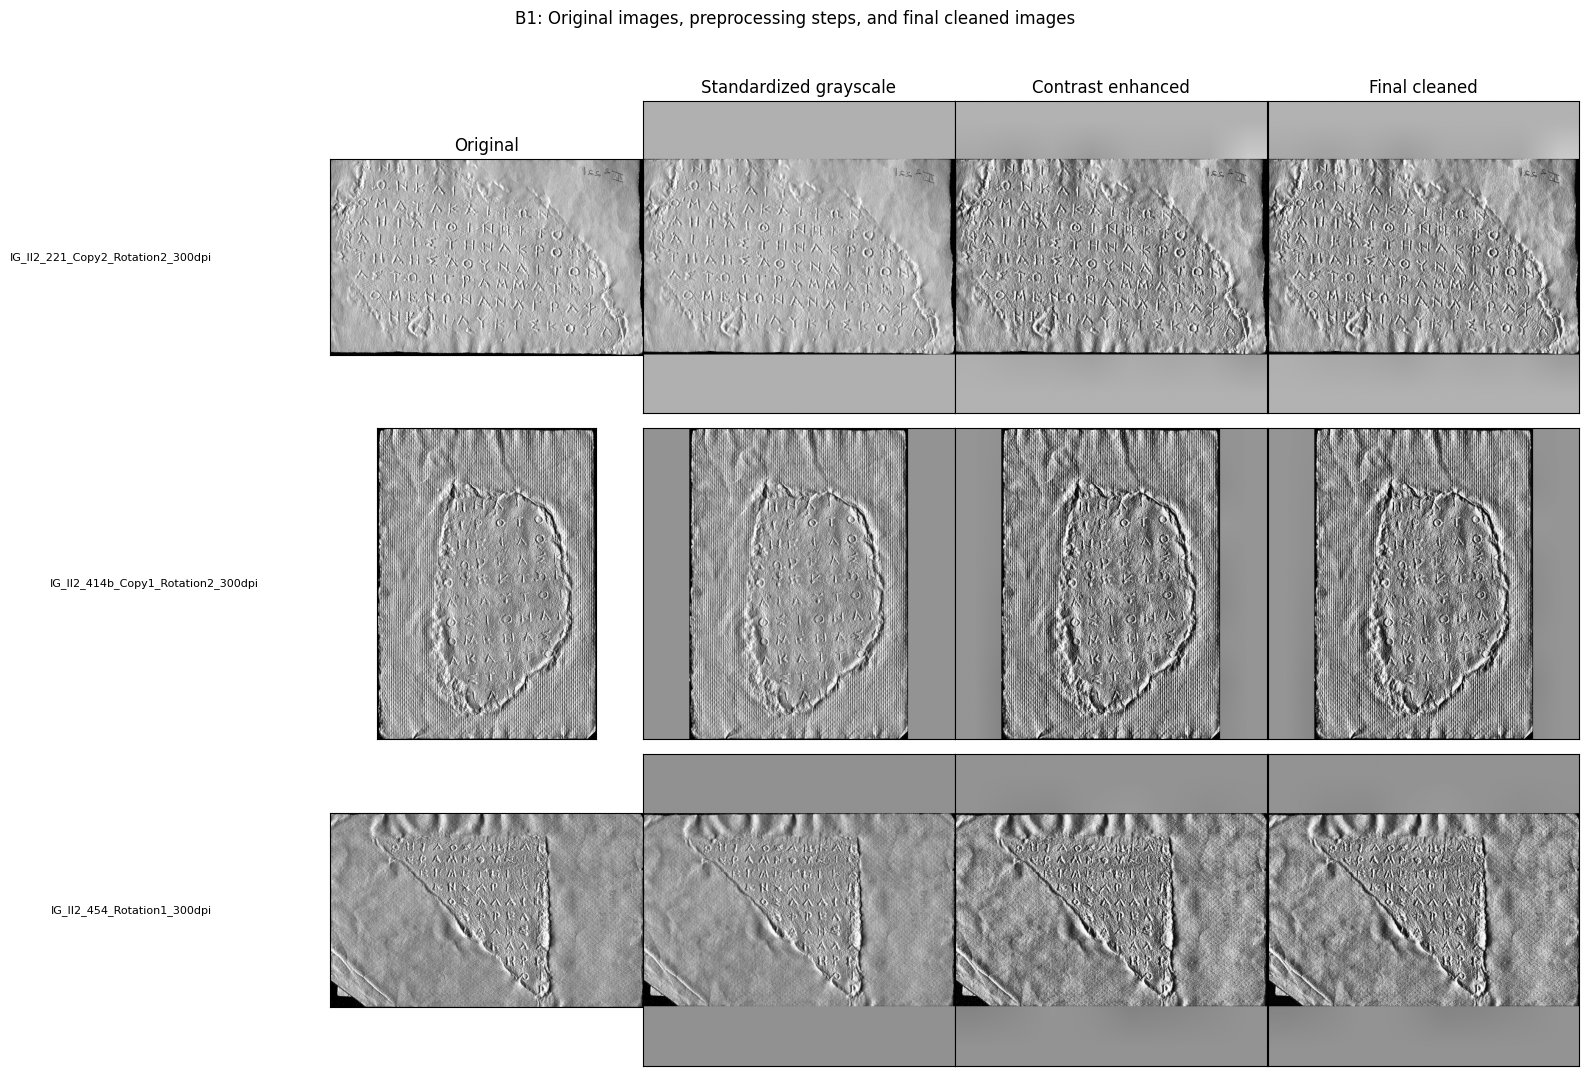

In [ ]:
# B1.3 Show preprocessing steps on the selected sample images

def b1_show_preprocessing_steps(sample_df):
    """Visualize the preprocessing steps for the selected sample images."""
    step_names = [
        "Original",
        "Standardized grayscale",
        "Contrast enhanced",
        "Final cleaned"
    ]

    fig, axes = plt.subplots(
        nrows=len(sample_df),
        ncols=len(step_names),
        figsize=(4 * len(step_names), 3.5 * len(sample_df))
    )

    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    sample_steps = {}

    for row_idx, row in sample_df.iterrows():
        steps = b1_preprocess_image(row["image_path"])
        sample_steps[row["inscription_id"]] = steps

        for col_idx, step_name in enumerate(step_names):
            ax = axes[row_idx, col_idx]
            image = steps[step_name]

            if step_name == "Original":
                ax.imshow(image)
            else:
                ax.imshow(image, cmap="gray", vmin=0, vmax=255)

            if row_idx == 0:
                ax.set_title(step_name)

            if col_idx == 0:
                ax.set_ylabel(
                    row["inscription_id"],
                    rotation=0,
                    ha="right",
                    va="center",
                    labelpad=85,
                    fontsize=8
                )

            ax.set_xticks([])
            ax.set_yticks([])

    plt.suptitle("B1: Original images, preprocessing steps, and final cleaned images", y=1.02)
    plt.tight_layout()
    plt.show()

    return sample_steps


b1_sample_steps = b1_show_preprocessing_steps(b1_sample_df)

#### B1.4 Preprocessing all matched images

After visually checking the preprocessing on sample images, the same pipeline is applied to all matched images in the dataset.  
The result is a single NumPy array named `b1_cleaned_images`, containing one cleaned 512 × 512 grayscale image for each matched inscription.

This array is the main output of B1 and will be reused in the next parts of the assignment.  
Keeping all images in the same shape is important because clustering and machine learning methods require a consistent numerical representation for every sample.

In [ ]:
b1_cleaned_images = []
b1_preprocessed_records = []

for idx, row in tqdm(
    b1_images_df.reset_index(drop=True).iterrows(),
    total=len(b1_images_df),
    desc="Preprocessing images"
):
    steps = b1_preprocess_image(row["image_path"])

    cleaned = steps["Final cleaned"]

    b1_cleaned_images.append(cleaned)

    b1_preprocessed_records.append({
        "array_index": idx,
        "inscription_id": row["inscription_id"],
        "filename": row["filename"],
        "image_folder": row["image_folder"],
        "image_path": row["image_path"],
        "original_height": steps["Original"].shape[0],
        "original_width": steps["Original"].shape[1],
        "processed_height": cleaned.shape[0],
        "processed_width": cleaned.shape[1]
    })

b1_cleaned_images = np.stack(b1_cleaned_images).astype(np.uint8)
b1_preprocessed_df = pd.DataFrame(b1_preprocessed_records)

print("Cleaned grayscale image array shape:", b1_cleaned_images.shape)

display(b1_preprocessed_df.head())

Preprocessing images:   0%|          | 0/448 [00:00<?, ?it/s]

Cleaned grayscale image array shape: (448, 512, 512)


,array_index,inscription_id,filename,image_folder,image_path,original_height,original_width,processed_height,processed_width
0,0,Agora_I_4985_Rotation1_300dpi,Agora_I_4985_Rotation1_300dpi.png,Images1,/content/Images1/Agora_I_4985_Rotation1_300dpi...,3420,1752,512,512
1,1,Agora_I_4985_Rotation2_300dpi,Agora_I_4985_Rotation2_300dpi.png,Images1,/content/Images1/Agora_I_4985_Rotation2_300dpi...,3421,1756,512,512
2,2,Agora_I_5477_Rotation1_300dpi,Agora_I_5477_Rotation1_300dpi.png,Images1,/content/Images1/Agora_I_5477_Rotation1_300dpi...,4111,3645,512,512
3,3,Agora_I_5477_Rotation2_300dpi,Agora_I_5477_Rotation2_300dpi.png,Images1,/content/Images1/Agora_I_5477_Rotation2_300dpi...,4071,3637,512,512
4,4,IAS24115_Rotation1_300dpi,IAS24115_Rotation1_300dpi.png,Images1,/content/Images1/IAS24115_Rotation1_300dpi.png,5083,4333,512,512


#### B1.5 Checking the preprocessed dataset

This cell checks that the preprocessing was applied consistently to the full matched dataset.  
It confirms the final image size and summarizes the pixel intensity distribution of the cleaned grayscale images.

These statistics are not OCR accuracy results. They are only used to verify that the preprocessing produced valid numerical image arrays that can be passed to later clustering and text-recognition steps.

In [ ]:
# B1.5 Basic checks for the cleaned image dataset

b1_check_df = pd.DataFrame({
    "inscription_id": b1_preprocessed_df["inscription_id"],
    "mean_intensity": b1_cleaned_images.mean(axis=(1, 2)),
    "std_intensity": b1_cleaned_images.std(axis=(1, 2)),
    "min_intensity": b1_cleaned_images.min(axis=(1, 2)),
    "max_intensity": b1_cleaned_images.max(axis=(1, 2))
})

print("Number of cleaned images:", len(b1_cleaned_images))
print("Image shape:", b1_cleaned_images[0].shape)
print("Unique processed shapes:", b1_preprocessed_df[["processed_height", "processed_width"]].drop_duplicates().values.tolist())

display(b1_check_df.head())
display(b1_check_df.describe())

Number of cleaned images: 448
Image shape: (512, 512)
Unique processed shapes: [[512, 512]]


,inscription_id,mean_intensity,std_intensity,min_intensity,max_intensity
0,Agora_I_4985_Rotation1_300dpi,166.224472,46.997613,1,255
1,Agora_I_4985_Rotation2_300dpi,166.155743,45.140108,0,255
2,Agora_I_5477_Rotation1_300dpi,141.805573,65.039488,0,255
3,Agora_I_5477_Rotation2_300dpi,143.702309,64.180624,0,255
4,IAS24115_Rotation1_300dpi,86.362820,72.916688,0,255


,mean_intensity,std_intensity,min_intensity,max_intensity
count,448.000000,448.000000,448.000000,448.0
mean,135.304526,53.047539,0.245536,255.0
std,10.942528,9.111130,0.436047,0.0
min,78.145351,31.234261,0.000000,255.0
25%,131.677866,46.591671,0.000000,255.0
50%,136.190659,52.773549,0.000000,255.0
75%,140.132261,59.066638,0.000000,255.0
max,175.090424,78.200280,2.000000,255.0


**Β2.** Χρησιμοποιήστε embeddings από ένα οπτικό μοντέλο για να ομαδοποιήσετε τις εικόνες βάσει οπτικής ομοιότητας. *(16 μονάδες)*

**Οδηγίες:**
- Εξαγάγετε embeddings από ένα οπτικό μοντέλο (π.χ. ViT).
- Χρησιμοποιήστε **PCA**, **t-SNE** ή/και **UMAP** για ομαδοποίηση και απεικόνιση.
- Εκτυπώστε εικόνες κοντά στα κεντροειδή κάθε cluster (π.χ. 3 εικόνες ανά κεντροειδές).
- Ονομάστε τα θέματα (topics) 3 clusters — χρησιμοποιήστε τα filenames για να ελέγξετε αν ανήκουν στην ίδια εποχή.
- Χρησιμοποιήστε ένα LLM για να αυτοματοποιήσετε την ονοματοδοσία θεμάτων.
- Αναλύστε: Βρίσκονται ζεύγη εικόνων στο ίδιο cluster; Εικόνες από τον ίδιο τόπο/αρχείο;

In [ ]:
# TODO: Ομαδοποίηση εικόνων μέσω embeddings (ViT), PCA, UMAP, LLM topic naming

### B2 Solution:

**Implementation.**  
For B2, we used the pretrained vision transformer `google/vit-base-patch16-224-in21k` from Hugging Face to extract visual embeddings from the cleaned inscription images. Since the preprocessed images were grayscale, each image was first converted to a PIL image in grayscale mode and then transformed to RGB, because ViT expects 3-channel input. The images were passed through the ViT model in evaluation mode, and the embedding of the `[CLS]` token from the final hidden state was used as the global representation of each image. The resulting embedding matrix was normalized so that clustering depended more on visual direction/similarity than on raw vector magnitude. We then reduced the embeddings with PCA, keeping up to 50 principal components, and used the first two components for PCA visualization. To choose the number of clusters, we tested K-Means with silhouette scores and selected the value with the highest silhouette score, which was `k = 4`. Final clustering was performed with K-Means on the PCA-reduced embeddings. For visualization, we plotted the clusters both in PCA space and in UMAP space using cosine distance. We also computed each image’s distance from its assigned K-Means centroid and displayed the three closest images per cluster as representative examples. Finally, filename structure was analyzed by extracting broad corpus/archive prefixes such as `IG_II2`, `IAS`, and `Agora`, and by grouping rotated versions of the same inscription using the part of the filename before the `_Rotation` suffix. These metadata summaries were then passed to an LLM prompt to automatically generate cautious topic names for the clusters.

**Findings.**  
Using embeddings extracted from a visual model, we clustered the inscription images according to visual similarity. The silhouette score is relatively low, so the clusters should be interpreted as meaningful visual tendencies rather than perfectly separated categories. PCA showed some overlap between clusters, while UMAP produced a clearer separation of the image groups. The centroid images indicate that the clusters capture differences in stone shape, inscription density, orientation, and surface texture. Cluster 0 mainly contains compact IG II² inscription slabs with clearer text bands, Cluster 1 contains wide horizontal IG II² fragments with faint inscriptions, Cluster 2 is enriched with IAS images and includes larger slab or panel-like fragments, and Cluster 3 contains large irregular broken inscription surfaces, again mostly IG II² but with some IAS and Agora examples. Filename-prefix analysis confirms that most clusters are dominated by `IG_II2`, showing that images from the same archive/corpus often share visual characteristics, while `IAS` and `Agora` images appear as smaller mixed groups. The rotation-pair analysis showed that 122 out of 224 repeated rotation groups were fully assigned to the same cluster, corresponding to 54.46%, which means the embeddings are moderately but not perfectly robust to rotated versions of the same inscription. Overall, the method finds coherent visual groups and reveals a strong relationship between visual similarity and archive/source, although it does not produce a completely clean separation by source or historical period.

#### B2.1 Extracting ViT image embeddings

This cell uses a pretrained Vision Transformer model to convert each cleaned inscription image into a numerical embedding.  
The cleaned images are grayscale, but the ViT model expects RGB input, so each image is converted into a 3-channel RGB image before being passed to the model.

For each image, the CLS token embedding is extracted. This gives one 768-dimensional vector that summarizes the visual content of the image.  
These embeddings are then normalized so that clustering depends more on visual similarity than on raw vector magnitude.  
The final embedding matrix has shape `(190, 768)`, meaning that all 190 images now have a compact visual representation.

In [ ]:
from transformers import AutoImageProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"

B2_MODEL_NAME = "google/vit-base-patch16-224-in21k"
B2_BATCH_SIZE = 16

processor = AutoImageProcessor.from_pretrained(B2_MODEL_NAME)
vit_model = AutoModel.from_pretrained(B2_MODEL_NAME).to(device)
vit_model.eval()


def image_array_to_pil_rgb(image_array):
    """
    Convert a cleaned grayscale image array to RGB PIL format.
    ViT expects 3-channel images, so the grayscale image is repeated as RGB.
    """
    image = Image.fromarray(image_array.astype(np.uint8), mode="L")
    return image.convert("RGB")


b2_embeddings_list = []

for start_idx in tqdm(
    range(0, len(b1_cleaned_images), B2_BATCH_SIZE),
    desc="Extracting ViT embeddings"
):
    batch_arrays = b1_cleaned_images[start_idx:start_idx + B2_BATCH_SIZE]
    batch_images = [image_array_to_pil_rgb(img) for img in batch_arrays]

    inputs = processor(
        images=batch_images,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = vit_model(**inputs)

    # CLS token embedding represents the whole image.
    batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    b2_embeddings_list.append(batch_embeddings)

b2_embeddings = np.vstack(b2_embeddings_list)

# Normalize embeddings so clustering is based more on direction/similarity than raw magnitude.
b2_embeddings = normalize(b2_embeddings)

b2_embeddings_df = b1_preprocessed_df.copy()
b2_embeddings_df["embedding_index"] = np.arange(len(b2_embeddings_df))

print("Embedding matrix shape:", b2_embeddings.shape)
display(b2_embeddings_df.head())

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Extracting ViT embeddings:   0%|          | 0/28 [00:00<?, ?it/s]

/tmp/ipykernel_1223/2080152635.py:18: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image_array.astype(np.uint8), mode="L")


Embedding matrix shape: (448, 768)


,array_index,inscription_id,filename,image_folder,image_path,original_height,original_width,processed_height,processed_width,embedding_index
0,0,Agora_I_4985_Rotation1_300dpi,Agora_I_4985_Rotation1_300dpi.png,Images1,/content/Images1/Agora_I_4985_Rotation1_300dpi.png,3420,1752,512,512,0
1,1,Agora_I_4985_Rotation2_300dpi,Agora_I_4985_Rotation2_300dpi.png,Images1,/content/Images1/Agora_I_4985_Rotation2_300dpi.png,3421,1756,512,512,1
2,2,Agora_I_5477_Rotation1_300dpi,Agora_I_5477_Rotation1_300dpi.png,Images1,/content/Images1/Agora_I_5477_Rotation1_300dpi.png,4111,3645,512,512,2
3,3,Agora_I_5477_Rotation2_300dpi,Agora_I_5477_Rotation2_300dpi.png,Images1,/content/Images1/Agora_I_5477_Rotation2_300dpi.png,4071,3637,512,512,3
4,4,IAS24115_Rotation1_300dpi,IAS24115_Rotation1_300dpi.png,Images1,/content/Images1/IAS24115_Rotation1_300dpi.png,5083,4333,512,512,4


#### B2.2 PCA reduction for clustering

The ViT embeddings extracted in the previous step have 768 dimensions, which is too high for direct visualization and may contain redundant information.  
To make the embeddings easier to cluster and visualize, PCA is applied as a dimensionality-reduction step.

The main PCA representation reduces each image from 768 dimensions to 50 dimensions.  
This keeps most of the information from the original visual embeddings while making the data more compact for clustering.  
A separate 2D PCA projection is also created for plotting the images in a simple two-dimensional space.

In this dataset, the 50-dimensional PCA representation keeps around 84% of the variance, which is a reasonable amount of retained information for clustering.

In [ ]:
# B2.2 PCA dimensionality reduction

B2_PCA_COMPONENTS = min(50, b2_embeddings.shape[0] - 1, b2_embeddings.shape[1])

pca = PCA(n_components=B2_PCA_COMPONENTS, random_state=42)
b2_embeddings_pca = pca.fit_transform(b2_embeddings)

# Use the first two PCA components for plotting
b2_pca_2d = b2_embeddings_pca[:, :2]

print("Original embedding shape:", b2_embeddings.shape)
print("PCA embedding shape:", b2_embeddings_pca.shape)
print("Explained variance kept by PCA:", round(pca.explained_variance_ratio_.sum(), 4))
print("Explained variance in PCA-2D plot:", round(pca.explained_variance_ratio_[:2].sum(), 4))

b2_embeddings_df["pca_x"] = b2_pca_2d[:, 0]
b2_embeddings_df["pca_y"] = b2_pca_2d[:, 1]

display(b2_embeddings_df[["inscription_id", "image_folder", "pca_x", "pca_y"]].head())

Original embedding shape: (448, 768)
PCA embedding shape: (448, 50)
Explained variance kept by PCA: 0.7977
Explained variance in PCA-2D plot: 0.236


,inscription_id,image_folder,pca_x,pca_y
0,Agora_I_4985_Rotation1_300dpi,Images1,0.074908,0.096042
1,Agora_I_4985_Rotation2_300dpi,Images1,0.246190,0.010872
2,Agora_I_5477_Rotation1_300dpi,Images1,-0.134481,-0.266608
3,Agora_I_5477_Rotation2_300dpi,Images1,0.438717,-0.046070
4,IAS24115_Rotation1_300dpi,Images1,0.159174,0.149729


#### B2.3 Choosing the number of clusters

This cell tests different possible numbers of clusters using K-Means and the silhouette score.  

The silhouette scores are relatively low, which suggests that the image embeddings form gradual visual similarities rather than very clear separated groups.  
However, the best score among the tested values is obtained for 4 clusters.  
This is also convenient for the assignment because we later need to inspect and name 3 clusters.

In [ ]:
# B2.4 Choose number of clusters using silhouette score

candidate_k_values = range(3, 11)
b2_k_results = []

for k in candidate_k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(b2_embeddings_pca)

    score = silhouette_score(b2_embeddings_pca, labels)

    b2_k_results.append({
        "k": k,
        "silhouette_score": score
    })

b2_k_results_df = pd.DataFrame(b2_k_results)

display(b2_k_results_df)

B2_N_CLUSTERS = int(
    b2_k_results_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
)

print("Selected number of clusters:", B2_N_CLUSTERS)

,k,silhouette_score
0,3,0.096850
1,4,0.108297
2,5,0.094304
3,6,0.087083
4,7,0.078994
5,8,0.085069
6,9,0.086110
7,10,0.082980


Selected number of clusters: 4


#### B2.4 K-Means clustering and PCA visualization

This cell applies K-Means clustering using the selected number of clusters.  
The clustering is performed on the 50-dimensional PCA embeddings, not directly on the 2D PCA plot, because the 50-dimensional representation keeps more information from the original ViT embeddings.

The cluster labels are added to the metadata table, allowing each image to be linked to its filename, archive folder, and assigned cluster.  
The cluster counts show that the images are divided into three groups of different sizes, which suggests that some visual patterns are more common than others in the dataset.

,cluster,image_count
0,0,142
1,1,122
2,2,67
3,3,117


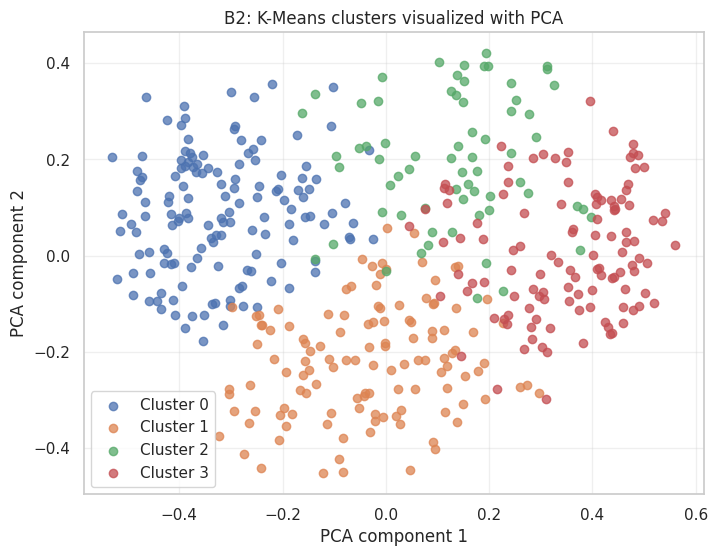

In [ ]:
# B2.4 Final K-Means clustering and PCA visualization

b2_kmeans = KMeans(
    n_clusters=B2_N_CLUSTERS,
    random_state=42,
    n_init=20
)

b2_cluster_labels = b2_kmeans.fit_predict(b2_embeddings_pca)

b2_embeddings_df["cluster"] = b2_cluster_labels
b2_embeddings_df["cluster_name"] = b2_embeddings_df["cluster"].apply(lambda x: f"Cluster {x}")

cluster_counts = (
    b2_embeddings_df["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ["cluster", "image_count"]

display(cluster_counts)

plt.figure(figsize=(8, 6))

for cluster_id in sorted(b2_embeddings_df["cluster"].unique()):
    cluster_data = b2_embeddings_df[b2_embeddings_df["cluster"] == cluster_id]

    plt.scatter(
        cluster_data["pca_x"],
        cluster_data["pca_y"],
        label=f"Cluster {cluster_id}",
        alpha=0.75
    )

plt.title("B2: K-Means clusters visualized with PCA")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### B2.5 UMAP visualization of the image embeddings

This cell creates a UMAP visualization of the image embeddings.  
UMAP is useful because it tries to preserve local neighborhoods, so images that appear close together in the plot should have similar visual embeddings.

The same K-Means cluster labels are used as colours in the UMAP space.  
The resulting plot shows that the clusters have a visible structure, although some overlap is expected because ancient inscription images can share similar texture, lighting, and layout features.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


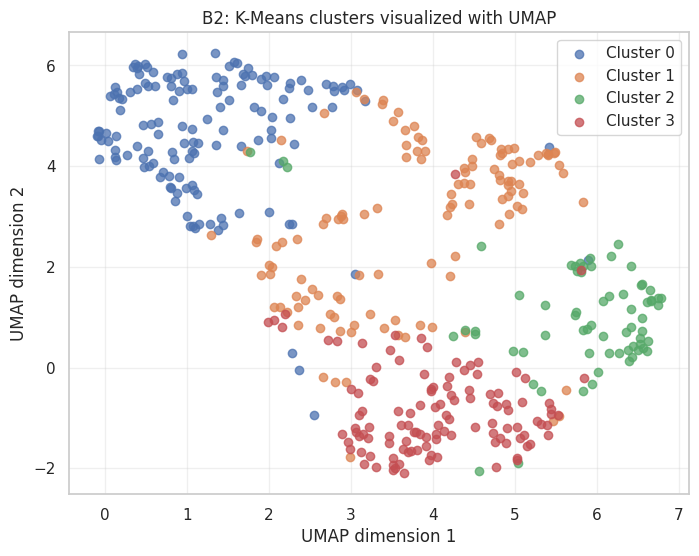

,inscription_id,image_folder,cluster,pca_x,pca_y,umap_x,umap_y
0,Agora_I_4985_Rotation1_300dpi,Images1,3,0.074908,0.096042,3.235173,-0.228388
1,Agora_I_4985_Rotation2_300dpi,Images1,3,0.246190,0.010872,3.590794,0.142119
2,Agora_I_5477_Rotation1_300dpi,Images1,1,-0.134481,-0.266608,3.814236,4.570902
3,Agora_I_5477_Rotation2_300dpi,Images1,3,0.438717,-0.046070,3.508853,-1.787861
4,IAS24115_Rotation1_300dpi,Images1,2,0.159174,0.149729,6.550691,0.983797


In [ ]:
def import_umap_safely():
    """
    Try to import UMAP. If the import fails because of a dependency issue,
    upgrade the relevant packages without changing NumPy, then try again.
    """
    try:
        import umap.umap_ as umap
        return umap

    except ImportError as first_error:
        print("Initial UMAP import failed:")
        print(first_error)

umap = import_umap_safely()

b2_umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

b2_umap_2d = b2_umap_model.fit_transform(b2_embeddings_pca)

b2_embeddings_df["umap_x"] = b2_umap_2d[:, 0]
b2_embeddings_df["umap_y"] = b2_umap_2d[:, 1]

plt.figure(figsize=(8, 6))

for cluster_id in sorted(b2_embeddings_df["cluster"].unique()):
    cluster_data = b2_embeddings_df[b2_embeddings_df["cluster"] == cluster_id]

    plt.scatter(
        cluster_data["umap_x"],
        cluster_data["umap_y"],
        label=f"Cluster {cluster_id}",
        alpha=0.75
    )

plt.title("B2: K-Means clusters visualized with UMAP")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

display(
    b2_embeddings_df[
        ["inscription_id", "image_folder", "cluster", "pca_x", "pca_y", "umap_x", "umap_y"]
    ].head()
)

#### B2.6 Images closest to each cluster centroid

This cell finds representative images for each K-Means cluster.  
For every image, the distance to its assigned cluster centroid is calculated in the PCA embedding space.  
The three images with the smallest distance to each centroid are then selected and displayed.

These examples help us understand what each cluster visually represents.  
Instead of interpreting the clusters only from scatter plots, we inspect actual images near the cluster centers.  
This is important because the cluster labels are numerical and do not have meaning until we examine the images and filenames.

,cluster,rank_near_centroid,inscription_id,filename,image_folder,distance_to_centroid
0,0,1,IG_II2_2029_Rotation1_300dpi,IG_II2_2029_Rotation1_300dpi.png,Images4,0.378216
1,0,2,IG_II2_2022b_Rotation2_300dpi,IG_II2_2022b_Rotation2_300dpi.png,Images4,0.386563
2,0,3,IG_II2_1719_Copy1_Rotation2_300dpi,IG_II2_1719_Copy1_Rotation2_300dpi.png,Images3,0.387408
3,1,1,IG_II2_233b_Rotation2_300dpi,IG_II2_233b_Rotation2_300dpi.png,Images2,0.371180
4,1,2,IG_II2_580_Copy1_Rotation1_300dpi,IG_II2_580_Copy1_Rotation1_300dpi.png,Images3,0.375829
5,1,3,IG_II2_333a+b_Rotation1_300dpi,IG_II2_333a+b_Rotation1_300dpi.png,Images2,0.377512
6,2,1,IG_II2_76a_Rotation2_300dpi,IG_II2_76a_Rotation2_300dpi.png,Images1,0.556672
7,2,2,IG_II2_498b_Copy1_Rotation1_300dpi,IG_II2_498b_Copy1_Rotation1_300dpi.png,Images3,0.585570
8,2,3,IG_II2_354b_Rotation1_300dpi,IG_II2_354b_Rotation1_300dpi.png,Images2,0.587835
9,3,1,IG_II2_1934a_Rotation2_300dpi,IG_II2_1934a_Rotation2_300dpi.png,Images3,0.392500


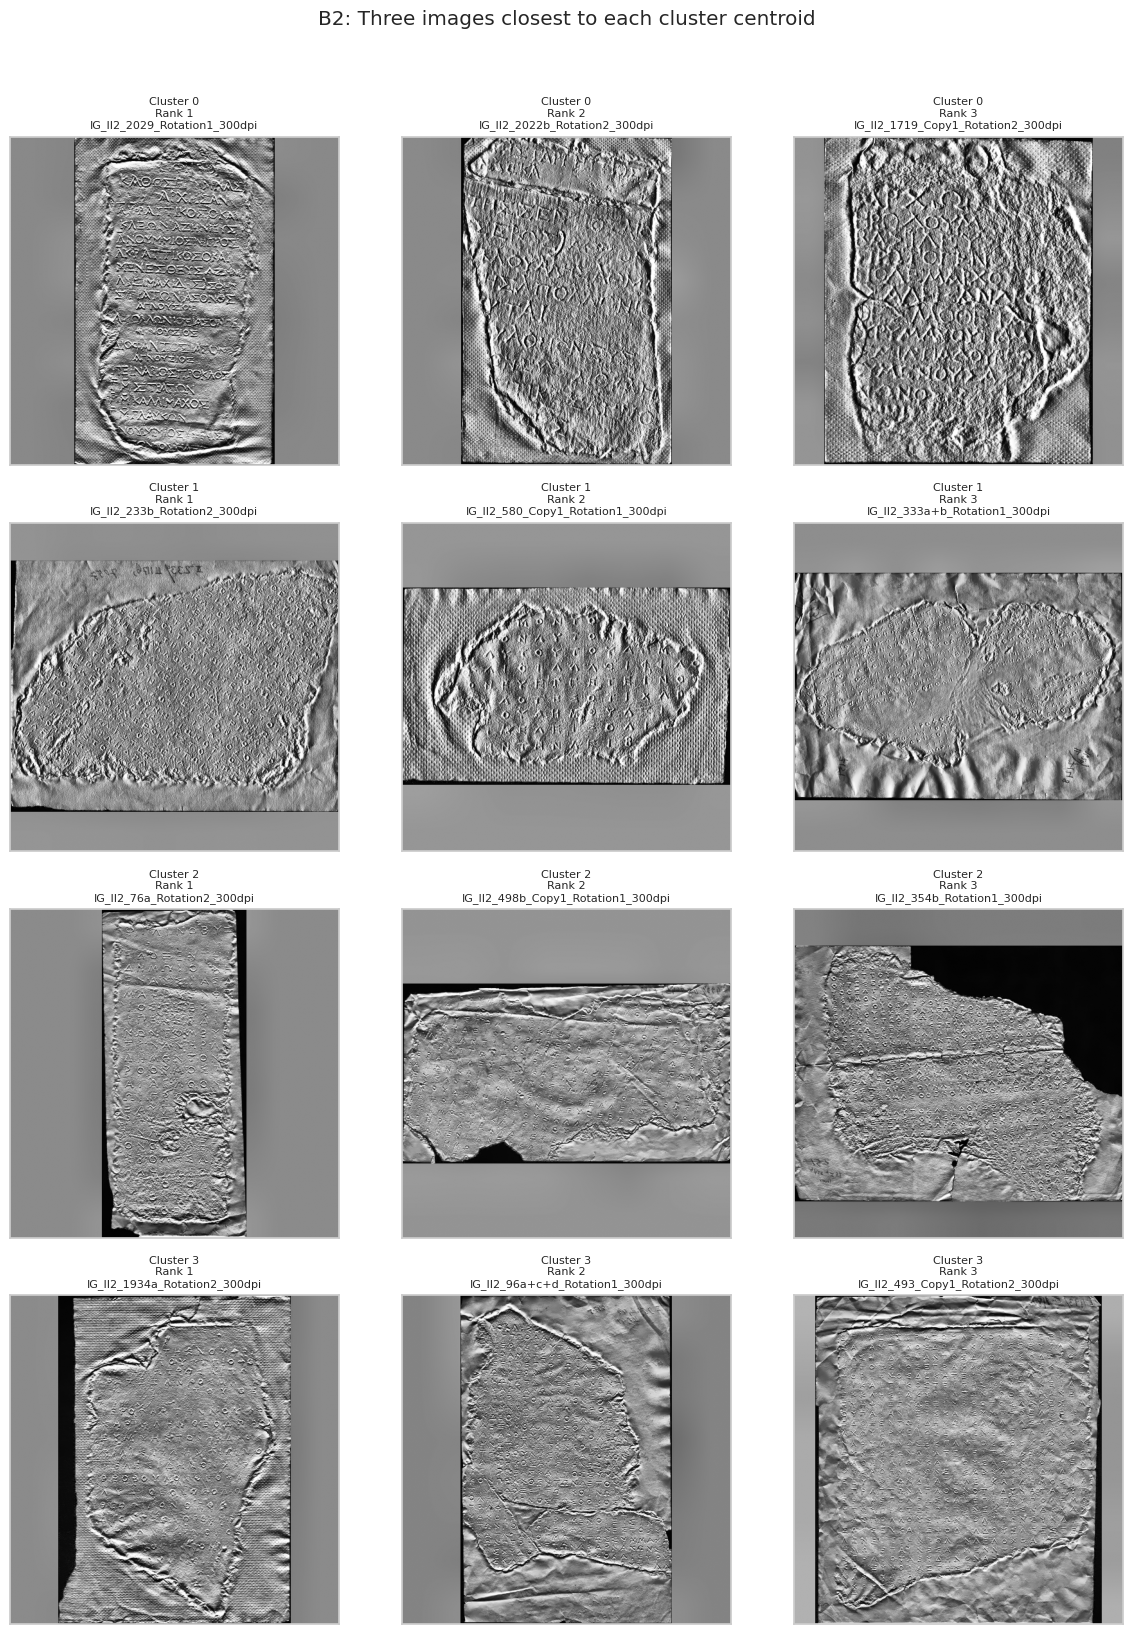

In [ ]:
# Distance from each image to its assigned cluster centroid in PCA embedding space
centroid_distances = pairwise_distances(
    b2_embeddings_pca,
    b2_kmeans.cluster_centers_
)

b2_embeddings_df["distance_to_centroid"] = [
    centroid_distances[i, cluster]
    for i, cluster in enumerate(b2_embeddings_df["cluster"])
]

b2_centroid_examples = []

for cluster_id in sorted(b2_embeddings_df["cluster"].unique()):
    cluster_examples = (
        b2_embeddings_df[b2_embeddings_df["cluster"] == cluster_id]
        .sort_values("distance_to_centroid")
        .head(3)
        .copy()
    )

    cluster_examples["rank_near_centroid"] = range(1, len(cluster_examples) + 1)
    b2_centroid_examples.append(cluster_examples)

b2_centroid_examples_df = pd.concat(b2_centroid_examples, ignore_index=True)

display(
    b2_centroid_examples_df[
        [
            "cluster",
            "rank_near_centroid",
            "inscription_id",
            "filename",
            "image_folder",
            "distance_to_centroid"
        ]
    ]
)

# Plot the representative images
n_clusters = b2_centroid_examples_df["cluster"].nunique()
examples_per_cluster = 3

fig, axes = plt.subplots(
    nrows=n_clusters,
    ncols=examples_per_cluster,
    figsize=(4 * examples_per_cluster, 4 * n_clusters)
)

if n_clusters == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, cluster_id in enumerate(sorted(b2_centroid_examples_df["cluster"].unique())):
    cluster_rows = b2_centroid_examples_df[
        b2_centroid_examples_df["cluster"] == cluster_id
    ].reset_index(drop=True)

    for col_idx in range(examples_per_cluster):
        ax = axes[row_idx, col_idx]

        if col_idx < len(cluster_rows):
            row = cluster_rows.iloc[col_idx]
            image_index = int(row["array_index"])

            ax.imshow(b1_cleaned_images[image_index], cmap="gray", vmin=0, vmax=255)
            ax.set_title(
                f"Cluster {cluster_id}\nRank {row['rank_near_centroid']}\n{row['inscription_id']}",
                fontsize=8
            )
        else:
            ax.axis("off")

        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("B2: Three images closest to each cluster centroid", y=1.02)
plt.tight_layout()
plt.show()

#### B2.8 Cluster composition and repeated-image analysis

This cell analyzes the clusters using information from the filenames and image folders.  
The goal is to check whether the visual clusters correspond to meaningful metadata patterns, such as archive, collection, or repeated versions of the same inscription.

The cluster composition tables show how many images from each folder and filename prefix appear in each cluster.  
This helps us see whether the embeddings are grouping images only by visual similarity, or whether they also reflect dataset structure such as `IG_II2`, `IAS`, and `Agora` sources.

The repeated-inscription analysis groups together different rotations, copies, or merged versions of the same base inscription.  
In this run, 62.11% of repeated inscription groups appear fully inside one cluster.  
This suggests that the embeddings capture some stable inscription-level similarity, although rotations and image variations can still move related images into different clusters.

In [ ]:
# B2. Inspect filename patterns before extracting prefixes

filename_inspection_df = b2_embeddings_df[[
    "inscription_id",
    "filename",
    "image_folder",
    "cluster"
]].copy()

display(filename_inspection_df.head(20))

print("Random filename examples:")
display(
    filename_inspection_df
    .sample(min(30, len(filename_inspection_df)), random_state=42)
    .sort_values("inscription_id")
)

,inscription_id,filename,image_folder,cluster
0,Agora_I_4985_Rotation1_300dpi,Agora_I_4985_Rotation1_300dpi.png,Images1,3
1,Agora_I_4985_Rotation2_300dpi,Agora_I_4985_Rotation2_300dpi.png,Images1,3
2,Agora_I_5477_Rotation1_300dpi,Agora_I_5477_Rotation1_300dpi.png,Images1,1
3,Agora_I_5477_Rotation2_300dpi,Agora_I_5477_Rotation2_300dpi.png,Images1,3
4,IAS24115_Rotation1_300dpi,IAS24115_Rotation1_300dpi.png,Images1,2
5,IAS24115_Rotation2_300dpi,IAS24115_Rotation2_300dpi.png,Images1,2
6,IAS33117_Merged_Rotation1_300dpi,IAS33117_Merged_Rotation1_300dpi.png,Images1,2
7,IAS33117_Merged_Rotation2_300dpi,IAS33117_Merged_Rotation2_300dpi.png,Images1,2
8,IAS33118_Merged_Rotation1_300dpi,IAS33118_Merged_Rotation1_300dpi.png,Images1,2
9,IAS33118_Merged_Rotation2_300dpi,IAS33118_Merged_Rotation2_300dpi.png,Images1,3


Random filename examples:


,inscription_id,filename,image_folder,cluster
9,IAS33118_Merged_Rotation2_300dpi,IAS33118_Merged_Rotation2_300dpi.png,Images1,3
30,IAS_27262_Rotation1_300dpi,IAS_27262_Rotation1_300dpi.png,Images1,2
39,IAS_27276_Rotation2_300dpi,IAS_27276_Rotation2_300dpi.png,Images1,0
75,IG_II2_105_Merged_Rotation2_300dpi,IG_II2_105_Merged_Rotation2_300dpi.png,Images2,2
77,IG_II2_109b_Rotation2_300dpi,IG_II2_109b_Rotation2_300dpi.png,Images2,3
79,IG_II2_111_Merged_Rotation2_300dpi,IG_II2_111_Merged_Rotation2_300dpi.png,Images2,3
82,IG_II2_134_Rotation1_300dpi,IG_II2_134_Rotation1_300dpi.png,Images2,0
192,IG_II2_1685B5_Rotation1_300dpi,IG_II2_1685B5_Rotation1_300dpi.png,Images3,0
211,IG_II2_1705_Rotation2_300dpi,IG_II2_1705_Rotation2_300dpi.png,Images3,1
90,IG_II2_177_Rotation1_300dpi,IG_II2_177_Rotation1_300dpi.png,Images2,0


In [ ]:
# B2. Cluster interpretation using filename structure

def b2_id_before_rotation(inscription_id):
    """
    Group repeated rotated versions of the same item by keeping everything
    before the _Rotation... suffix.

    Examples:
    IAS24115_Rotation1_300dpi -> IAS24115
    IAS33117_Merged_Rotation2_300dpi -> IAS33117_Merged
    IG_II2_221_Copy2_Rotation1_300dpi -> IG_II2_221_Copy2

    We intentionally do NOT remove Copy or Merged markers, because they may
    describe meaningful different versions/copies of an inscription.
    """
    return re.sub(r"_Rotation_?\d+.*$", "", inscription_id)


def b2_filename_prefix(inscription_id):
    """
    Extract a broad archive/corpus prefix from the observed filename structure.

    Examples:
    Agora_I_4985_Rotation1_300dpi -> Agora
    IAS24115_Rotation1_300dpi -> IAS
    IAS_27262_Rotation1_300dpi -> IAS
    IG_II2_179b_Copy2_Rotation2_300dpi -> IG_II2
    """
    base = b2_id_before_rotation(inscription_id)
    parts = base.split("_")

    # Keep IG_II2 together. Returning only "IG" would be too broad.
    if len(parts) >= 2 and parts[0] == "IG":
        return f"{parts[0]}_{parts[1]}"

    # Handles Agora_I_..., IAS24115_..., IAS_27262_..., etc.
    match = re.match(r"^[A-Za-z]+", base)
    if match:
        return match.group(0)

    return parts[0]


# Add filename-based metadata for cluster interpretation.
b2_embeddings_df["base_inscription_id"] = (
    b2_embeddings_df["inscription_id"]
    .apply(b2_id_before_rotation)
)

b2_embeddings_df["filename_prefix"] = (
    b2_embeddings_df["inscription_id"]
    .apply(b2_filename_prefix)
)


print("Cluster counts:")
display(
    b2_embeddings_df["cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="image_count")
)


print("\nCluster composition by image folder:")
display(
    pd.crosstab(
        b2_embeddings_df["cluster"],
        b2_embeddings_df["image_folder"],
        margins=True
    )
)


print("\nCluster composition by filename prefix:")
display(
    pd.crosstab(
        b2_embeddings_df["cluster"],
        b2_embeddings_df["filename_prefix"],
        margins=True
    )
)


# Analyze whether rotated versions of the same item are placed in the same cluster.
b2_group_cluster_summary = (
    b2_embeddings_df
    .groupby("base_inscription_id")
    .agg(
        n_images=("inscription_id", "count"),
        n_clusters=("cluster", "nunique"),
        clusters=("cluster", lambda x: sorted(x.unique())),
        filenames=("filename", lambda x: list(x))
    )
    .reset_index()
)

b2_repeated_groups_df = b2_group_cluster_summary[
    b2_group_cluster_summary["n_images"] > 1
].copy()

same_cluster_groups = (b2_repeated_groups_df["n_clusters"] == 1).sum()
total_repeated_groups = len(b2_repeated_groups_df)

print("\nRepeated rotation groups:")
print("Total repeated rotation groups:", total_repeated_groups)
print("Repeated rotation groups fully in one cluster:", same_cluster_groups)

if total_repeated_groups > 0:
    print(
        "Percentage fully in one cluster:",
        round(100 * same_cluster_groups / total_repeated_groups, 2),
        "%"
    )

display(b2_repeated_groups_df.head(10))

Cluster counts:


,cluster,image_count
0,0,142
1,1,122
2,2,67
3,3,117



Cluster composition by image folder:


image_folder,Images1,Images2,Images3,Images4,All
cluster,,,,,
0,23,24,43,52,142
1,8,32,58,24,122
2,27,14,13,13,67
3,16,32,42,27,117
All,74,102,156,116,448



Cluster composition by filename prefix:


filename_prefix,Agora,IAS,IG_II2,All
cluster,,,,
0,0,12,130,142
1,1,2,119,122
2,0,25,42,67
3,3,9,105,117
All,4,48,396,448



Repeated rotation groups:
Total repeated rotation groups: 224
Repeated rotation groups fully in one cluster: 122
Percentage fully in one cluster: 54.46 %


,base_inscription_id,n_images,n_clusters,clusters,filenames
0,Agora_I_4985,2,1,[3],"[Agora_I_4985_Rotation1_300dpi.png, Agora_I_4985_Rotation2_300dpi.png]"
1,Agora_I_5477,2,2,"[1, 3]","[Agora_I_5477_Rotation1_300dpi.png, Agora_I_5477_Rotation2_300dpi.png]"
2,IAS24115,2,1,[2],"[IAS24115_Rotation1_300dpi.png, IAS24115_Rotation2_300dpi.png]"
3,IAS33117_Merged,2,1,[2],"[IAS33117_Merged_Rotation1_300dpi.png, IAS33117_Merged_Rotation2_300dpi.png]"
4,IAS33118_Merged,2,2,"[2, 3]","[IAS33118_Merged_Rotation1_300dpi.png, IAS33118_Merged_Rotation2_300dpi.png]"
5,IAS33126_Merged,2,1,[2],"[IAS33126_Merged_Rotation1_300dpi.png, IAS33126_Merged_Rotation2_300dpi.png]"
6,IAS33147,2,1,[2],"[IAS33147_Rotation1_300dpi.png, IAS33147_Rotation2_300dpi.png]"
7,IAS33148,2,1,[2],"[IAS33148_Rotation1_300dpi.png, IAS33148_Rotation2_300dpi.png]"
8,IAS33161,2,1,[2],"[IAS33161_Rotation1_300dpi.png, IAS33161_Rotation2_300dpi.png]"
9,IAS33162,2,2,"[2, 3]","[IAS33162_Rotation1_300dpi.png, IAS33162_Rotation2_300dpi.png]"


#### B2.8 Preparing cluster summaries for topic naming

This cell prepares compact summaries for each cluster before assigning topic names.  
For each cluster, it reports the number of images, the dominant filename prefixes, the dominant image folders, and the images closest to the cluster centroid.

These summaries are useful because cluster numbers such as 0, 1, and 2 do not have meaning by themselves.  
By looking at the filenames and representative images, we can describe what each cluster seems to contain.

The summaries will also be used as structured input for an LLM, so that topic naming is based on evidence from the dataset rather than only manual guessing.

In [ ]:
# B2. Cluster summaries for topic naming with an LLM

def b2_format_counts(series, top_n=5):
    """Format value counts as a compact string."""
    counts = series.value_counts().head(top_n)
    return ", ".join([f"{idx}: {count}" for idx, count in counts.items()])


b2_cluster_summary_rows = []

for cluster_id in sorted(b2_embeddings_df["cluster"].unique()):
    cluster_df = b2_embeddings_df[
        b2_embeddings_df["cluster"] == cluster_id
    ].copy()

    centroid_examples = (
        b2_centroid_examples_df[
            b2_centroid_examples_df["cluster"] == cluster_id
        ]
        .sort_values("rank_near_centroid")
    )

    centroid_filenames = centroid_examples["filename"].tolist()

    # IDs before _Rotation, used to check whether rotated versions
    # of the same item are grouped together.
    common_rotation_group_ids = (
        cluster_df["base_inscription_id"]
        .value_counts()
        .head(5)
        .index
        .tolist()
    )

    b2_cluster_summary_rows.append({
        "cluster": cluster_id,
        "image_count": len(cluster_df),
        "dominant_filename_prefixes": b2_format_counts(cluster_df["filename_prefix"]),
        "dominant_image_folders": b2_format_counts(cluster_df["image_folder"]),
        "centroid_examples": "; ".join(centroid_filenames),
        "common_rotation_group_ids": ", ".join(common_rotation_group_ids)
    })


b2_cluster_summaries_df = pd.DataFrame(b2_cluster_summary_rows)

display(b2_cluster_summaries_df)


print("Text summaries for LLM topic naming:\n")

for _, row in b2_cluster_summaries_df.iterrows():
    print(f"Cluster {row['cluster']}")
    print(f"- Number of images: {row['image_count']}")
    print(f"- Dominant filename prefixes: {row['dominant_filename_prefixes']}")
    print(f"- Dominant image folders: {row['dominant_image_folders']}")
    print(f"- Images closest to centroid: {row['centroid_examples']}")
    print(f"- Common IDs before rotation: {row['common_rotation_group_ids']}")
    print()

,cluster,image_count,dominant_filename_prefixes,dominant_image_folders,centroid_examples,common_rotation_group_ids
0,0,142,"IG_II2: 130, IAS: 12","Images4: 52, Images3: 43, Images2: 24, Images1: 23",IG_II2_2029_Rotation1_300dpi.png; IG_II2_2022b_Rotation2_300dpi.png; IG_II2_1719_Copy1_Rotation2_300dpi.png,"IAS_27276, IG_II2_5_Copy2, IG_II2_24c_Copy2, IG_II2_17a, IAS_27307"
1,1,122,"IG_II2: 119, IAS: 2, Agora: 1","Images3: 58, Images2: 32, Images4: 24, Images1: 8",IG_II2_233b_Rotation2_300dpi.png; IG_II2_580_Copy1_Rotation1_300dpi.png; IG_II2_333a+b_Rotation1_300dpi.png,"IG_II2_80, IG_II2_112b, IG_II2_191, IG_II2_233b, IG_II2_286"
2,2,67,"IG_II2: 42, IAS: 25","Images1: 27, Images2: 14, Images3: 13, Images4: 13",IG_II2_76a_Rotation2_300dpi.png; IG_II2_498b_Copy1_Rotation1_300dpi.png; IG_II2_354b_Rotation1_300dpi.png,"IAS24115, IAS33117_Merged, IAS33126_Merged, IAS33147, IAS33214"
3,3,117,"IG_II2: 105, IAS: 9, Agora: 3","Images3: 42, Images2: 32, Images4: 27, Images1: 16",IG_II2_1934a_Rotation2_300dpi.png; IG_II2_96a+c+d_Rotation1_300dpi.png; IG_II2_493_Copy1_Rotation2_300dpi.png,"Agora_I_4985, IAS33166, IAS_27319, IG_II2_330_Merged, IG_II2_304"


Text summaries for LLM topic naming:

Cluster 0
- Number of images: 142
- Dominant filename prefixes: IG_II2: 130, IAS: 12
- Dominant image folders: Images4: 52, Images3: 43, Images2: 24, Images1: 23
- Images closest to centroid: IG_II2_2029_Rotation1_300dpi.png; IG_II2_2022b_Rotation2_300dpi.png; IG_II2_1719_Copy1_Rotation2_300dpi.png
- Common IDs before rotation: IAS_27276, IG_II2_5_Copy2, IG_II2_24c_Copy2, IG_II2_17a, IAS_27307

Cluster 1
- Number of images: 122
- Dominant filename prefixes: IG_II2: 119, IAS: 2, Agora: 1
- Dominant image folders: Images3: 58, Images2: 32, Images4: 24, Images1: 8
- Images closest to centroid: IG_II2_233b_Rotation2_300dpi.png; IG_II2_580_Copy1_Rotation1_300dpi.png; IG_II2_333a+b_Rotation1_300dpi.png
- Common IDs before rotation: IG_II2_80, IG_II2_112b, IG_II2_191, IG_II2_233b, IG_II2_286

Cluster 2
- Number of images: 67
- Dominant filename prefixes: IG_II2: 42, IAS: 25
- Dominant image folders: Images1: 27, Images2: 14, Images3: 13, Images4: 13
- Ima

In [ ]:
# B2. Prepare LLM prompt for automatic topic naming of all clusters

B2_CLUSTERS_TO_NAME = sorted(b2_cluster_summaries_df["cluster"].unique())

b2_selected_cluster_summaries_df = (
    b2_cluster_summaries_df[
        b2_cluster_summaries_df["cluster"].isin(B2_CLUSTERS_TO_NAME)
    ]
    .sort_values("cluster")
    .copy()
)

b2_llm_topic_prompt = """
You are helping with an image-clustering analysis for ancient Greek inscription images.

Context:
- The images were preprocessed into cleaned grayscale images.
- Visual embeddings were extracted using a ViT model.
- The embeddings were reduced with PCA and clustered with K-Means.
- K-Means produced 4 clusters.
- The assignment asks to name topics for at least 3 clusters, but we will name all 4 clusters for completeness.

For each cluster, you are given:
1. dominant filename prefixes, such as IG_II2, IAS, or Agora,
2. dominant image folders,
3. filenames closest to the cluster centroid,
4. common IDs before the _Rotation suffix.

Task:
Name the topics of all 4 clusters.

For each cluster, provide:
1. A short topic name.
2. A 2-3 sentence explanation.
3. A cautious interpretation of whether the filenames suggest the same archive, corpus, source, or possible period/era.
4. A note on whether the centroid examples support the topic name.

Important constraints:
- Use the filenames as clues, but do not invent a historical period if it is not explicitly encoded in the filenames.
- If the filenames only show corpus/archive/source information, say that clearly.
- Prefer cautious phrases such as "same corpus/archive", "same source group", or "possibly related group".
- The topic names should combine visual-clustering evidence and filename evidence.
- Return the final answer as a Python dictionary in this exact format:

b2_chatgpt_topic_names = {
    cluster_id: {
        "topic_name": "...",
        "explanation": "..."
    }
}
"""

for _, row in b2_selected_cluster_summaries_df.iterrows():
    b2_llm_topic_prompt += f"""

Cluster {row['cluster']}
- Number of images: {row['image_count']}
- Dominant filename prefixes: {row['dominant_filename_prefixes']}
- Dominant image folders: {row['dominant_image_folders']}
- Images closest to centroid: {row['centroid_examples']}
- Common IDs before rotation: {row['common_rotation_group_ids']}
"""

print(b2_llm_topic_prompt)


You are helping with an image-clustering analysis for ancient Greek inscription images.

Context:
- The images were preprocessed into cleaned grayscale images.
- Visual embeddings were extracted using a ViT model.
- The embeddings were reduced with PCA and clustered with K-Means.
- K-Means produced 4 clusters.
- The assignment asks to name topics for at least 3 clusters, but we will name all 4 clusters for completeness.

For each cluster, you are given:
1. dominant filename prefixes, such as IG_II2, IAS, or Agora,
2. dominant image folders,
3. filenames closest to the cluster centroid,
4. common IDs before the _Rotation suffix.

Task:
Name the topics of all 4 clusters.

For each cluster, provide:
1. A short topic name.
2. A 2-3 sentence explanation.
3. A cautious interpretation of whether the filenames suggest the same archive, corpus, source, or possible period/era.
4. A note on whether the centroid examples support the topic name.

Important constraints:
- Use the filenames as clues

#### B2.9 ChatGPT-assisted cluster topic naming

This cell stores topic names generated with ChatGPT from the cluster summaries created in B2.8.  
The summaries included the number of images in each cluster, dominant filename prefixes, dominant folders, centroid examples, and common base inscription IDs.

The LLM was not used to perform clustering.  
The clusters were already created using ViT embeddings, PCA, and K-Means.  
ChatGPT was used only as a topic-naming assistant, converting the numerical cluster summaries into short human-readable labels.

The names avoid claiming exact historical periods, because the filenames do not provide enough direct chronological information.  
Instead, the names describe observable metadata patterns, such as whether a cluster is mostly `IG_II2`, mostly `IAS`, or visually mixed.

In [ ]:
# B2.10 Store ChatGPT-assisted topic names for the clusters

b2_chatgpt_topic_names = {
    0: {
        "topic_name": "Compact IG II2 inscription slabs with clear text bands",
        "explanation": (
            "The centroid images show compact stone or squeeze-like fragments with relatively clear, dense rows "
            "of Greek letters and visible slab boundaries. The cluster is strongly dominated by IG_II2 filenames "
            "(130 out of 142), and the centroid examples are also IG_II2 images, so the filenames suggest a strong "
            "IG_II2 corpus/archive tendency. However, the filenames do not explicitly prove that all images belong "
            "to the same historical period or era."
        )
    },
    1: {
        "topic_name": "Wide horizontal IG II2 fragments with faint inscriptions",
        "explanation": (
            "The centroid images are mostly wide, horizontally oriented fragments with faint or small engraved "
            "letters spread across broad stone surfaces. This cluster is almost entirely IG_II2 (119 out of 122), "
            "and all centroid examples are IG_II2 files, so the visual group is also strongly supported by the "
            "filename evidence. The filenames suggest a shared corpus/source group, but not a definite shared era."
        )
    },
    2: {
        "topic_name": "IAS-enriched large slab and panel fragment group",
        "explanation": (
            "The centroid images include larger slab-like fragments, including tall or elongated pieces with strong "
            "edges, cracks, and uneven stone texture. This cluster has the highest relative presence of IAS images "
            "(25 out of 67), and the common IDs before rotation include several IAS examples, so it appears to be "
            "an IAS-enriched mixed visual group. The centroid examples are still IG_II2 files, so the topic should "
            "be interpreted as visually mixed rather than purely IAS-based, and the filenames do not prove a shared era."
        )
    },
    3: {
        "topic_name": "Large irregular IG II2-dominant broken inscription surfaces",
        "explanation": (
            "The centroid images show large irregular broken surfaces with dense but relatively low-contrast text, "
            "often covering broad polygonal stone areas. The cluster is dominated by IG_II2 filenames (105 out of 117), "
            "while also containing a few IAS and Agora examples, suggesting an IG_II2-centered but mixed-source visual "
            "cluster. The centroid examples support this topic because they are all IG_II2 images, but the filenames "
            "only indicate corpus/archive similarity, not a confirmed common historical period."
        )
    }
}

b2_chatgpt_topics_df = pd.DataFrame([
    {
        "cluster": cluster,
        "topic_name": values["topic_name"],
        "explanation": values["explanation"]
    }
    for cluster, values in b2_chatgpt_topic_names.items()
])

display(b2_chatgpt_topics_df)

b2_embeddings_df["chatgpt_topic_name"] = b2_embeddings_df["cluster"].map(
    {cluster: values["topic_name"] for cluster, values in b2_chatgpt_topic_names.items()}
)

display(
    b2_embeddings_df[
        ["inscription_id", "image_folder", "filename_prefix", "cluster", "chatgpt_topic_name"]
    ].head()
)

,cluster,topic_name,explanation
0,0,Compact IG II2 inscription slabs with clear text bands,"The centroid images show compact stone or squeeze-like fragments with relatively clear, dense rows of Greek letters and visible slab boundaries. The cluster is strongly dominated by IG_II2 filenames (130 out of 142), and the centroid examples are also IG_II2 images, so the filenames suggest a strong IG_II2 corpus/archive tendency. However, the filenames do not explicitly prove that all images belong to the same historical period or era."
1,1,Wide horizontal IG II2 fragments with faint inscriptions,"The centroid images are mostly wide, horizontally oriented fragments with faint or small engraved letters spread across broad stone surfaces. This cluster is almost entirely IG_II2 (119 out of 122), and all centroid examples are IG_II2 files, so the visual group is also strongly supported by the filename evidence. The filenames suggest a shared corpus/source group, but not a definite shared era."
2,2,IAS-enriched large slab and panel fragment group,"The centroid images include larger slab-like fragments, including tall or elongated pieces with strong edges, cracks, and uneven stone texture. This cluster has the highest relative presence of IAS images (25 out of 67), and the common IDs before rotation include several IAS examples, so it appears to be an IAS-enriched mixed visual group. The centroid examples are still IG_II2 files, so the topic should be interpreted as visually mixed rather than purely IAS-based, and the filenames do not prove a shared era."
3,3,Large irregular IG II2-dominant broken inscription surfaces,"The centroid images show large irregular broken surfaces with dense but relatively low-contrast text, often covering broad polygonal stone areas. The cluster is dominated by IG_II2 filenames (105 out of 117), while also containing a few IAS and Agora examples, suggesting an IG_II2-centered but mixed-source visual cluster. The centroid examples support this topic because they are all IG_II2 images, but the filenames only indicate corpus/archive similarity, not a confirmed common historical period."


,inscription_id,image_folder,filename_prefix,cluster,chatgpt_topic_name
0,Agora_I_4985_Rotation1_300dpi,Images1,Agora,3,Large irregular IG II2-dominant broken inscription surfaces
1,Agora_I_4985_Rotation2_300dpi,Images1,Agora,3,Large irregular IG II2-dominant broken inscription surfaces
2,Agora_I_5477_Rotation1_300dpi,Images1,Agora,1,Wide horizontal IG II2 fragments with faint inscriptions
3,Agora_I_5477_Rotation2_300dpi,Images1,Agora,3,Large irregular IG II2-dominant broken inscription surfaces
4,IAS24115_Rotation1_300dpi,Images1,IAS,2,IAS-enriched large slab and panel fragment group


#### B2.10 Final UMAP visualization with cluster topic names

This cell creates the final UMAP visualization of the image clusters using the ChatGPT-assisted topic names.  
The UMAP coordinates show the images in a two-dimensional embedding space, while the colours represent the K-Means cluster assignments.

The topic names are added to the legend to make the plot easier to interpret.  
These names are not historical period labels; they are descriptive labels based on the cluster summaries, filename prefixes, image folders, and centroid examples.

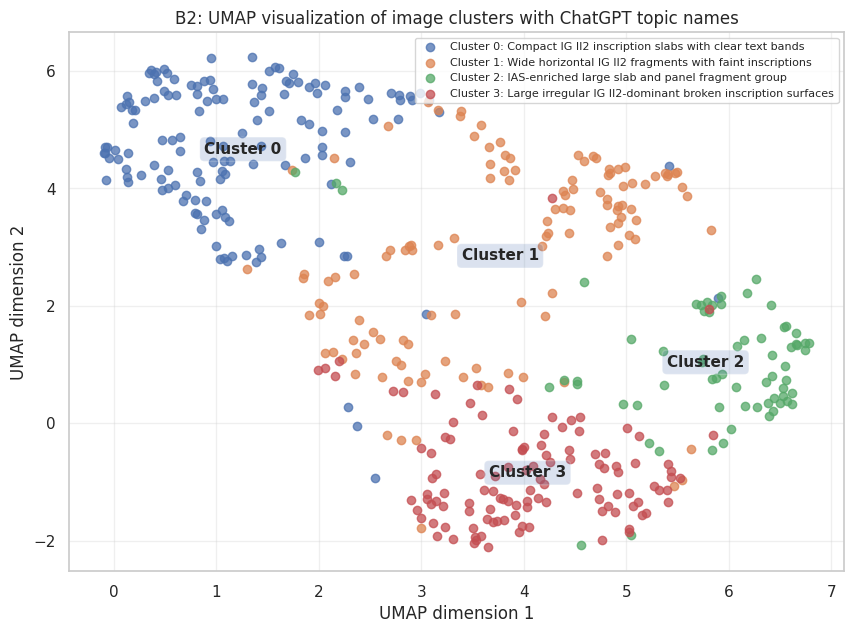

In [ ]:
# B2.11 Final UMAP visualization with ChatGPT topic names

plt.figure(figsize=(10, 7))

topic_name_map = dict(zip(
    b2_chatgpt_topics_df["cluster"],
    b2_chatgpt_topics_df["topic_name"]
))

for cluster_id in sorted(b2_embeddings_df["cluster"].unique()):
    cluster_data = b2_embeddings_df[b2_embeddings_df["cluster"] == cluster_id]
    topic_name = topic_name_map[cluster_id]

    plt.scatter(
        cluster_data["umap_x"],
        cluster_data["umap_y"],
        label=f"Cluster {cluster_id}: {topic_name}",
        alpha=0.75
    )

    # Add a text label near the center of each cluster in UMAP space
    center_x = cluster_data["umap_x"].mean()
    center_y = cluster_data["umap_y"].mean()

    plt.text(
        center_x,
        center_y,
        f"Cluster {cluster_id}",
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="center",
        bbox=dict(boxstyle="round,pad=0.3", alpha=0.2)
    )

plt.title("B2: UMAP visualization of image clusters with ChatGPT topic names")
plt.xlabel("UMAP dimension 1")
plt.ylabel("UMAP dimension 2")
plt.legend(loc="best", fontsize=8)
plt.grid(alpha=0.3)
plt.show()

**Β3.** Κατασκευάστε και αξιολογήστε ένα pipeline αναγνώρισης κειμένου. Αυτή η εργασία αντιστοιχεί στο ICDAR 2026 Competition. *(22 μονάδες)*

Επιλογές: Transformer-based OCR, προ-εκπαιδευμένα Vision Language Models (VLMs).

Αξιολογήστε χρησιμοποιώντας **Character Error Rate (CER)** σε **λατινικούς χαρακτήρες**, όπως στον επίσημο διαγωνισμό.

**Baseline μοντέλα αναφοράς:**
- **TrOCR** — Li et al. *"TrOCR: Transformer-based OCR with Pre-trained Models."* AAAI 2022. [arXiv:2109.10282](https://arxiv.org/abs/2109.10282). Model:
- **ViTSTR** — Atienza, R. *"Vision Transformer for Fast and Efficient Scene Text Recognition."* ICDAR 2021. [arXiv:2105.08582](https://arxiv.org/abs/2105.08582)

Παρακάτω παρέχεται μια **baseline λύση** με TrOCR. Χρησιμοποιήστε την ως αφετηρία, βελτιώστε, και δείξτε τη βελτίωση χρησιμοποιώντας το script αξιολόγησης του διαγωνισμού.

### B3 Solution:

After running the initial TrOCR baseline, we tried two simple improvements to make the OCR pipeline perform better. The main idea was first to clean the output of the pretrained model, and then to check whether fine-tuning a smaller TrOCR model on our own line crops could reduce the CER.

- **Variation 1: TrOCR-base with output normalization**  
  In the first variation, we kept the pretrained `microsoft/trocr-base-printed` model exactly as it was and only changed the predictions after inference. The raw TrOCR outputs sometimes contained lowercase letters, spaces, punctuation, or other symbols that were not useful for the official evaluation. Since the competition evaluates the result using CER on Latin-character transcriptions, we normalized the predictions by converting them to uppercase and removing characters that were not part of the expected format. This was a simple post-processing step, but it helped make the model output closer to the required transcript format.

- **Variation 2: Fine-tuned TrOCR-small**  
  In the second variation, we fine-tuned `microsoft/trocr-small-printed` using the line crops extracted from the dataset. We used only the training split for fine-tuning, and we split the data by inscription/base ID so that lines from the same inscription would not appear in both training and testing. To keep the training manageable on the available GPU memory, we used a batch size of `1` with gradient accumulation over `16` steps, so the effective batch size was larger while still fitting in memory. The model was trained for `5` epochs using `AdamW` with weight decay `0.01`. We used two learning rates: `2e-5` for the decoder and `1e-5` for the unfrozen encoder layers. Most of the encoder was frozen, and only the decoder together with the last two encoder layers were trained. We also used mixed precision, gradient checkpointing when possible, and gradient clipping with max norm `1.0`. After training, we generated predictions on the test line crops and applied the same normalization before running the official CER evaluator.

We then compared three results: the raw TrOCR-base baseline, the normalized TrOCR-base output, and the fine-tuned TrOCR-small model. For each method, we reported the official CER, as well as the absolute and relative improvement compared with the raw baseline.

### Results

The raw TrOCR-base baseline achieved a CER of `0.7837`. After applying output normalization, the CER became `0.7427`, which means that part of the error was caused by formatting problems in the generated text, such as spaces, punctuation, lowercase letters, or unsupported symbols. This simple post-processing step improved the result by `0.0409` absolute CER points, or about `5.22%`, without changing the model itself.

The fine tuned TrOCR-small model achieved the best CER, with a score of `0.6850`. This shows that even a smaller TrOCR model can perform better when it is adapted to the specific line crops of our dataset. Compared with the raw baseline, the fine-tuned model improved the CER by `0.0986` absolute points, or `12.59%` relatively. Therefore, the final results show that normalization is useful as a quick fix, but task-specific fine-tuning gives the largest improvement.

In [ ]:
!pip -q install transformers>=4.41 accelerate einops timm

In [ ]:
# Baseline: TrOCR inference on squeeze line images
import numpy as np, cv2, os
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-printed")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-printed")

model.to(device)
model.eval()

# TODO: Φορτώστε τις εικόνες γραμμών κειμένου (line images)
# TODO: Τρέξτε inference με TrOCR σε κάθε γραμμή
# TODO: Υπολογίστε CER σε λατινικούς χαρακτήρες
# TODO: Βελτιώστε το pipeline (fine-tuning, preprocessing, κ.λπ.)

Device: cuda
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.13k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-printed
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.weight | MISSING | 
encoder.pooler.dense.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

VisionEncoderDecoderModel(
  (encoder): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=False)
              (key): Linear(in_features=768, out_features=768, bias=False)
              (value): Linear(in_features=768, out_features=768, bias=False)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (i

#### Script αξιολόγησης διαγωνισμού (Official)

Το παρακάτω κελί περιέχει τον **επίσημο κώδικα αξιολόγησης** CER από τον ICDAR 2026 διαγωνισμό (contest_evaluation.py, Nicholas Howe, CC-BY 4.0). Χρησιμοποιήστε τον για να αξιολογήσετε τόσο το baseline όσο και τη δική σας λύση.

Η αξιολόγηση γίνεται σε **λατινικούς χαρακτήρες** (Latin proxies), όπως ακριβώς στον επίσημο διαγωνισμό.

In [ ]:
# Official ICDAR 2026 Contest Evaluation (Nicholas Howe, CC-BY 4.0)
# Source: contest_evaluation/contest_evaluation.py
# Requires: pip install textdistance

# -*- coding: utf-8 -*-
"""
Code released in conjunction with the 2026 ICDAR Competition in
Text Recognition on Greek Squeezes (TROGS-26)

Call run_evaluations(pred_dir,gt_dir) to evaluate.
pred_dir should contain your method's transcription files
    Filenames should be {squeeze}_transcript.txt
    Contents are line by line character transcriptions
gt_dir should contain letter box files with ground truth

@author: Nicholas Howe  CC-BY 4.0
"""

import math
import os
from os import listdir
from os.path import isfile, join
import numpy as np
from textdistance import levenshtein
import matplotlib.pyplot as plt

class Box:
    '''
    # simple class to keep track of coordinates for the four corners of a box
    # note corner order is CCW from NW corner, as stored in letter box file
    '''
    def __init__(self,xnw,ynw,xsw,ysw,xse,yse,xne,yne):
        self.xnw = xnw
        self.ynw = ynw
        self.xsw = xsw
        self.ysw = ysw
        self.xse = xse
        self.yse = yse
        self.xne = xne
        self.yne = yne

    def bd(self):
        return [self.xnw,self.ynw,self.xsw,self.ysw,self.xse,self.yse,self.xne,self.yne]

    def center(self):
        return((self.xnw+self.xne+self.xse+self.xsw)/4,(self.ynw+self.yne+self.yse+self.ysw)/4)

    def radius(self):
        return (math.sqrt((self.xnw-self.xse)*(self.xnw-self.xse)+(self.ynw-self.yse)*(self.ynw-self.yse))+math.sqrt((self.xne-self.xsw)*(self.xne-self.xsw)+(self.yne-self.ysw)*(self.yne-self.ysw)))/4

    def area(self):
        # uses top and left side, assuming orthogonal rectangle
        return math.sqrt(((self.xne-self.xnw)**2+(self.yne-self.ynw)**2)*((self.xsw-self.xnw)**2+(self.ysw-self.ynw)**2))

    def angle(self):
        return math.atan2(self.yne-self.ynw,self.xne-self.xnw)

    def dist(self,box):
        c = self.center()
        c2 = box.center()
        return math.sqrt((c[0]-c2[0])*(c[0]-c2[0])+(c[1]-c2[1])*(c[1]-c2[1]))

    def plot(self,clr='r-'):
        plt.plot([self.xnw,self.xne,self.xse,self.xsw,self.xnw],[self.ynw,self.yne,self.yse,self.ysw,self.ynw],clr)


def convert(stringin):
    """
    Convert Greek characters to letter proxies.

    Parameters
    ----------
    stringin : String
        Character string possibly containing Greek.

    Returns
    -------
    txt : String
        Converted string with Greek characters replaced by Latin proxy.

    """
    eqv = {
        913:"A",  # ALPHA
        7944:"A", # ALPHA + AIGU
        914:"B",  # BETA
        915:"G",  # GAMMA
        916:"D",  # DELTA
        917:"E",  # EPSILON
        918:"Z",  # ZETA
        919:"H",  # ETA
        920:"Q",  # THETA
        921:"I",  # IOTA
        922:"K",  # KAPPA
        923:"L",  # LAMDA
        924:"M",  # MU
        925:"N",  # NU
        926:"X",  # XI
        927:"O",  # OMICRON
        928:"P",  # PI
        929:"R",  # PI
        931:"S",  # SIGMA
        932:"T",  # TAU
        933:"U",  # UPSILON
        934:"F",  # PHI
        935:"Y",  # PSI
        936:"C",  # CHI
        937:"W",  # OMEGA
        945:"a",  # ALPHA
        8118:"a",  # ALPHA + TILDE
        8119:"a",  # ALPHA + TILDE + CEDILLE
        7942:"a",  # ALPHA + TILDE + TICK
        7943:"a",  # ALPHA + TILDE + BACKTICK
        8070:"a",  # ALPHA + TILDE + TICK + CEDILLE
        8071:"a",  # ALPHA + TILDE + BACKTICK + CEDILLE
        8048:"a",  # ALPHA + GRAVE
        8049:"a",  # ALPHA + AIGU
        7936:"a",  # ALPHA + TICK
        7937:"a",  # ALPHA +BACKTICK
        7940:"a",  # ALPHA + TICK + AIGU
        7941:"a",  # ALPHA + BACKTICK + AIGU
        7938:"a",  # ALPHA + TICK + GRAVE
        7939:"a",  # ALPHA + BACKTICK + GRAVE
        946:"b",  # BETA
        947:"g",  # GAMMA
        948:"d",  # DELTA
        949:"e",  # EPSILON
        7952:"e",  # EPSILON + TICK
        7953:"e",  # EPSILON + BACKTICK
        8050:"e",  # EPSILON + GRAVE
        8051:"e",  # EPSILON + AIGU
        7956:"e",  # EPSILON + TICK + AIGU
        7957:"e",  # EPSILON + BACKTICK + AIGU
        7954:"e",  # EPSILON + TICK + GRAVE
        7955:"e",  # EPSILON + BACKTICK + GRAVE
        950:"z",  # ZETA
        951:"h",  # ETA
        7974:"h",  # ETA + TILDE + TICK + CEDILLE
        7975:"h",  # ETA + TILDE + BACKTICK + CEDILLE
        8086:"h",  # ETA + TILDE + TICK
        8087:"h",  # ETA + TILDE + BACKTICK
        8134:"h",  # ETA + TILDE
        8135:"h",  # ETA + TILDE + CEDILLE
        7970:"h",  # ETA + TICK + GRAVE
        7971:"h",  # ETA + BACKTICK + GRAVE
        8016:"h",  # ETA + TICK?
        8020:"h",  # ETA + TICK + AIGU
        7968:"h",  # ETA + TICK
        7969:"h",  # ETA + BACKTICK
        7972:"h",  # ETA + TICK + AIGU
        7973:"h",  # ETA + BACKTICK + AIGU
        8052:"h",  # ETA + GRAVE
        8053:"h",  # ETA + AIGU ?
        952:"q",  # THETA
        953:"i",  # IOTA
        7990:"i",  # IOTA + TILDE + TICK
        7991:"i",  # IOTA + TILDE + BACKTICK
        8150:"i",  # IOTA + TILDE
        8054:"i",  # IOTA + GRAVE
        8055:"i",  # IOTA + AIGU
        7984:"i",  # IOTA + TICK
        7985:"i",  # IOTA + BACKTICK
        7988:"i",  # IOTA + TICK + AIGU
        7989:"i",  # IOTA + BACKTICK + AIGU
        7986:"i",  # IOTA + TICK + GRAVE
        7987:"i",  # IOTA + BACKTICK + GRAVE
        954:"k",  # KAPPA
        955:"l",  # LAMDA
        956:"m",  # MU
        957:"n",  # NU
        834:"n",  # NU + TILDE
        958:"x",  # XI
        959:"o",  # OMICRON
        8056:"o",  # OMICRON + GRAVE
        8057:"o",  # OMICRON + AIGU
        8000:"o",  # OMICRON + TICK
        8001:"o",  # OMICRON + BACKTICK
        8004:"o",  # OMICRON + TICK + AIGU
        8005:"o",  # OMICRON + BACKTICK + AIGU
        8002:"o",  # OMICRON + TICK + GRAVE
        8003:"o",  # OMICRON + BACKTICK + GRAVE
        960:"p",  # PI
        961:"r",  # RHO
        962:"v",  # SIGMA
        963:"s",  # SIGMA
        964:"t",  # TAU
        965:"u",  # UPSILON
        8022:"u",  # UPSILON + TILDE + TICK
        8023:"u",  # UPSILON + TILDE + BACKTICK
        8166:"u",  # UPSILON + TILDE
        8016:"u",  # UPSILON + TICK
        8017:"u",  # UPSILON + BACKTICK
        8020:"u",  # UPSILON + TICK + AIGU
        8021:"u",  # UPSILON + BACKTICK + AIGU
        8018:"u",  # UPSILON + TICK + GRAVE
        8019:"u",  # UPSILON + BACKTICK + GRAVE
        8058:"u",  # UPSILON + GRAVE
        8059:"u",  # UPSILON + AIGU ?
        966:"f",  # PHI
        967:"y",  # PSI
        968:"c",  # CHI
        969:"w",  # OMEGA
        8102:"w",  # OMEGA + TILDE + TICK + CEDILLE
        8103:"w",  # OMEGA + TILDE + BACKTICK + CEDILLE
        8038:"w",  # OMEGA + TILDE + TICK
        8039:"w",  # OMEGA + TILDE + BACKTICK
        8182:"w",  # OMEGA + TILDE
        8183:"w",  # OMEGA + TILDE + CEDILLE
        8060:"w",  # OMEGA + GRAVE
        8061:"w",  # OMEGA + AIGU
        8032:"w",  # OMEGA + TICK
        8033:"w",  # OMEGA + BACKTICK
        8036:"w",  # OMEGA + TICK + AIGU
        8037:"w",  # OMEGA + BACKTICK + AIGU
        8034:"w",  # OMEGA + TICK + GRAVE
        8035:"w",  # OMEGA + BACKTICK + GRAVE

        8217:"'",  # TICK???
        8025:"`",  # BACKTICK???
        803:"_",  # CEDILLE???
        8195:" ",  # WEIRD SPACE???
        903:".",  # WEIRD DOT???
        8228:".",  # WEIRD DOT???
        8311:"7",  # SUPERSCRIPT 7

        # Formatting characters
        10:"\n",  # CARRIAGE RETURN
        3:" ",  # SPACE
        32:" "  # SPACE
    }
    for i in range(0, 254):
        eqv[i] = chr(i)

    txt = []
    for char in stringin:
        if ord(char) in eqv:
            txt.append(eqv[ord(char)])
        else:
            txt.append(char)
    txt = "".join(txt)
    return txt.upper()


def readBoxFile(fname):
    """
    Parameters
    ----------
    fname : Name of the file to read

    Returns
    -------
    angle : Primary angle of the text
    boxes : List of boxes
    transcript : Box annotations
    lines : Information about how boxes are arranged in lines
    """
    angle = None
    boxes = []
    transcript = []
    lines = []
    try:
        with open(fname, "r") as f:
            phase = 0
            count = 0
            for line in f:
                count = count+1
                line2 = line.replace('*','').replace(' ','')
                if line2=='' or line2=='\n':
                    continue  # skip empty line
                elif line[0]=='#':
                    phase = phase+1
                elif phase==0:  # File should begin with a comment
                    #if line[0]=='# Baseline angle\n':
                    print("Header problem in file {}.".format(fname))
                elif phase==1:
                    #if line=='# Boxes: x1 y1 x2 y2 x3 y3 x4 y4\n':
                    if angle==None:
                        angle = float(line)
                    else:
                        print("Multiple angle data found in {}.".format(fname))
                elif phase==2:
                    #if line=='# Transcript\n':
                    n = line.split()
                    if len(n)==8:
                        box = Box(*[float(c) for c in n])
                        if box.area() < 9:
                            print("Skipping box with very small area (line {}).".format(count))
                        else:
                            boxes.append(box)
                    else:
                        print('Incorrect parameter count for box line ({}) in {}.'.format(len(n),fname))
                elif phase==3:
                    transcript.append(line.replace('*','').replace('\n','').replace('\r','').replace(' ',''))
                elif phase==4:
                    n = line.split()
                    if len(n)==4:
                        lines.append([float(c) for c in n])
                        if np.any(np.isnan(lines[-1])):
                            print('Bad values found in line specification (file line {}) -- skipping.'.format(count))
                            lines.pop()
                        elif lines[-1][0]==lines[-1][2] and lines[-1][1]==lines[-1][3]:
                            print('Zero-length line found in line specification (file line {}) -- skipping.'.format(count))
                            lines.pop()
                    else:
                        print('Incorrect parameter count for line specifiers ({}) in {}.'.format(len(n),fname))
            f.close()
    except FileNotFoundError:
        print(f"File '{fname}' not found.")
    except Exception as e:
        print(f"An error occurred: {str(e)}")
    return angle,boxes,transcript,lines


def dist2seg(x,y,seg):
    '''
    # compute the distance from a point to the nearest point on a line segment
    '''
    x0 = seg[0]
    y0 = seg[1]
    x1 = seg[2]
    y1 = seg[3]
    rx = x-x0
    ry = y-y0
    rx1 = x1-x0
    ry1 = y1-y0
    seglen = math.sqrt(rx1**2+ry1**2)
    parcomp = (rx*rx1+ry*ry1)/seglen
    if parcomp<0:
        # closest point is p0 endpoint
        d = math.sqrt(rx**2+ry**2)
    elif parcomp > seglen:
        # closest point is p1 endpoint
        d = math.sqrt((x-x1)**2+(y-y1)**2)
    else:
        # find closest point p along segment
        t = parcomp/seglen
        px = x0+t*rx1
        py = y0+t*ry1
        d = math.sqrt((x-px)**2+(y-py)**2)
    return d


def getRowBoxes(boxes,gangle=None,lines=[]):
    """
    Orders a set of boxes into rows.
    Designed to work with data from a letter box file.
    """
    if len(lines)==0:
        # infer lines by spatial arrangement
        nboxes = len(boxes)
        bclust = np.full((nboxes),-1)
        bseq = np.zeros((nboxes))
        lnbr = np.full((nboxes),-1)
        rnbr = np.full((nboxes),-1)

        # speed up inner loop by sorting x coordinates
        xcent = [b.center()[0] for b in boxes]
        xsort = np.sort(xcent)
        xord = np.argsort(xcent)
        xlut = np.argsort(xord)

        # find left and right nearest neighbors for each box
        for i in range(nboxes):
            ci = boxes[i].center()
            if (gangle==None):
                # no global angle so compute a local one from the top line of this box
                angle = boxes[i].angle()
            else:
                angle = gangle
            ax = math.cos(angle)
            ay = math.sin(angle)
            rd = np.inf  # current distance to closest right leighbor
            ld = np.inf  # current distance to closest left neighbor
            # we are going to start at the x value of the current box, and check nearby
            # values of x both higher and lower
            klo = xlut[i]
            khi = klo
            assert(ci[0] == xsort[klo])
            while min(ci[0]-xsort[klo],xsort[khi]-ci[0]) < max(rd,ld) and (klo>0 or khi < nboxes-1):
                if (ci[0]-xsort[klo] < xsort[khi]-ci[0] or khi >= nboxes-1) and klo > 0:
                    # reduce klo
                    klo = klo-1
                    j = xord[klo]  # next closest x value below
                elif khi < nboxes-1:
                    # increase khi
                    khi = khi+1
                    j = xord[khi]  # next closest x value above
                else:
                    print('Should not reach this!')
                # check whether box j is closer to i on either the left or the right
                d = boxes[i].dist(boxes[j])
                cj = boxes[j].center()
                rj = boxes[j].radius();
                rjsq = rj*rj
                dcx = cj[0]-ci[0]
                dcy = cj[1]-ci[1]
                dotprod = dcx*ax+dcy*ay
                isRight = dotprod > 0
                if (i!=j) and (d<ld) and not isRight:
                    # found a closer left neighbor, so check position and update if near line
                    c = (ci[0]-d*ax, ci[1]-d*ay)
                    if (cj[0]-c[0])**2+(cj[1]-c[1])**2 < rjsq:
                        ld = d
                        lnbr[i] = j
                if (i!=j) and (d<rd) and isRight:
                    # found a closer right neighbor, so check position and update if near line
                    c = (ci[0]+d*ax, ci[1]+d*ay)
                    if (cj[0]-c[0])**2+(cj[1]-c[1])**2 < rjsq:
                        rd = d
                        rnbr[i] = j
                #print(i,j)

        # sanity/correctness check for neighbor detection -- hopefully should never report a mismatch.
        for i in range(len(rnbr)):
            if rnbr[i]>=0 and lnbr[rnbr[i]]!=i:
                if lnbr[rnbr[i]] >= 0 and rnbr[lnbr[rnbr[i]]] == rnbr[i]:
                    # pointing to a neighbor that is mutually satisfied; this link is probably wrong
                    rnbr[i] = -2
            if lnbr[i]>=0 and rnbr[lnbr[i]]!=i:
                if rnbr[lnbr[i]] >= 0 and lnbr[rnbr[lnbr[i]]] == lnbr[i]:
                    # pointing to a neighbor that is mutually satisfied; this link is probably wrong
                    lnbr[i] = -2
        for i in range(len(rnbr)):
            if rnbr[i]>=0 and lnbr[rnbr[i]]!=i:
                if lnbr[rnbr[i]]<0:
                    # link up unassigned box
                    lnbr[rnbr[i]] = i
                else:
                    print('Left of right mismatch at {}: {} to {}.'.format(i,rnbr[i],lnbr[rnbr[i]]))
                    #lnbr[rnbr[i]] = -3
                    #rnbr[i]=-3
            if lnbr[i]>=0 and rnbr[lnbr[i]]!=i:
                if rnbr[lnbr[i]]<0:
                    # link up unassigned box
                    rnbr[lnbr[i]] = i
                else:
                    print('Right of left mismatch at {}: {} to {}.'.format(i,lnbr[i],rnbr[lnbr[i]]))
                    #rnbr[lnbr[i]] = -3
                    #lnbr[i] = -3

        # cluster boxes by row: combine nearest neighbors one by one
        clust = 0
        cid = []
        cseq = []
        for i in range(nboxes):
            if (gangle==None):
                angle = boxes[i].angle()
            else:
                angle = gangle
            if (bclust[i] == -1):
                # we have found a box belonging to a new cluster, so assemble all of its neighbors and give them the same cluster label
                c = [i]
                bclust[i] = clust
                bseq[i] = boxes[i].center()[0]*math.cos(angle)+boxes[i].center()[1]*math.sin(angle)
                j = lnbr[i]
                while (j>=0) and not j in c:
                    bclust[j] = clust
                    c.append(j)
                    bseq[j] = boxes[j].center()[0]*math.cos(angle)+boxes[j].center()[1]*math.sin(angle)
                    j = lnbr[j]
                j = rnbr[i]
                while (j>=0) and not j in c:
                    bclust[j] = clust
                    c.append(j)
                    bseq[j] = boxes[j].center()[0]*math.cos(angle)+boxes[j].center()[1]*math.sin(angle)
                    j = rnbr[j]
                cseq.append(-boxes[i].center()[0]*math.sin(angle)+boxes[i].center()[1]*math.cos(angle))
                cid.append(c)
                clust = clust+1
            # the new cluster is now labeled
            #print(clust,c,cseq,bseq)

        rowlist = []
        # at the end of this loop, all the boxes are labeled with a unique cluster id.
        # they may not be sorted left to right or top to bottom yet
        # cseq holds a value that increases from top to bottom,
        # and bseq holds a value that increases from left to right within a row
        # so the boxes should be reordered and assembled according to these numbers.
        # use ord2lut to convert the numeric values to a list of indices that are in the correct order
        for c in cid:
            # c is a list of the box ids belonging to this cluster
            rowlist.append([boxes[c[i]] for i in np.argsort(bseq[c])])
        return [rowlist[i] for i in np.argsort(cseq)], [cid[i] for i in np.argsort(cseq)]  # reorder rows based on cseq value
    else:
        # attribute boxes to lines based on supplied line information
        # first, identify any polylines:
        label = np.zeros(len(lines),dtype=np.int32)
        for i in range(1,len(lines)):
            if lines[i][0]==lines[i-1][2] and lines[i][1]==lines[i-1][3]:
                # we have a continuation
                label[i] = label[i-1]
            else:
                # new polyline
                label[i] = label[i-1]+1

        # next, find min distance from each box to a line segment
        blabel = np.zeros(len(boxes))
        for i in range(len(boxes)):
            d = dist2seg(*boxes[i].center(),lines[0])
            blabel[i] = 0
            for j in range(1,len(lines)):
                jd = dist2seg(*boxes[i].center(),lines[j])
                if jd<d:
                    d = jd
                    blabel[i] = label[j]

        # now arrange the boxes within the rows
        rowlist = []
        idlist = []
        for i in range(label[-1]+1):
            j = 0
            while j < len(boxes) and blabel[j]!=i:  # keep going until we find the first box with label i
                j = j+1
            if j<len(boxes):  # just make sure we found at least one box assigned to this label
                row = [boxes[j]]
                rowid = [j]
                rank = [0]
                for k in range(j+1,len(boxes)):
                    if blabel[k]==i:
                        row.append(boxes[k])
                        rowid.append(k)
                        rank.append((boxes[k].xnw-boxes[j].xnw)*(boxes[j].xne-boxes[j].xnw)+(boxes[k].ynw-boxes[j].ynw)*(boxes[j].yne-boxes[j].ynw))
                # now we have all the boxes in this row, and rank holds a value that will sort them
                rowlist.append([row[i] for i in np.argsort(rank)])
                idlist.append([rowid[i] for i in np.argsort(rank)])
        return rowlist, idlist


def orderBoxes(boxes,gangle=None,lines=[]):
    rowlist, idlist = getRowBoxes(boxes,gangle=gangle,lines=lines)
    return [b for row in rowlist for b in row]


def getRowTranscript(fname):
      """
      Reads a file of annotated letter boxes and arranges them into rows
      ordered from left to right.

      For contest grading purposes, we want to use simple left-to-right,
      top down reading order, explicitly ignoring multicolumn layouts.

      To make sure the transcript matches, we need to first generate the
      multicolumn result and then reorder into full-width lines.
      """
      gangle, boxes, transcript, lines = readBoxFile(fname)
      boxes2 = orderBoxes(boxes,gangle,lines)  # reordered to transcript order
      rowlist, idlist = getRowBoxes(boxes2,gangle=gangle)  # ignore multicolumn
      lintran = ''.join(transcript)
      return ''.join([''.join([lintran[i] for i in rowid])+'\n' for rowid in idlist])


def evaluate(prediction,gt):
    """
    Evaluates the given prediction against the
    corresponding ground truth file.
    Includes line breaks as characters.

    Parameters
    ----------
    prediction : String
        Text transcription to be graded
    gt : String
        Accepted ground truth transcript

    Returns
    -------
    CER, n_error, n_char

    """
    n_error = levenshtein(convert(prediction).upper().replace(' ','').replace('\t',''),gt)
    n_char = len(gt)
    cer = n_error/n_char
    return cer, n_error, n_char


def run_evaluations(pred_dir,gt_dir):
    """
    Runs the evaluation for all files in the ground truth directory.
    For a given ground truth file (named SQUEEZE_letters.txt),
    it looks for a prediction file named SQUEEZE_pred.txt
    containing the transcribed letters.

    Parameters
    ----------
    pred_dir : String, optional
        Directory containing prediction files. The default is '.'.
    gt_dir : TYPE, optional
        Directory containing ground truth files. The default is '.'.

    Returns
    -------
    Mean character error rate.

    """
    gt_files = [f for f in listdir(gt_dir) if isfile(join(gt_dir, f)) and f[-29:]=='_Rotation1_300dpi_letters.txt']  # transcript is same for both rotations
    cer = []
    n_error = []
    n_char = []
    for gtf in gt_files:
        predf = os.path.join(pred_dir,gtf[:-29]+'_transcript.txt')
        try:
            with open(predf, "r", encoding='utf8') as f:
                pred = "".join([line for line in f])
        except FileNotFoundError:
            print(f"Unable to find prediction file '{predf}'.")
            pred = ""
        except Exception as e:
            print(f"An error occurred: {str(e)} while reading '{predf}'.")
            pred = ""
        pred = convert(pred)
        gt = getRowTranscript(os.path.join(gt_dir,gtf))
        sq_cer, sq_n_error, sq_n_char = evaluate(pred,gt)
        cer.append(sq_cer)
        n_error.append(sq_n_error)
        n_char.append(sq_n_char)
    return sum(n_error)/sum(n_char)


#if __name__ == "__main__":
 #   #cer = run_evaluations(pred_dir='.',gt_dir='.')
  #  cer = run_evaluations(pred_dir='pred',gt_dir='gt')
   # print(f'Mean character error rate is {cer}.')


# === Quick usage example ===
# For single-file evaluation:
#   cer, n_err, n_char = evaluate(my_prediction_text, ground_truth_text)
#   print(f"CER: {cer:.4f}")
#
# For full directory evaluation (matching contest format):
#   cer = run_evaluations(pred_dir='path/to/predictions', gt_dir='path/to/ground_truth')
#   print(f"Mean CER: {cer:.4f}")

In [ ]:
# TODO: Η δική σας βελτιωμένη λύση + σύγκριση CER baseline vs δική σας

#### B3.0 Building line-crop images and per-line ground truth

This cell creates the line images that are later given to the OCR model. First, it reads the annotation files and uses the given bounding boxes to find which characters belong to each text line. Then, it deskews the original image so that the text is more horizontal and cuts out each line as a separate crop.

For each cropped line, we also keep its ground-truth text and some useful information, such as the inscription id, row index, and number of characters. After that, the data is split into train and test sets using the base inscription id, not individual lines. This is important because otherwise lines from the same inscription could appear in both train and test, which would make the results unfair. At the end, the cell shows a few sample line crops to check that the cropping process worked correctly..

Cutting line crops:   0%|          | 0/448 [00:00<?, ?it/s]

Left of right mismatch at 379: 363 to 362.
Left of right mismatch at 379: 363 to 362.
Left of right mismatch at 379: 363 to 362.
Left of right mismatch at 379: 363 to 362.
Left of right mismatch at 307: 362 to 313.
Left of right mismatch at 307: 362 to 313.
Right of left mismatch at 61: 52 to 53.
Right of left mismatch at 61: 52 to 53.
Right of left mismatch at 61: 52 to 53.
Right of left mismatch at 61: 52 to 53.
Left of right mismatch at 449: 569 to 438.
Left of right mismatch at 449: 569 to 438.
Left of right mismatch at 266: 450 to 274.
Left of right mismatch at 449: 569 to 438.
Right of left mismatch at 450: 274 to 458.
Left of right mismatch at 266: 450 to 274.
Left of right mismatch at 449: 569 to 438.
Right of left mismatch at 450: 274 to 458.
Right of left mismatch at 655: 637 to 638.
Left of right mismatch at 674: 675 to 699.
Left of right mismatch at 966: 1230 to 972.
Left of right mismatch at 1046: 1365 to 1054.
Right of left mismatch at 1239: 972 to 1230.
Right of left mis

,line_index,inscription_id,base_id,row_index,text,n_chars
0,0,Agora_I_4985_Rotation1_300dpi,Agora_I_4985,0,STOKAI,6
1,1,Agora_I_4985_Rotation1_300dpi,Agora_I_4985,1,DIKOSE,6
2,2,Agora_I_4985_Rotation1_300dpi,Agora_I_4985,2,IHIDIKHT,8
3,3,Agora_I_4985_Rotation1_300dpi,Agora_I_4985,3,OSENNEA,7
4,4,Agora_I_4985_Rotation1_300dpi,Agora_I_4985,4,AYTOID,6



Line crops per split:
split
train    6372
test     1486
Name: count, dtype: int64

Inscriptions per split:
split
test      90
train    358
Name: inscription_id, dtype: int64


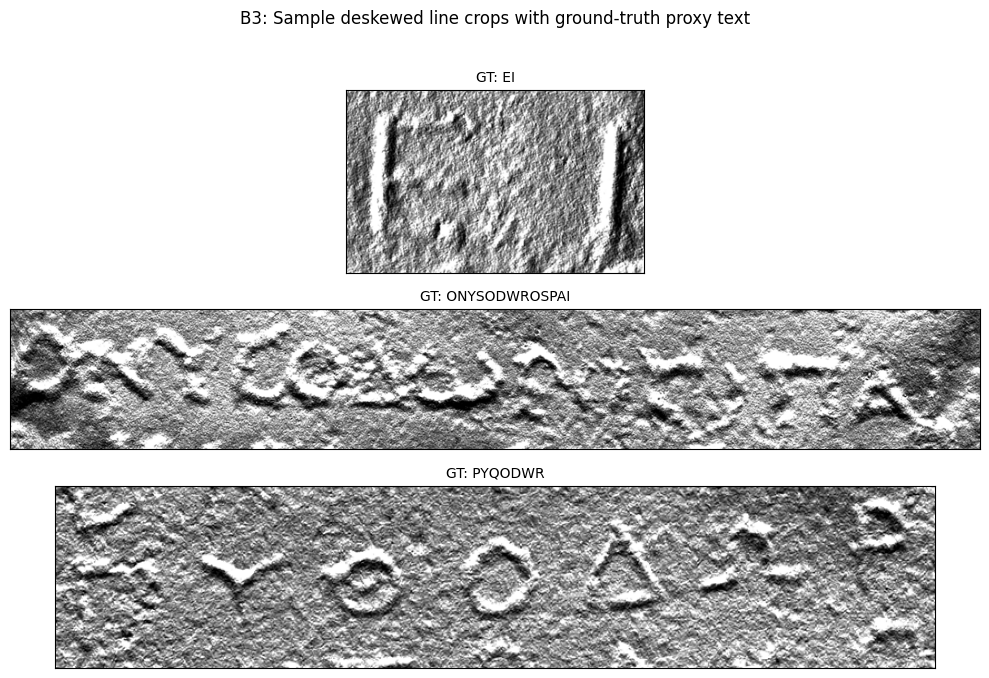

In [ ]:
for _name in ["readBoxFile", "orderBoxes", "getRowBoxes", "getRowTranscript", "run_evaluations"]:
    if _name not in globals():
        raise NameError(f"{_name} is not defined. Run the official evaluation script cell first.")

if "b1_images_df" not in globals():
    raise NameError("b1_images_df is not defined. Run your B1 image-loading/preprocessing cells first.")

if "annotations_dir" not in globals():
    raise NameError("annotations_dir is not defined. Run your dataset-loading cells first.")

annotations_path = Path(annotations_dir)

def b3_rotation_matrix(image_shape, angle_rad):
    """Affine matrix that rotates the image so the text baseline is horizontal."""
    h, w = image_shape[:2]
    center = (w / 2.0, h / 2.0)
    return cv2.getRotationMatrix2D(center, math.degrees(angle_rad), 1.0)


def b3_apply_matrix(points, matrix):
    """Apply a 2x3 affine matrix to an array of (x, y) points."""
    points = np.asarray(points, dtype=np.float64)
    homogeneous = np.hstack([points, np.ones((points.shape[0], 1))])
    return homogeneous @ matrix.T


B3_CROP_PADDING = 6


def b3_extract_lines(image_path, annotation_path):
    """
    Return a list of (line_crop, line_text) for one inscription.
    The row grouping follows the official evaluation script.
    """
    gray = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if gray is None:
        return []

    gangle, boxes, transcript, lines = readBoxFile(str(annotation_path))

    if not boxes:
        return []

    boxes2 = orderBoxes(boxes, gangle, lines)
    _, idlist = getRowBoxes(boxes2, gangle=gangle)
    gt_lines = getRowTranscript(str(annotation_path)).split("\n")

    rotate_angle = gangle if gangle is not None else 0.0
    matrix = b3_rotation_matrix(gray.shape, rotate_angle)

    h, w = gray.shape[:2]
    pad_value = int(np.median(gray))

    deskewed = cv2.warpAffine(
        gray,
        matrix,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderValue=pad_value
    )

    results = []

    for row_index, rowid in enumerate(idlist):
        if row_index >= len(gt_lines):
            break

        text = gt_lines[row_index].strip()

        if text == "":
            continue

        corners = []

        for i in rowid:
            b = boxes2[i]
            corners.extend([
                (b.xnw, b.ynw),
                (b.xsw, b.ysw),
                (b.xse, b.yse),
                (b.xne, b.yne),
            ])

        moved = b3_apply_matrix(corners, matrix)

        x_min = int(max(0, np.floor(moved[:, 0].min()) - B3_CROP_PADDING))
        x_max = int(min(w, np.ceil(moved[:, 0].max()) + B3_CROP_PADDING))
        y_min = int(max(0, np.floor(moved[:, 1].min()) - B3_CROP_PADDING))
        y_max = int(min(h, np.ceil(moved[:, 1].max()) + B3_CROP_PADDING))

        if x_max - x_min < 5 or y_max - y_min < 5:
            continue

        crop = deskewed[y_min:y_max, x_min:x_max]
        results.append((crop, text))

    return results


b3_line_crops = []
b3_records = []

b3_source_df = b1_images_df.drop_duplicates("inscription_id").reset_index(drop=True)

skipped = 0

for _, row in tqdm(
    b3_source_df.iterrows(),
    total=len(b3_source_df),
    desc="Cutting line crops"
):
    annotation_path = annotations_path / f"{row['inscription_id']}_letters.txt"

    if not annotation_path.exists():
        skipped += 1
        continue

    try:
        lines_out = b3_extract_lines(row["image_path"], annotation_path)
    except Exception as e:
        skipped += 1
        continue

    base_id = re.sub(r"_Rotation\d+_\d+dpi$", "", row["inscription_id"])

    for row_index, (crop, text) in enumerate(lines_out):
        b3_records.append({
            "line_index": len(b3_line_crops),
            "inscription_id": row["inscription_id"],
            "base_id": base_id,
            "row_index": row_index,
            "text": text,
            "n_chars": len(text),
        })

        b3_line_crops.append(crop)

b3_lines_df = pd.DataFrame(b3_records)

print(f"\nInscriptions processed: {len(b3_source_df) - skipped}")
print(f"Inscriptions skipped:   {skipped}")
print(f"Total line crops:       {len(b3_line_crops)}")
print(f"Unique base inscriptions: {b3_lines_df['base_id'].nunique()}")

display(b3_lines_df.head())


# Split by base inscription, not by line, to avoid leakage.
unique_bases = b3_lines_df["base_id"].unique()

train_bases, test_bases = train_test_split(
    unique_bases,
    test_size=0.2,
    random_state=42
)

train_bases = set(train_bases)

b3_lines_df["split"] = np.where(
    b3_lines_df["base_id"].isin(train_bases),
    "train",
    "test"
)

print("\nLine crops per split:")
print(b3_lines_df["split"].value_counts())

print("\nInscriptions per split:")
print(b3_lines_df.groupby("split")["inscription_id"].nunique())


# Visual sanity check.
sample_idx = (
    b3_lines_df
    .sample(n=min(3, len(b3_lines_df)), random_state=0)["line_index"]
    .tolist()
)

fig, axes = plt.subplots(len(sample_idx), 1, figsize=(10, 2.2 * len(sample_idx)))

if len(sample_idx) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_idx):
    ax.imshow(b3_line_crops[idx], cmap="gray", vmin=0, vmax=255)

    gt = b3_lines_df.loc[
        b3_lines_df["line_index"] == idx,
        "text"
    ].values[0]

    ax.set_title(f"GT: {gt}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("B3: Sample deskewed line crops with ground-truth proxy text", y=1.02)
plt.tight_layout()
plt.show()

#### B3.1 Official Evaluation Helper
This cell prepares the files needed to evaluate our OCR predictions with the official CER scorer. It first copies the ground-truth annotation files for the test inscriptions into a separate evaluation folder. Then, it defines a helper function that takes the predicted text for each line, writes it back into transcript files in the format expected by the competition script, and runs the official evaluation.

This makes the evaluation easier, because we can use the same function for all methods: the raw TrOCR baseline, the normalized baseline, and the fine-tuned model.

In [ ]:
B3_EVAL_ROOT = "/content/b3_eval"
B3_GT_DIR = os.path.join(B3_EVAL_ROOT, "gt")

os.makedirs(B3_EVAL_ROOT, exist_ok=True)
os.makedirs(B3_GT_DIR, exist_ok=True)

b3_test_ids = sorted(
    b3_lines_df.loc[b3_lines_df["split"] == "test", "inscription_id"].unique()
)

print(f"Test inscription IDs: {len(b3_test_ids)}")


def b3_prepare_gt_dir():
    """
    Copy official ground-truth files for test inscriptions.
    The official scorer reads only *_Rotation1_300dpi_letters.txt files.
    """
    os.makedirs(B3_GT_DIR, exist_ok=True)

    for f in listdir(B3_GT_DIR):
        os.remove(join(B3_GT_DIR, f))

    copied = 0

    for inscription_id in b3_test_ids:
        if not inscription_id.endswith("_Rotation1_300dpi"):
            continue

        src = Path(annotations_dir) / f"{inscription_id}_letters.txt"

        if src.exists():
            shutil.copy(str(src), join(B3_GT_DIR, src.name))
            copied += 1

    return copied


def b3_write_predictions_and_score(pred_by_line, pred_dir_name):
    """
    Write predictions in official format and run official CER evaluation.

    pred_by_line:
        dict line_index -> predicted text line

    pred_dir_name:
        folder name under /content/b3_eval
    """
    pred_dir = os.path.join(B3_EVAL_ROOT, pred_dir_name)
    os.makedirs(pred_dir, exist_ok=True)

    for f in listdir(pred_dir):
        os.remove(join(pred_dir, f))

    test_rows = b3_lines_df[b3_lines_df["split"] == "test"].copy()

    for inscription_id, group in test_rows.groupby("inscription_id"):
        if not inscription_id.endswith("_Rotation1_300dpi"):
            continue

        group = group.sort_values("row_index")

        lines_out = [
            pred_by_line.get(line_index, "")
            for line_index in group["line_index"]
        ]

        squeeze = inscription_id[: -len("_Rotation1_300dpi")]
        out_path = join(pred_dir, f"{squeeze}_transcript.txt")

        with open(out_path, "w", encoding="utf8") as fh:
            fh.write("\n".join(lines_out) + "\n")

    cer = run_evaluations(pred_dir=pred_dir, gt_dir=B3_GT_DIR)

    return cer


n_gt = b3_prepare_gt_dir()
print(f"Ground-truth files copied for official scoring: {n_gt}")

Test inscription IDs: 90
Ground-truth files copied for official scoring: 45


#### B3.2 TrOCR Inference Utilities

This cell defines the helper functions used when running TrOCR on our line crops. Since TrOCR expects RGB PIL images, the first function converts each grayscale OpenCV crop into the correct image format.

The cell also includes a normalization function for the predicted text. This is needed because the pretrained TrOCR model may output spaces, punctuation, digits, or lowercase letters, while our evaluation expects clean uppercase Latin text. Finally, the prediction function runs the model in batches, decodes the generated tokens into text, and optionally applies the normalization step before returning the predictions for each line.

In [ ]:
# B3.4 Utility functions for TrOCR inference

def b3_crop_to_pil(gray_crop):
    """Convert a grayscale OpenCV crop to RGB PIL image."""
    rgb = cv2.cvtColor(gray_crop, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(rgb)


def b3_normalize_prediction(text):
    """
    Normalize OCR predictions for the Latin proxy CER task.

    The target is uppercase Latin proxy text. Pretrained TrOCR often emits
    spaces, punctuation, digits, and symbols because it was trained on modern text.
    """
    if text is None:
        return ""

    text = unicodedata.normalize("NFKC", str(text))
    text = text.upper()

    common_replacements = {
        "0": "O",
        "1": "I",
        "|": "I",
        "5": "S",
        "8": "B",
    }

    for src, tgt in common_replacements.items():
        text = text.replace(src, tgt)

    text = re.sub(r"[^A-Z]", "", text)

    return text


@torch.no_grad()
def b3_trocr_predict(model, processor, line_indices, batch_size=4, normalize=False):
    """
    Run a TrOCR model on line crops.

    Returns:
        dict line_index -> predicted string
    """
    model.eval()
    preds = {}

    for start in tqdm(range(0, len(line_indices), batch_size), desc="TrOCR inference"):
        batch_idx = line_indices[start:start + batch_size]

        images = [
            b3_crop_to_pil(b3_line_crops[i])
            for i in batch_idx
        ]

        pixel_values = processor(
            images=images,
            return_tensors="pt"
        ).pixel_values.to(device)

        generated_ids = model.generate(
            pixel_values,
            max_new_tokens=64,
            num_beams=1
        )

        texts = processor.batch_decode(
            generated_ids,
            skip_special_tokens=True
        )

        for i, text in zip(batch_idx, texts):
            if normalize:
                preds[i] = b3_normalize_prediction(text)
            else:
                preds[i] = text

    return preds

#### B3.3 Baseline TrOCR Evaluation

This cell runs the first baseline experiment using the pretrained TrOCR model. It selects only the test line crops that belong to the official `Rotation1_300dpi` images, then sends these crops to TrOCR in batches of 4 without applying any normalization.

After the predictions are produced, they are written in the required transcript format and evaluated with the official CER scorer. The cell also prints some example ground-truth lines together with the model predictions, so we can quickly see the type of mistakes the baseline model makes.

In [ ]:
b3_baseline_test = b3_lines_df[
    (b3_lines_df["split"] == "test")
    & (b3_lines_df["inscription_id"].str.endswith("_Rotation1_300dpi"))
].copy()

baseline_line_indices = b3_baseline_test["line_index"].tolist()

print(
    f"Baseline will transcribe {len(baseline_line_indices)} test line crops "
    f"from {b3_baseline_test['inscription_id'].nunique()} inscriptions."
)

baseline_preds = b3_trocr_predict(
    model=model,
    processor=processor,
    line_indices=baseline_line_indices,
    batch_size=4,
    normalize=False
)

baseline_cer = b3_write_predictions_and_score(
    baseline_preds,
    "pred_baseline_trocr_base"
)

print(f"\nBaseline TrOCR official CER: {baseline_cer:.4f}")

print("\nExample baseline predictions:")
for i in baseline_line_indices[:8]:
    gt = b3_lines_df.loc[b3_lines_df["line_index"] == i, "text"].values[0]
    print(f"GT:   {gt}")
    print(f"Pred: {baseline_preds[i]!r}")
    print()

Baseline will transcribe 747 test line crops from 45 inscriptions.


TrOCR inference:   0%|          | 0/187 [00:00<?, ?it/s]

Left of right mismatch at 58: 395 to 63.
Right of left mismatch at 395: 63 to 407.
Right of left mismatch at 655: 637 to 638.
Left of right mismatch at 674: 675 to 699.
Left of right mismatch at 966: 1230 to 972.
Left of right mismatch at 1046: 1365 to 1054.
Right of left mismatch at 1239: 972 to 1230.
Right of left mismatch at 1365: 1054 to 1380.
Left of right mismatch at 1408: 1721 to 1391.
Right of left mismatch at 1513: 2633 to 1517.
Left of right mismatch at 1542: 1885 to 1552.
Left of right mismatch at 1552: 1895 to 2655.
Right of left mismatch at 1727: 1408 to 1721.
Left of right mismatch at 1821: 2389 to 1814.
Right of left mismatch at 1852: 1511 to 1853.
Right of left mismatch at 1885: 1552 to 1895.
Right of left mismatch at 2316: 1765 to 2305.
Right of left mismatch at 2468: 1860 to 2476.
Left of right mismatch at 449: 569 to 438.

Baseline TrOCR official CER: 0.7837

Example baseline predictions:
GT:   KLEAGORABO
Pred: 'KAZATOPA30'

GT:   TRYITWYIWEK
Pred: '2.00 CK'

GT:   T

#### B3.4 Baseline TrOCR with Normalized Output

This cell tests a simple improvement over the raw TrOCR baseline. Instead of running the model again, we take the already generated baseline predictions and clean them using the normalization function. This removes extra characters like spaces, punctuation, digits, and symbols, and converts the text to uppercase so it better matches the format used in the CER evaluation.

After that, the cleaned predictions are scored with the official evaluator and compared with the raw baseline CER. The printed examples show the ground truth, the original TrOCR output, and the cleaned version, which helps us see how much the normalization step changes the predictions.

In [ ]:
baseline_clean_preds = {
    line_index: b3_normalize_prediction(pred)
    for line_index, pred in baseline_preds.items()
}

baseline_clean_cer = b3_write_predictions_and_score(
    baseline_clean_preds,
    "pred_baseline_trocr_base_cleaned"
)

print(f"Baseline raw CER:       {baseline_cer:.4f}")
print(f"Baseline cleaned CER:   {baseline_clean_cer:.4f}")

print("\nExample cleaned predictions:")
for i in baseline_line_indices[:8]:
    gt = b3_lines_df.loc[b3_lines_df["line_index"] == i, "text"].values[0]
    print(f"GT:      {gt}")
    print(f"Raw:     {baseline_preds[i]!r}")
    print(f"Cleaned: {baseline_clean_preds[i]!r}")
    print()

Left of right mismatch at 58: 395 to 63.
Right of left mismatch at 395: 63 to 407.
Right of left mismatch at 655: 637 to 638.
Left of right mismatch at 674: 675 to 699.
Left of right mismatch at 966: 1230 to 972.
Left of right mismatch at 1046: 1365 to 1054.
Right of left mismatch at 1239: 972 to 1230.
Right of left mismatch at 1365: 1054 to 1380.
Left of right mismatch at 1408: 1721 to 1391.
Right of left mismatch at 1513: 2633 to 1517.
Left of right mismatch at 1542: 1885 to 1552.
Left of right mismatch at 1552: 1895 to 2655.
Right of left mismatch at 1727: 1408 to 1721.
Left of right mismatch at 1821: 2389 to 1814.
Right of left mismatch at 1852: 1511 to 1853.
Right of left mismatch at 1885: 1552 to 1895.
Right of left mismatch at 2316: 1765 to 2305.
Right of left mismatch at 2468: 1860 to 2476.
Left of right mismatch at 449: 569 to 438.
Baseline raw CER:       0.7837
Baseline cleaned CER:   0.7427

Example cleaned predictions:
GT:      KLEAGORABO
Raw:     'KAZATOPA30'
Cleaned: 'KAZ

#### B3.5 Fine-tuning TrOCR-small

This cell is the main training part of the improved OCR pipeline. Instead of only using the pretrained TrOCR model, here we load `microsoft/trocr-small-printed` and fine-tune it on the line crops extracted from our dataset. Before training, the previous TrOCR-base model is moved out of GPU memory so that there is enough space for the fine-tuning process.

The model is trained for `5` epochs with batch size `1`. Since this batch size is very small, gradient accumulation is used for `16` steps, which makes the training more stable without requiring too much GPU memory. We also use mixed precision training and gradient checkpointing when possible, again mainly to reduce memory usage. The optimizer is `AdamW` with weight decay `0.01`.

To avoid overfitting and keep the training lighter, most of the encoder is frozen. Only the decoder and the last two encoder layers are trained. The decoder uses learning rate `2e-5`, while the unfrozen encoder layers use a smaller learning rate `1e-5`, because we want to adapt the visual encoder more carefully.

The training data comes only from the training split, and a small validation split is created from it using `10%` of the training base inscriptions. This means that validation is still separate from training, while the final test set remains untouched. During each epoch, the code stores both training and validation loss. It also prints a few validation predictions after every epoch, so we can quickly check if the model is actually learning or if it starts producing empty or bad outputs.

In [ ]:
import gc
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel
from sklearn.model_selection import train_test_split

# Free baseline TrOCR-base model from GPU memory, if it exists.
try:
    model.to("cpu")
except Exception:
    pass

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Device:", device)

if device == "cuda":
    free_b, total_b = torch.cuda.mem_get_info()
    print(f"GPU free before fine-tuning: {free_b / 1e9:.2f} GB / {total_b / 1e9:.2f} GB")


B3_FT_MODEL_NAME = "microsoft/trocr-small-printed"

B3_EPOCHS = 5
B3_BATCH_SIZE = 1
B3_GRAD_ACCUM_STEPS = 16

# Lower learning rates than before.
# 1e-4 was probably too aggressive and caused generation collapse.
B3_LR_DECODER = 2e-5
B3_LR_ENCODER = 1e-5

# Avoid truncating longer line labels.
B3_MAX_TARGET_LEN = min(
    128,
    max(64, int(b3_lines_df["n_chars"].max()) + 4)
)

print("Max target length:", B3_MAX_TARGET_LEN)


small_processor = TrOCRProcessor.from_pretrained(B3_FT_MODEL_NAME)
small_model = VisionEncoderDecoderModel.from_pretrained(B3_FT_MODEL_NAME)


def b3_configure_trocr_for_training_and_generation(model, processor, max_len):
    """
    Make training and generation token IDs explicit.
    This is important because otherwise generation can stop immediately.
    """
    tok = processor.tokenizer

    decoder_start_id = tok.cls_token_id
    eos_id = tok.sep_token_id if tok.sep_token_id is not None else tok.eos_token_id
    pad_id = tok.pad_token_id

    model.config.decoder_start_token_id = decoder_start_id
    model.config.eos_token_id = eos_id
    model.config.pad_token_id = pad_id
    model.config.vocab_size = model.config.decoder.vocab_size
    model.config.use_cache = False

    model.generation_config.decoder_start_token_id = decoder_start_id
    model.generation_config.eos_token_id = eos_id
    model.generation_config.pad_token_id = pad_id
    model.generation_config.max_length = max_len
    model.generation_config.num_beams = 1

    print("decoder_start_token_id:", decoder_start_id)
    print("eos_token_id:", eos_id)
    print("pad_token_id:", pad_id)

    return model


small_model = b3_configure_trocr_for_training_and_generation(
    small_model,
    small_processor,
    B3_MAX_TARGET_LEN
)


# Freeze the full encoder first.
for param in small_model.encoder.parameters():
    param.requires_grad = False

# Unfreeze only the last 2 encoder blocks.
# This lets the visual representation adapt without using too much memory.
try:
    for layer in small_model.encoder.encoder.layer[-2:]:
        for param in layer.parameters():
            param.requires_grad = True
    print("Unfroze last 2 encoder layers.")
except Exception as e:
    print("Could not unfreeze last encoder layers:", e)

# Keep decoder trainable.
for param in small_model.decoder.parameters():
    param.requires_grad = True


try:
    small_model.gradient_checkpointing_enable()
except Exception as e:
    print("Gradient checkpointing could not be enabled:", e)


small_model.to(device)

trainable_params = [
    p for p in small_model.parameters()
    if p.requires_grad
]

print(f"Trainable parameters: {sum(p.numel() for p in trainable_params):,}")


# Use only the official training split for fine-tuning.
# Then create a small internal validation split from training bases.
b3_train_full_df = b3_lines_df[b3_lines_df["split"] == "train"].reset_index(drop=True)

train_bases_all = sorted(b3_train_full_df["base_id"].unique())

ft_train_bases, ft_val_bases = train_test_split(
    train_bases_all,
    test_size=0.10,
    random_state=123
)

ft_train_bases = set(ft_train_bases)
ft_val_bases = set(ft_val_bases)

b3_ft_train_df = b3_train_full_df[
    b3_train_full_df["base_id"].isin(ft_train_bases)
].reset_index(drop=True)

b3_ft_val_df = b3_train_full_df[
    b3_train_full_df["base_id"].isin(ft_val_bases)
].reset_index(drop=True)

print(
    f"Fine-tuning train lines: {len(b3_ft_train_df)} "
    f"from {b3_ft_train_df['inscription_id'].nunique()} inscriptions."
)

print(
    f"Fine-tuning val lines:   {len(b3_ft_val_df)} "
    f"from {b3_ft_val_df['inscription_id'].nunique()} inscriptions."
)


class B3SqueezeLineDataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.processor = processor

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = b3_crop_to_pil(b3_line_crops[row["line_index"]])

        pixel_values = self.processor(
            images=image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        labels = self.processor.tokenizer(
            row["text"],
            padding="max_length",
            max_length=B3_MAX_TARGET_LEN,
            truncation=True,
            return_tensors="pt"
        ).input_ids.squeeze(0)

        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }


train_dataset = B3SqueezeLineDataset(b3_ft_train_df, small_processor)
val_dataset = B3SqueezeLineDataset(b3_ft_val_df, small_processor)

train_loader = DataLoader(
    train_dataset,
    batch_size=B3_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(device == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=B3_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device == "cuda")
)


# Separate learning rates for decoder and unfrozen encoder layers.
decoder_params = []
encoder_params = []

for name, param in small_model.named_parameters():
    if not param.requires_grad:
        continue

    if name.startswith("encoder"):
        encoder_params.append(param)
    else:
        decoder_params.append(param)

optimizer_groups = []

if decoder_params:
    optimizer_groups.append({
        "params": decoder_params,
        "lr": B3_LR_DECODER
    })

if encoder_params:
    optimizer_groups.append({
        "params": encoder_params,
        "lr": B3_LR_ENCODER
    })

optimizer = torch.optim.AdamW(
    optimizer_groups,
    weight_decay=0.01
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device == "cuda")
)


@torch.no_grad()
def b3_compute_val_loss(model, val_loader, max_batches=200):
    model.eval()

    total_loss = 0.0
    total_batches = 0

    for batch_idx, batch in enumerate(val_loader):
        if batch_idx >= max_batches:
            break

        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=(device == "cuda")
        ):
            outputs = model(pixel_values=pixel_values, labels=labels)

        total_loss += outputs.loss.item()
        total_batches += 1

    model.train()

    if total_batches == 0:
        return None

    return total_loss / total_batches


small_model.train()
optimizer.zero_grad(set_to_none=True)

training_losses = []
validation_losses = []

val_sample_line_indices = b3_ft_val_df["line_index"].head(5).tolist()


for epoch in range(B3_EPOCHS):
    running_loss = 0.0

    progress = tqdm(
        train_loader,
        desc=f"Fine-tuning epoch {epoch + 1}/{B3_EPOCHS}"
    )

    for step, batch in enumerate(progress):
        pixel_values = batch["pixel_values"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast(
            device_type="cuda",
            enabled=(device == "cuda")
        ):
            outputs = small_model(pixel_values=pixel_values, labels=labels)
            loss = outputs.loss / B3_GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        should_step = (
            (step + 1) % B3_GRAD_ACCUM_STEPS == 0
            or (step + 1) == len(train_loader)
        )

        if should_step:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)

            scaler.step(optimizer)
            scaler.update()

            optimizer.zero_grad(set_to_none=True)

        batch_loss = loss.item() * B3_GRAD_ACCUM_STEPS
        running_loss += batch_loss

        progress.set_postfix(loss=f"{batch_loss:.3f}")

    mean_train_loss = running_loss / len(train_loader)
    mean_val_loss = b3_compute_val_loss(small_model, val_loader)

    training_losses.append(mean_train_loss)
    validation_losses.append(mean_val_loss)

    print(f"\nEpoch {epoch + 1} mean train loss: {mean_train_loss:.4f}")

    if mean_val_loss is not None:
        print(f"Epoch {epoch + 1} mean val loss:   {mean_val_loss:.4f}")

    # Early generation sanity check.
    # This helps detect the empty-output collapse immediately.
    small_model.eval()

    sample_preds = b3_trocr_predict(
        model=small_model,
        processor=small_processor,
        line_indices=val_sample_line_indices,
        batch_size=4,
        normalize=True
    )

    print("Validation sample predictions:")
    for idx in val_sample_line_indices:
        gt = b3_lines_df.loc[
            b3_lines_df["line_index"] == idx,
            "text"
        ].values[0]

        pred = sample_preds.get(idx, "")

        print(f"GT:   {gt}")
        print(f"Pred: {pred!r}")

    small_model.train()

print("Fine-tuning complete.")

Device: cuda
GPU free before fine-tuning: 15.47 GB / 15.64 GB
Max target length: 85


preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

The image processor of type `DeiTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json:   0%|          | 0.00/4.21k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

...

Validation sample predictions:
GT:   ASI
Pred: 'YTHIST'
GT:   IIPPARCONAQHNAIO
Pred: 'LHILAPKONAQHNAI'
GT:   AIANDRAGAQIASEN
Pred: 'AIANARAITOIK'
GT:   THSESAQHNAIOSK
Pred: 'IKIEILONIMON'
GT:   LHNKAIDHMONKAI
Pred: 'OIKNAIDHMOSKAI'


Fine-tuning epoch 5/5:   0%|          | 0/5732 [00:00<?, ?it/s]


Epoch 5 mean train loss: 3.3293
Epoch 5 mean val loss:   3.1351


TrOCR inference:   0%|          | 0/2 [00:00<?, ?it/s]

Validation sample predictions:
GT:   ASI
Pred: 'YTHIST'
GT:   IIPPARCONAQHNAIO
Pred: 'LHIHSQONDHNAI'
GT:   AIANDRAGAQIASEN
Pred: 'OIANARAIASTHS'
GT:   THSESAQHNAIOSK
Pred: 'IMEILONIWNQH'
GT:   LHNKAIDHMONKAI
Pred: 'OIWNKAIDHMONKAI'
Fine-tuning complete.


#### B3.6 Fine tuned model evaluation

In [ ]:
small_model.eval()

ft_preds = b3_trocr_predict(
    model=small_model,
    processor=small_processor,
    line_indices=baseline_line_indices,
    batch_size=4,
    normalize=True
)

ft_cer = b3_write_predictions_and_score(
    ft_preds,
    "pred_trocr_small_finetuned"
)

print(f"Fine-tuned TrOCR-small official CER: {ft_cer:.4f}")

print("\nExample fine-tuned predictions:")
for i in baseline_line_indices[:10]:
    gt = b3_lines_df.loc[b3_lines_df["line_index"] == i, "text"].values[0]
    print(f"GT:        {gt}")
    print(f"Baseline:  {baseline_clean_preds[i]!r}")
    print(f"FineTune:  {ft_preds[i]!r}")
    print()

TrOCR inference:   0%|          | 0/187 [00:00<?, ?it/s]

Left of right mismatch at 58: 395 to 63.
Right of left mismatch at 395: 63 to 407.
Right of left mismatch at 655: 637 to 638.
Left of right mismatch at 674: 675 to 699.
Left of right mismatch at 966: 1230 to 972.
Left of right mismatch at 1046: 1365 to 1054.
Right of left mismatch at 1239: 972 to 1230.
Right of left mismatch at 1365: 1054 to 1380.
Left of right mismatch at 1408: 1721 to 1391.
Right of left mismatch at 1513: 2633 to 1517.
Left of right mismatch at 1542: 1885 to 1552.
Left of right mismatch at 1552: 1895 to 2655.
Right of left mismatch at 1727: 1408 to 1721.
Left of right mismatch at 1821: 2389 to 1814.
Right of left mismatch at 1852: 1511 to 1853.
Right of left mismatch at 1885: 1552 to 1895.
Right of left mismatch at 2316: 1765 to 2305.
Right of left mismatch at 2468: 1860 to 2476.
Left of right mismatch at 449: 569 to 438.
Fine-tuned TrOCR-small official CER: 0.6850

Example fine-tuned predictions:
GT:        KLEAGORABO
Baseline:  'KAZATOPAO'
FineTune:  'IDHSIMIGO'

G

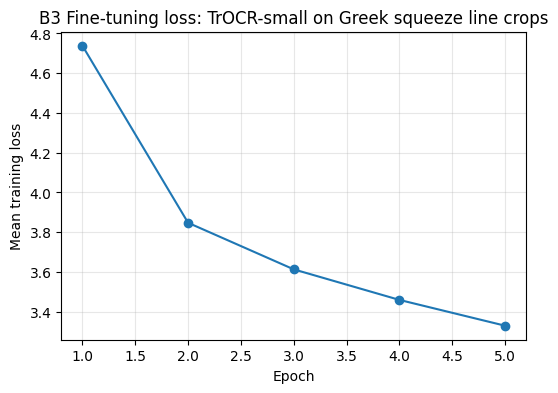

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(training_losses) + 1), training_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Mean training loss")
plt.title("B3 Fine-tuning loss: TrOCR-small on Greek squeeze line crops")
plt.grid(True, alpha=0.3)
plt.show()

#### B3.7 Method and Model comparison

In [ ]:
b3_results_df = pd.DataFrame([
    {
        "method": "Baseline TrOCR-base",
        "model": "microsoft/trocr-base-printed",
        "description": "Pretrained model, no post-processing, no fine-tuning",
        "CER": baseline_cer,
    },
    {
        "method": "Baseline TrOCR-base + normalization",
        "model": "microsoft/trocr-base-printed",
        "description": "Uppercase, remove punctuation/spaces/non-proxy symbols",
        "CER": baseline_clean_cer,
    },
    {
        "method": "Fine-tuned TrOCR-small",
        "model": "microsoft/trocr-small-printed",
        "description": "Fine-tuned on training line crops; encoder frozen; normalized output",
        "CER": ft_cer,
    },
])

b3_results_df["absolute_improvement_vs_baseline"] = (
    baseline_cer - b3_results_df["CER"]
)

b3_results_df["relative_improvement_vs_baseline_%"] = (
    100 * (baseline_cer - b3_results_df["CER"]) / baseline_cer
)

display(b3_results_df)

best_row = b3_results_df.loc[b3_results_df["CER"].idxmin()]

print(f"Best method: {best_row['method']}")
print(f"Best CER: {best_row['CER']:.4f}")
print(
    "Relative improvement vs baseline: "
    f"{best_row['relative_improvement_vs_baseline_%']:.2f}%"
)

,method,model,description,CER,absolute_improvement_vs_baseline,relative_improvement_vs_baseline_%
0,Baseline TrOCR-base,microsoft/trocr-base-printed,"Pretrained model, no post-processing, no fine-...",0.783660,0.000000,0.000000
1,Baseline TrOCR-base + normalization,microsoft/trocr-base-printed,"Uppercase, remove punctuation/spaces/non-proxy...",0.742726,0.040934,5.223404
2,Fine-tuned TrOCR-small,microsoft/trocr-small-printed,Fine-tuned on training line crops; encoder fro...,0.685035,0.098624,12.585106


Best method: Fine-tuned TrOCR-small
Best CER: 0.6850
Relative improvement vs baseline: 12.59%


## Data Sources, Licenses, and References

This project uses external datasets, pretrained models, and open-source libraries only for academic purposes in the context of the Applied Data Science course assignment. We do not claim ownership of the original dataset, annotations, images, pretrained models, or external tools used in this notebook.

### Dataset

The inscription images and annotation files used in this work come from the ICDAR 2026 Competition — Text Recognition on Greek Squeezes and the Smith College annotated dataset:

- ICDAR 2026 Competition — Text Recognition on Greek Squeezes:  
  https://www.science.smith.edu/~nhowe/contest/trogs26.html

- Character Recognition for Greek Squeezes — Annotated Data, Smith College:  
  https://scholarworks.smith.edu/dds_data/18

The ICDAR 2026 / Smith College dataset is used under the **Creative Commons Attribution 4.0 International License (CC-BY 4.0)**. Therefore, attribution to the original dataset creators is required.

Required citation:

Howe, N.R., Chang, F., Falbo, I., Brown, T. & Hershkowitz, A. “Character Recognition for Greek Squeezes.” *International Journal on Document Analysis and Recognition (IJDAR)* 28, 345–356 (2025).

### Aeneas / Predicting the Past

For the dating comparison in Part A6, we refer to the Aeneas / Predicting the Past work by Google DeepMind:

- Aeneas — Predicting the Past, DeepMind:  
  https://github.com/google-deepmind/predictingthepast

Aeneas is distributed under the **Apache 2.0 License**. We cite it as an external pretrained model/tool and do not claim ownership of its model architecture, training data, or released code.

Related citation:

Assael, Y. et al. “Restoring and attributing ancient texts using deep neural networks.” *Nature* 603, 280–283 (2022).

### OCR and Vision Models

For the OCR and image analysis parts of the assignment, we use or refer to pretrained models and related research, including:

- TrOCR — Microsoft:  
  https://arxiv.org/abs/2109.10282

- ViTSTR — Atienza:  
  https://arxiv.org/abs/2105.08582

These models and papers are cited as external research and baselines. Any pretrained models used through Hugging Face or other libraries remain the intellectual property of their original authors/providers.

### Other Libraries and Tools

This notebook also uses open-source Python libraries such as pandas, numpy, matplotlib, seaborn, scikit-learn, OpenCV, PyTorch, torchvision, transformers, datasets, UMAP, and related tools. These libraries are used according to their respective open-source licenses.

### AI Assistance

AI tools were used for assistance with coding, debugging, prompt design, and explanation writing. All AI interactions relevant to the assignment are documented separately in the submitted prompt library file:

`prompts_3220239_3220033.md`